In [1]:
import os
import sys
import json
import math
import time
import random
import shutil
import hashlib
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
)

from sklearn.preprocessing import label_binarize

ImageFile.LOAD_TRUNCATED_IMAGES = False

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "CUDA memory (GB):",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)
    )

Python: 3.13.15
Platform: Linux-6.18.48+-x86_64-with-glibc2.39
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Pandas: 2.3.3
NumPy: 2.1.3
CUDA available: True
GPU: Tesla T4
CUDA memory (GB): 14.56


In [2]:
SEED = 7

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as error:
        print("Deterministic-algorithm warning:", error)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

print("Seed:", SEED)
print("Device:", DEVICE)
print("pin_memory:", PIN_MEMORY)

Seed: 7
Device: cuda
pin_memory: True


In [3]:
# Update this only if you saved the audit output under another Kaggle dataset slug.
AUDIT_ROOT = Path("/kaggle/input/datasets/katakuricharlotte/manifestfileanalyse/main19_manifest_audit")

HANDOFF_PATH = AUDIT_ROOT / "reports" / "main19_dataset_audit_metadata.json"
MANIFEST_PATH = AUDIT_ROOT / "reports" / "main19_resolved_frozen_manifest.csv"

# Training output directory.
RUN_NAME = "efficientnet_b0_main19_audited_seed7"
RUN_ROOT = Path("/kaggle/working") / RUN_NAME

OUTPUTS = {
    "root": RUN_ROOT,
    "checkpoints": RUN_ROOT / "checkpoints",
    "reports": RUN_ROOT / "reports",
    "figures": RUN_ROOT / "figures",
    "predictions": RUN_ROOT / "predictions",
    "training": RUN_ROOT / "training",
}

for directory in OUTPUTS.values():
    directory.mkdir(parents=True, exist_ok=True)

assert HANDOFF_PATH.exists(), f"Missing handoff JSON: {HANDOFF_PATH}"
assert MANIFEST_PATH.exists(), f"Missing resolved manifest: {MANIFEST_PATH}"

print("Handoff:", HANDOFF_PATH)
print("Resolved manifest:", MANIFEST_PATH)
print("Output root:", OUTPUTS["root"])

Handoff: /kaggle/input/datasets/katakuricharlotte/manifestfileanalyse/main19_manifest_audit/reports/main19_dataset_audit_metadata.json
Resolved manifest: /kaggle/input/datasets/katakuricharlotte/manifestfileanalyse/main19_manifest_audit/reports/main19_resolved_frozen_manifest.csv
Output root: /kaggle/working/efficientnet_b0_main19_audited_seed7


In [4]:
with open(HANDOFF_PATH, "r", encoding="utf-8") as file:
    handoff = json.load(file)

with open(
    AUDIT_ROOT / "reports" / "main19_dataset_audit_metadata.json",
    "r",
    encoding="utf-8",
) as file:
    audit_metadata = json.load(file)

print(json.dumps(handoff, indent=2))

{
  "created_utc": "2026-10-06T10:37:50Z",
  "source_manifest_files": {
    "train": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv",
    "calibration": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv",
    "internal_test": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_internal_test.csv"
  },
  "plantvillage_root": "/kaggle/input/datasets/mohitsingh1804/plantvillage",
  "plantvillage_image_root": "/kaggle/input/datasets/mohitsingh1804/plantvillage",
  "rows_main19": 26632,
  "main19_classes": 19,
  "split_counts": {
    "train": 18113,
    "calibration": 3197,
    "internal_test": 5322
  },
  "resolved_manifest_sha256": "b49811fbe0d6cea4488ea218cbd9541e9a29ee2625ef8c5cf6537317e764ed05",
  "path_column": "image_path",
  "relative_path_column": "relative_path",
  "lab

In [5]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)

    return digest.hexdigest()

observed_manifest_fingerprint = sha256_file(MANIFEST_PATH)

expected_manifest_fingerprint = (
    handoff.get("resolved_manifest_fingerprint_sha256")
    or handoff.get("resolved_manifest_fingerprint")
    or audit_metadata.get("resolved_manifest_sha256")
)

assert expected_manifest_fingerprint is not None, (
    "No expected manifest fingerprint found in handoff or audit metadata."
)

assert observed_manifest_fingerprint == expected_manifest_fingerprint, (
    "Manifest fingerprint mismatch.\n"
    f"Expected: {expected_manifest_fingerprint}\n"
    f"Observed: {observed_manifest_fingerprint}\n"
    "Stop: do not train using an unverified manifest."
)

print("PASS: Frozen resolved manifest fingerprint matches audit metadata.")
print("SHA-256:", observed_manifest_fingerprint)

PASS: Frozen resolved manifest fingerprint matches audit metadata.
SHA-256: b49811fbe0d6cea4488ea218cbd9541e9a29ee2625ef8c5cf6537317e764ed05


In [6]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Manifest shape:", manifest.shape)
display(manifest.head())

print("\nColumns:")
print(manifest.columns.tolist())

print("\nSplit counts:")
display(manifest["split"].value_counts().rename_axis("split").reset_index(name="images"))

print("\nClass count:", manifest["class_name"].nunique())

Manifest shape: (26632, 11)


,image_id_manifest,manifest_path,relative_path,resolved_path,class_name,crop,condition,split,sha256_manifest,phash_manifest,manifest_file
0,c17ba3e25a65b2241698859e1c25d0f043ad0c5bdedb64...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/024623ab-b...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,c17ba3e25a65b2241698859e1c25d0f043ad0c5bdedb64...,fac9ab1b95239065,main19_calibration.csv
1,969798562a180f39d4f1941a80b90ba9b199c9b8b7d8c8...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/05287bcb-6...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,969798562a180f39d4f1941a80b90ba9b199c9b8b7d8c8...,8b7d0063a3639b2f,main19_calibration.csv
2,972c4b01b9f325da74e04920e95dfba3c5d8ee61e2fcd8...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/06d752a4-d...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,972c4b01b9f325da74e04920e95dfba3c5d8ee61e2fcd8...,ba3ca1d0d24b333e,main19_calibration.csv
3,b29d9161ca31dd4a8ea54718ae9eabc771406cbd7ed914...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/0719e8e8-c...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,b29d9161ca31dd4a8ea54718ae9eabc771406cbd7ed914...,eeb4a51e86689c69,main19_calibration.csv
4,8abe7baa4dcc88e5a13fb8defc594ee48ecd6e66599aa0...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/0a4c007d-4...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,8abe7baa4dcc88e5a13fb8defc594ee48ecd6e66599aa0...,f9c1b519c60fd298,main19_calibration.csv



Columns:
['image_id_manifest', 'manifest_path', 'relative_path', 'resolved_path', 'class_name', 'crop', 'condition', 'split', 'sha256_manifest', 'phash_manifest', 'manifest_file']

Split counts:


,split,images
0,train,18113
1,internal_test,5322
2,calibration,3197



Class count: 19


In [7]:
EXPECTED_COUNTS = {
    "train": 18113,
    "calibration": 3197,
    "internal_test": 5322,
}

REQUIRED_COLUMNS = {
    "image_id_manifest",
    "resolved_path",
    "class_name",
    "split",
    "sha256_manifest",
    "phash_manifest",
}

missing_columns = REQUIRED_COLUMNS - set(manifest.columns)
assert not missing_columns, f"Required columns missing: {missing_columns}"

assert len(manifest) == 26632, f"Expected 26,632 rows; found {len(manifest)}."
assert manifest["class_name"].nunique() == 19, "Expected exactly 19 classes."

observed_counts = manifest["split"].value_counts().to_dict()
assert observed_counts == EXPECTED_COUNTS, (
    f"Frozen split mismatch.\nExpected: {EXPECTED_COUNTS}\nObserved: {observed_counts}"
)

assert manifest["image_id_manifest"].notna().all()
assert manifest["image_id_manifest"].is_unique, (
    "image_id_manifest must be unique for all manifest rows."
)

assert manifest["resolved_path"].notna().all()
assert manifest["class_name"].notna().all()
assert manifest["split"].isin(EXPECTED_COUNTS).all()

path_exists = manifest["resolved_path"].map(lambda path: Path(path).is_file())
assert path_exists.all(), (
    f"{int((~path_exists).sum())} manifest image paths do not exist."
)

class_split_counts = (
    manifest.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "calibration", "internal_test"])
)

assert (class_split_counts > 0).all().all(), (
    "Every class must have support in train, calibration, and internal_test."
)

display(class_split_counts)

print("PASS: Manifest integrity checks passed.")
print("Rows:", len(manifest))
print("Classes:", manifest["class_name"].nunique())
print("Split counts:", observed_counts)

split,train,calibration,internal_test
class_name,,,
bell_pepper_bacterial_spot,677,120,200
bell_pepper_healthy,1005,178,295
corn_cercospora_leaf_spot_gray_leaf_spot,348,62,103
corn_common_rust,810,143,239
corn_healthy,790,139,232
corn_northern_leaf_blight,670,118,197
potato_early_blight,680,120,199
potato_healthy,103,18,31
potato_late_blight,680,120,200


PASS: Manifest integrity checks passed.
Rows: 26632
Classes: 19
Split counts: {'train': 18113, 'internal_test': 5322, 'calibration': 3197}


In [8]:
hash_split_counts = (
    manifest.dropna(subset=["sha256_manifest"])
    .groupby("sha256_manifest")["split"]
    .nunique()
)

cross_split_hashes = hash_split_counts[hash_split_counts > 1].index
cross_split_rows = manifest[
    manifest["sha256_manifest"].isin(cross_split_hashes)
].copy()

cross_split_summary = {
    "exact_cross_split_duplicate_hashes": int(len(cross_split_hashes)),
    "exact_cross_split_duplicate_rows": int(len(cross_split_rows)),
}

print(json.dumps(cross_split_summary, indent=2))

cross_split_summary_path = (
    OUTPUTS["reports"] / "exact_cross_split_duplicate_hash_summary.json"
)

with open(cross_split_summary_path, "w", encoding="utf-8") as file:
    json.dump(cross_split_summary, file, indent=2)

if len(cross_split_rows) > 0:
    cross_split_rows.sort_values(
        ["sha256_manifest", "split", "resolved_path"]
    ).to_csv(
        OUTPUTS["reports"] / "exact_cross_split_duplicate_hash_rows.csv",
        index=False,
    )

print("Saved:", cross_split_summary_path)

{
  "exact_cross_split_duplicate_hashes": 3,
  "exact_cross_split_duplicate_rows": 6
}
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/exact_cross_split_duplicate_hash_summary.json


In [9]:
class_names = sorted(manifest["class_name"].unique())
NUM_CLASSES = len(class_names)

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

manifest["target"] = manifest["class_name"].map(class_to_index)

assert manifest["target"].notna().all()
assert manifest["target"].nunique() == NUM_CLASSES

train_df = (
    manifest.loc[manifest["split"] == "train"]
    .sort_values(["class_name", "resolved_path"])
    .reset_index(drop=True)
)

calib_df = (
    manifest.loc[manifest["split"] == "calibration"]
    .sort_values(["class_name", "resolved_path"])
    .reset_index(drop=True)
)

test_df = (
    manifest.loc[manifest["split"] == "internal_test"]
    .sort_values(["class_name", "resolved_path"])
    .reset_index(drop=True)
)

assert len(train_df) == EXPECTED_COUNTS["train"]
assert len(calib_df) == EXPECTED_COUNTS["calibration"]
assert len(test_df) == EXPECTED_COUNTS["internal_test"]

print("Classes:", NUM_CLASSES)
print("Train:", len(train_df))
print("Calibration:", len(calib_df))
print("Internal test:", len(test_df))

display(
    pd.DataFrame(
        {
            "class_index": range(NUM_CLASSES),
            "class_name": class_names,
        }
    )
)

Classes: 19
Train: 18113
Calibration: 3197
Internal test: 5322


,class_index,class_name
0,0,bell_pepper_bacterial_spot
1,1,bell_pepper_healthy
2,2,corn_cercospora_leaf_spot_gray_leaf_spot
3,3,corn_common_rust
4,4,corn_healthy
5,5,corn_northern_leaf_blight
6,6,potato_early_blight
7,7,potato_healthy
8,8,potato_late_blight
9,9,tomato_bacterial_spot


In [10]:
protocol = {
    "study_name": "Main19 audited EfficientNet-B0",
    "seed": SEED,
    "architecture": "torchvision.models.efficientnet_b0",
    "num_classes": NUM_CLASSES,
    "input_size": 224,
    "image_initialization": "ImageNet-1K pretrained weights required",
    "train_partition": "train",
    "checkpoint_selection_partition": "calibration",
    "temperature_scaling_partition": "calibration",
    "threshold_selection_partition": "calibration",
    "locked_final_evaluation_partition": "internal_test",
    "internal_test_used_for_training": False,
    "internal_test_used_for_checkpoint_selection": False,
    "internal_test_used_for_temperature_fitting": False,
    "internal_test_used_for_threshold_selection": False,
    "manifest_fingerprint_sha256": observed_manifest_fingerprint,
    "split_counts": EXPECTED_COUNTS,
    "exact_cross_split_duplicate_hash_disclosure": cross_split_summary,
    "class_to_index": class_to_index,
}

protocol_path = OUTPUTS["reports"] / "training_protocol.json"

with open(protocol_path, "w", encoding="utf-8") as file:
    json.dump(protocol, file, indent=2)

print("Saved protocol:", protocol_path)

Saved protocol: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/training_protocol.json


In [11]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 5

LR_MILESTONES = [6, 13]
LR_GAMMA = 0.5

LABEL_SMOOTHING = 0.0
USE_PRETRAINED_WEIGHTS = True
REQUIRE_PRETRAINED_WEIGHTS = True

TRAINING_CONFIG = {
    "seed": SEED,
    "architecture": "efficientnet_b0",
    "input_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": "MultiStepLR",
    "scheduler_milestones": LR_MILESTONES,
    "scheduler_gamma": LR_GAMMA,
    "loss": "class-weighted CrossEntropyLoss",
    "label_smoothing": LABEL_SMOOTHING,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "checkpoint_criterion": "calibration_macro_f1",
    "pretrained_initialization_required": REQUIRE_PRETRAINED_WEIGHTS,
    "manifest_fingerprint_sha256": observed_manifest_fingerprint,
}

config_path = OUTPUTS["training"] / "training_config.json"

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(TRAINING_CONFIG, file, indent=2)

print(json.dumps(TRAINING_CONFIG, indent=2))

{
  "seed": 7,
  "architecture": "efficientnet_b0",
  "input_size": 224,
  "batch_size": 32,
  "num_workers": 4,
  "optimizer": "AdamW",
  "learning_rate": 0.0003,
  "weight_decay": 0.0001,
  "scheduler": "MultiStepLR",
  "scheduler_milestones": [
    6,
    13
  ],
  "scheduler_gamma": 0.5,
  "loss": "class-weighted CrossEntropyLoss",
  "label_smoothing": 0.0,
  "max_epochs": 15,
  "early_stopping_patience": 5,
  "checkpoint_criterion": "calibration_macro_f1",
  "pretrained_initialization_required": true,
  "manifest_fingerprint_sha256": "b49811fbe0d6cea4488ea218cbd9541e9a29ee2625ef8c5cf6537317e764ed05"
}


In [12]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

In [13]:
class ManifestImageDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

        required = {
            "image_id_manifest",
            "resolved_path",
            "class_name",
            "target",
            "split",
        }

        missing = required - set(self.dataframe.columns)
        assert not missing, f"Dataset dataframe missing columns: {missing}"

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        image_path = Path(row["resolved_path"])

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
        except Exception as error:
            raise RuntimeError(
                f"Failed to read image at index={index}: {image_path}"
            ) from error

        if self.transform is not None:
            image = self.transform(image)

        target = int(row["target"])

        metadata = {
            "image_id_manifest": row["image_id_manifest"],
            "resolved_path": str(image_path),
            "class_name": row["class_name"],
            "split": row["split"],
        }

        return image, target, metadata

In [14]:
train_dataset = ManifestImageDataset(train_df, transform=train_transform)
calib_dataset = ManifestImageDataset(calib_df, transform=evaluation_transform)
test_dataset = ManifestImageDataset(test_df, transform=evaluation_transform)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

def seed_worker(worker_id: int) -> None:
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
    generator=loader_generator,
)

calib_loader = DataLoader(
    calib_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

print("Train batches:", len(train_loader))
print("Calibration batches:", len(calib_loader))
print("Internal test batches:", len(test_loader))

Train batches: 567
Calibration batches: 100
Internal test batches: 167


In [15]:
images, targets, metadata = next(iter(train_loader))

assert images.ndim == 4
assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert targets.ndim == 1
assert len(metadata["image_id_manifest"]) == len(targets)

print("Image batch shape:", tuple(images.shape))
print("Target batch shape:", tuple(targets.shape))
print("Target range:", int(targets.min()), "to", int(targets.max()))
print("Example class:", metadata["class_name"][0])
print("Example path:", metadata["resolved_path"][0])

Image batch shape: (32, 3, 224, 224)
Target batch shape: (32,)
Target range: 0 to 18
Example class: tomato_tomato_yellow_leaf_curl_virus
Example path: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/7734544d-f6ec-4df7-956d-99697a51c5f2___YLCV_NREC 0089.JPG


In [16]:
train_class_counts = (
    train_df["target"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

assert (train_class_counts > 0).all()

inverse_frequency_weights = (
    len(train_df) / (NUM_CLASSES * train_class_counts.to_numpy(dtype=np.float64))
)

class_weights = torch.tensor(
    inverse_frequency_weights,
    dtype=torch.float32,
    device=DEVICE,
)

class_weight_table = pd.DataFrame(
    {
        "class_index": range(NUM_CLASSES),
        "class_name": class_names,
        "train_images": train_class_counts.to_numpy(),
        "class_weight": inverse_frequency_weights,
    }
)

display(class_weight_table)

class_weight_table.to_csv(
    OUTPUTS["reports"] / "class_weights.csv",
    index=False,
)

,class_index,class_name,train_images,class_weight
0,0,bell_pepper_bacterial_spot,677,1.408147
1,1,bell_pepper_healthy,1005,0.948573
2,2,corn_cercospora_leaf_spot_gray_leaf_spot,348,2.739413
3,3,corn_common_rust,810,1.176933
4,4,corn_healthy,790,1.206729
5,5,corn_northern_leaf_blight,670,1.422859
6,6,potato_early_blight,680,1.401935
7,7,potato_healthy,103,9.255493
8,8,potato_late_blight,680,1.401935
9,9,tomato_bacterial_spot,1447,0.658822


In [17]:
def build_efficientnet_b0(
    num_classes: int,
    require_pretrained_weights: bool = True,
) -> nn.Module:
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1

    try:
        model = models.efficientnet_b0(weights=weights)
        initialization = {
            "weights": "EfficientNet_B0_Weights.IMAGENET1K_V1",
            "pretrained": True,
            "weights_url": weights.url,
        }
    except Exception as error:
        if require_pretrained_weights:
            raise RuntimeError(
                "ImageNet-pretrained EfficientNet-B0 weights could not be loaded. "
                "This run must not proceed with random initialization because the "
                "protocol specifies ImageNet-pretrained fine-tuning. Enable Kaggle "
                "internet, attach/cache the official weight checkpoint, then rerun."
            ) from error

        model = models.efficientnet_b0(weights=None)
        initialization = {
            "weights": None,
            "pretrained": False,
            "fallback_reason": repr(error),
        }

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    model.initialization_metadata = initialization

    return model

model = build_efficientnet_b0(
    num_classes=NUM_CLASSES,
    require_pretrained_weights=REQUIRE_PRETRAINED_WEIGHTS,
).to(DEVICE)

print("Model initialization:")
print(json.dumps(model.initialization_metadata, indent=2))

parameter_count = sum(parameter.numel() for parameter in model.parameters())
trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", f"{parameter_count:,}")
print("Trainable parameters:", f"{trainable_parameter_count:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 121MB/s] 


Model initialization:
{
  "weights": "EfficientNet_B0_Weights.IMAGENET1K_V1",
  "pretrained": true,
  "weights_url": "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth"
}
Total parameters: 4,031,887
Trainable parameters: 4,031,887


In [18]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=LR_MILESTONES,
    gamma=LR_GAMMA,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda",
)

print("AMP enabled:", scaler.is_enabled())

AMP enabled: True


In [19]:
def expected_calibration_error(
    probabilities: np.ndarray,
    targets: np.ndarray,
    n_bins: int = 15,
) -> float:
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = (predictions == targets).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        if upper == 1.0:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        if not np.any(in_bin):
            continue

        bin_accuracy = correctness[in_bin].mean()
        bin_confidence = confidences[in_bin].mean()
        ece += in_bin.mean() * abs(bin_accuracy - bin_confidence)

    return float(ece)


def multiclass_brier_score(
    probabilities: np.ndarray,
    targets: np.ndarray,
    num_classes: int,
) -> float:
    one_hot = np.eye(num_classes, dtype=np.float64)[targets]
    return float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)))


@torch.inference_mode()
def collect_predictions(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()

    all_logits = []
    all_targets = []
    all_image_ids = []
    all_paths = []
    all_class_names = []
    all_splits = []

    for images, targets, metadata in tqdm(
        loader,
        desc="Inference",
        leave=False,
    ):
        images = images.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            enabled=DEVICE.type == "cuda",
        ):
            logits = model(images)

        all_logits.append(logits.float().cpu())
        all_targets.append(targets.cpu())

        all_image_ids.extend(metadata["image_id_manifest"])
        all_paths.extend(metadata["resolved_path"])
        all_class_names.extend(metadata["class_name"])
        all_splits.extend(metadata["split"])

    logits = torch.cat(all_logits).numpy()
    targets = torch.cat(all_targets).numpy().astype(int)
    probabilities = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    predictions = probabilities.argmax(axis=1)
    confidences = probabilities.max(axis=1)

    return {
        "logits": logits,
        "targets": targets,
        "probabilities": probabilities,
        "predictions": predictions,
        "confidences": confidences,
        "image_ids": all_image_ids,
        "paths": all_paths,
        "class_names": all_class_names,
        "splits": all_splits,
    }


def compute_metrics(prediction_bundle: dict) -> dict:
    targets = prediction_bundle["targets"]
    predictions = prediction_bundle["predictions"]
    probabilities = prediction_bundle["probabilities"]

    top_k = min(5, probabilities.shape[1])
    top_k_indices = np.argsort(probabilities, axis=1)[:, -top_k:]
    top_k_accuracy = float(
        np.mean(
            [
                true_target in candidate_indices
                for true_target, candidate_indices
                in zip(targets, top_k_indices)
            ]
        )
    )

    return {
        "images": int(len(targets)),
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(
                targets,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": float(
            f1_score(
                targets,
                predictions,
                average="weighted",
                zero_division=0,
            )
        ),
        "top5_accuracy": top_k_accuracy,
        "nll": float(
            log_loss(
                targets,
                probabilities,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "brier_score": multiclass_brier_score(
            probabilities=probabilities,
            targets=targets,
            num_classes=NUM_CLASSES,
        ),
        "ece_15": expected_calibration_error(
            probabilities=probabilities,
            targets=targets,
            n_bins=15,
        ),
        "mean_confidence": float(prediction_bundle["confidences"].mean()),
        "median_confidence": float(
            np.median(prediction_bundle["confidences"])
        ),
    }

In [20]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler: torch.amp.GradScaler,
) -> dict:
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_images = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, targets, _ in progress_bar:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=DEVICE.type,
            enabled=DEVICE.type == "cuda",
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = targets.size(0)
        total_loss += loss.detach().item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_images += batch_size

        progress_bar.set_postfix(
            loss=f"{total_loss / total_images:.4f}",
            accuracy=f"{total_correct / total_images:.4f}",
        )

    return {
        "loss": float(total_loss / total_images),
        "accuracy": float(total_correct / total_images),
        "images": int(total_images),
    }

In [21]:
def evaluate_for_selection(model: nn.Module, loader: DataLoader) -> dict:
    """
    Use only the calibration partition for checkpoint selection.
    The internal-test loader must never be passed here during training.
    """
    predictions = collect_predictions(model, loader)
    metrics = compute_metrics(predictions)

    return {
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "nll": metrics["nll"],
        "brier_score": metrics["brier_score"],
        "ece_15": metrics["ece_15"],
    }

In [22]:
seed_everything(SEED)

checkpoint_path = (
    OUTPUTS["checkpoints"] / "efficientnet_b0_main19_best.pt"
)

history = []
best_calibration_macro_f1 = -np.inf
best_epoch = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()

    train_stats = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
    )

    calibration_metrics = evaluate_for_selection(
        model=model,
        loader=calib_loader,
    )

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    epoch_record = {
        "epoch": epoch,
        "learning_rate": float(current_lr),
        "train_loss": train_stats["loss"],
        "train_accuracy": train_stats["accuracy"],
        "calibration_accuracy": calibration_metrics["accuracy"],
        "calibration_macro_f1": calibration_metrics["macro_f1"],
        "calibration_nll": calibration_metrics["nll"],
        "calibration_brier_score": calibration_metrics["brier_score"],
        "calibration_ece_15": calibration_metrics["ece_15"],
        "elapsed_seconds": float(time.time() - epoch_start),
    }

    history.append(epoch_record)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"lr={epoch_record['learning_rate']:.2e} | "
        f"train loss={epoch_record['train_loss']:.5f} | "
        f"train acc={epoch_record['train_accuracy']:.4f} | "
        f"calib macro-F1={epoch_record['calibration_macro_f1']:.4f} | "
        f"calib NLL={epoch_record['calibration_nll']:.5f} | "
        f"calib ECE={epoch_record['calibration_ece_15']:.5f}"
    )

    if epoch_record["calibration_macro_f1"] > best_calibration_macro_f1:
        best_calibration_macro_f1 = epoch_record[
            "calibration_macro_f1"
        ]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "checkpoint_format_version": 1,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_calibration_macro_f1": best_calibration_macro_f1,
                "seed": SEED,
                "architecture": "efficientnet_b0",
                "num_classes": NUM_CLASSES,
                "class_to_index": class_to_index,
                "training_config": TRAINING_CONFIG,
                "manifest_fingerprint_sha256": observed_manifest_fingerprint,
                "split_counts": EXPECTED_COUNTS,
                "initialization_metadata": model.initialization_metadata,
                "selection_partition": "calibration",
                "selection_metric": "macro_f1",
                "internal_test_accessed_during_training": False,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping at epoch {epoch}. "
            f"Best epoch: {best_epoch}."
        )
        break

history_df = pd.DataFrame(history)
history_path = (
    OUTPUTS["training"] / "efficientnet_b0_training_history.csv"
)
history_df.to_csv(history_path, index=False)

assert checkpoint_path.exists()
assert history_path.exists()
assert best_epoch is not None

print("\nBest epoch:", best_epoch)
print("Best calibration macro-F1:", best_calibration_macro_f1)
print("Checkpoint:", checkpoint_path)
print("Training history:", history_path)

Training:   0%|          | 0/567 [00:00<?, ?it/s]

Inference:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01/15 | lr=3.00e-04 | train loss=0.38685 | train acc=0.8977 | calib macro-F1=0.9612 | calib NLL=0.08731 | calib ECE=0.00687


Training:   0%|          | 0/567 [00:00<?, ?it/s]

Inference:   0%|          | 0/100 [00:00<?, ?it/s]

...

Inference:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 14/15 | lr=7.50e-05 | train loss=0.00877 | train acc=0.9971 | calib macro-F1=0.9932 | calib NLL=0.01479 | calib ECE=0.00229


Training:   0%|          | 0/567 [00:00<?, ?it/s]

Inference:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 15/15 | lr=7.50e-05 | train loss=0.00820 | train acc=0.9977 | calib macro-F1=0.9967 | calib NLL=0.00815 | calib ECE=0.00164

Best epoch: 15
Best calibration macro-F1: 0.9966970217531076
Checkpoint: /kaggle/working/efficientnet_b0_main19_audited_seed7/checkpoints/efficientnet_b0_main19_best.pt
Training history: /kaggle/working/efficientnet_b0_main19_audited_seed7/training/efficientnet_b0_training_history.csv


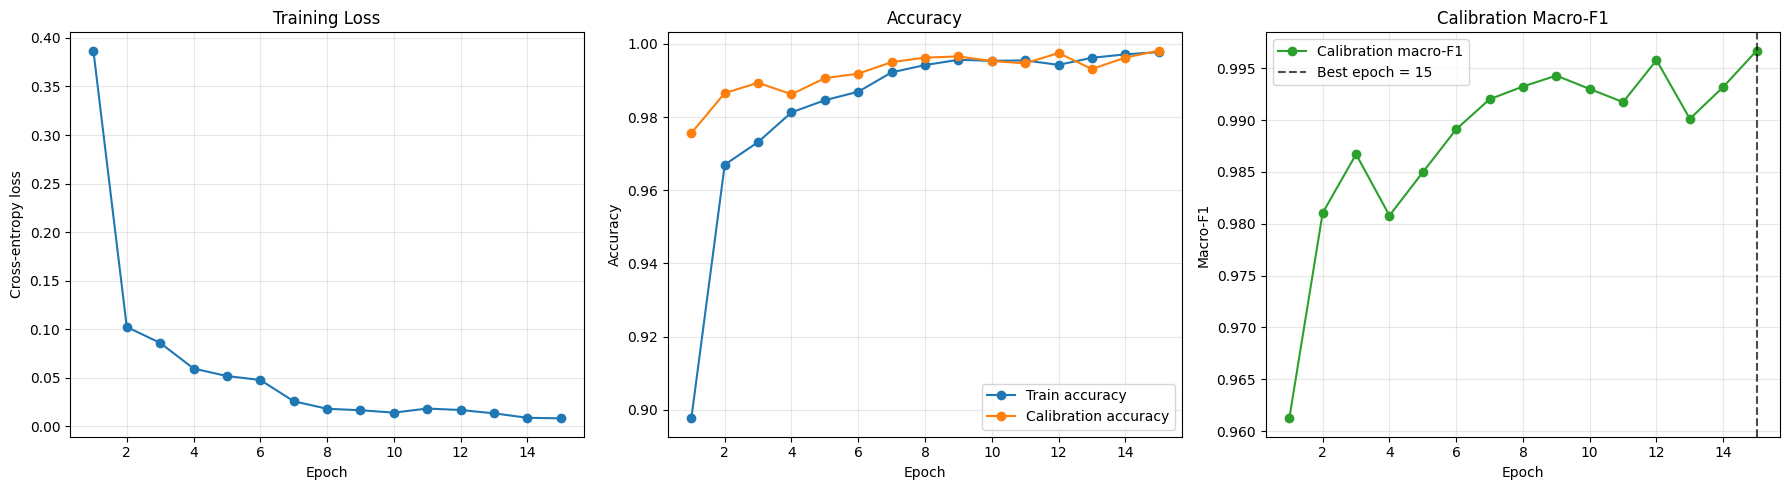

Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/figures/efficientnet_b0_training_curves.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train loss",
)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Train accuracy",
)
axes[1].plot(
    history_df["epoch"],
    history_df["calibration_accuracy"],
    marker="o",
    label="Calibration accuracy",
)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(
    history_df["epoch"],
    history_df["calibration_macro_f1"],
    marker="o",
    color="tab:green",
    label="Calibration macro-F1",
)
axes[2].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"Best epoch = {best_epoch}",
)
axes[2].set_title("Calibration Macro-F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro-F1")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

training_curve_path = (
    OUTPUTS["figures"] / "efficientnet_b0_training_curves.png"
)
plt.savefig(training_curve_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", training_curve_path)

In [24]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False,
)

assert checkpoint["manifest_fingerprint_sha256"] == observed_manifest_fingerprint
assert checkpoint["selection_partition"] == "calibration"
assert checkpoint["selection_metric"] == "macro_f1"
assert checkpoint["internal_test_accessed_during_training"] is False

best_model = build_efficientnet_b0(
    num_classes=NUM_CLASSES,
    require_pretrained_weights=False,
).to(DEVICE)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("Loaded best checkpoint.")
print("Selected epoch:", checkpoint["epoch"])
print("Best calibration macro-F1:", checkpoint["best_calibration_macro_f1"])
print("Initialization:", checkpoint["initialization_metadata"])

Loaded best checkpoint.
Selected epoch: 15
Best calibration macro-F1: 0.9966970217531076
Initialization: {'weights': 'EfficientNet_B0_Weights.IMAGENET1K_V1', 'pretrained': True, 'weights_url': 'https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth'}


In [25]:
# This is the first cell in the notebook that uses internal_test for model output.
# Do not return to Cells 12–23 and tune anything after inspecting these results.

test_predictions = collect_predictions(
    model=best_model,
    loader=test_loader,
)

test_metrics = compute_metrics(test_predictions)

final_test_metrics_path = (
    OUTPUTS["reports"] / "efficientnet_b0_internal_test_metrics.json"
)

with open(final_test_metrics_path, "w", encoding="utf-8") as file:
    json.dump(test_metrics, file, indent=2)

print(json.dumps(test_metrics, indent=2))
print("\nSaved:", final_test_metrics_path)

Inference:   0%|          | 0/167 [00:00<?, ?it/s]

{
  "images": 5322,
  "accuracy": 0.9977452085682075,
  "balanced_accuracy": 0.9967102992341378,
  "macro_f1": 0.9961721254883343,
  "weighted_f1": 0.9977524404273124,
  "top5_accuracy": 1.0,
  "nll": 0.007474851586847179,
  "brier_score": 0.0037781317984842454,
  "ece_15": 0.0013007230997891673,
  "mean_confidence": 0.9977743625640869,
  "median_confidence": 0.999994158744812
}

Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_internal_test_metrics.json


In [26]:
test_prediction_export = pd.DataFrame(
    {
        "image_id_manifest": test_predictions["image_ids"],
        "resolved_path": test_predictions["paths"],
        "class_name_true": [
            index_to_class[target]
            for target in test_predictions["targets"]
        ],
        "true_class_index": test_predictions["targets"],
        "class_name_predicted": [
            index_to_class[prediction]
            for prediction in test_predictions["predictions"]
        ],
        "predicted_class_index": test_predictions["predictions"],
        "confidence": test_predictions["confidences"],
        "correct": (
            test_predictions["targets"]
            == test_predictions["predictions"]
        ),
        "split": test_predictions["splits"],
    }
)

for class_index, class_name in index_to_class.items():
    test_prediction_export[f"probability_{class_index:02d}_{class_name}"] = (
        test_predictions["probabilities"][:, class_index]
    )

assert len(test_prediction_export) == EXPECTED_COUNTS["internal_test"]
assert (test_prediction_export["split"] == "internal_test").all()

test_predictions_path = (
    OUTPUTS["predictions"] / "efficientnet_b0_internal_test_predictions.csv"
)

test_prediction_export.to_csv(test_predictions_path, index=False)

print("Saved:", test_predictions_path)
display(test_prediction_export.head())

Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/predictions/efficientnet_b0_internal_test_predictions.csv


,image_id_manifest,resolved_path,class_name_true,true_class_index,class_name_predicted,predicted_class_index,confidence,correct,split,probability_00_bell_pepper_bacterial_spot,...,probability_09_tomato_bacterial_spot,probability_10_tomato_early_blight,probability_11_tomato_healthy,probability_12_tomato_late_blight,probability_13_tomato_leaf_mold,probability_14_tomato_septoria_leaf_spot,probability_15_tomato_spider_mites_two_spotted_spider_mite,probability_16_tomato_target_spot,probability_17_tomato_tomato_mosaic_virus,probability_18_tomato_tomato_yellow_leaf_curl_virus
0,d1b01e4214316f9fb31bb84258cfd2487f3d7c0558e657...,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,0,bell_pepper_bacterial_spot,0,0.999985,True,internal_test,0.999985,...,6.214689e-08,1.773596e-08,1.242274e-12,7.507638e-11,1.259939e-09,3.136577e-06,2.946221e-10,1.094239e-05,1.109557e-10,4.847295e-11
1,87f35bce91e6b854a292f9d2a0e290772b576c6270e2ce...,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,0,bell_pepper_bacterial_spot,0,0.999989,True,internal_test,0.999989,...,3.981295e-08,2.340482e-08,1.373009e-09,3.911338e-09,6.432722e-06,1.609069e-06,1.373009e-09,3.851848e-07,1.951439e-09,4.320364e-10
2,338674c9eec69822427cbfd14248c10ca56a8c7f73beac...,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,0,bell_pepper_bacterial_spot,0,0.996472,True,internal_test,0.996472,...,7.723352e-07,1.253811e-05,8.884216e-11,6.630009e-09,1.108316e-07,3.349825e-03,6.290377e-08,2.149211e-06,6.290377e-08,2.720950e-09
3,3432a54ccc1578147099c8978c852faa39cff4f8007328...,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,0,bell_pepper_bacterial_spot,0,0.999998,True,internal_test,0.999998,...,1.679480e-07,2.457256e-09,1.652702e-10,8.117800e-11,5.202011e-09,8.443697e-09,3.442706e-07,3.486171e-08,8.899592e-10,9.094220e-09
4,c8482c706279972180208947f5513dc9b6d93e8642658a...,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,0,bell_pepper_bacterial_spot,0,1.000000,True,internal_test,1.000000,...,1.118610e-08,2.630719e-10,4.913363e-12,5.789356e-12,8.846292e-11,8.709144e-11,3.486177e-08,5.894661e-09,2.437410e-11,1.002416e-10


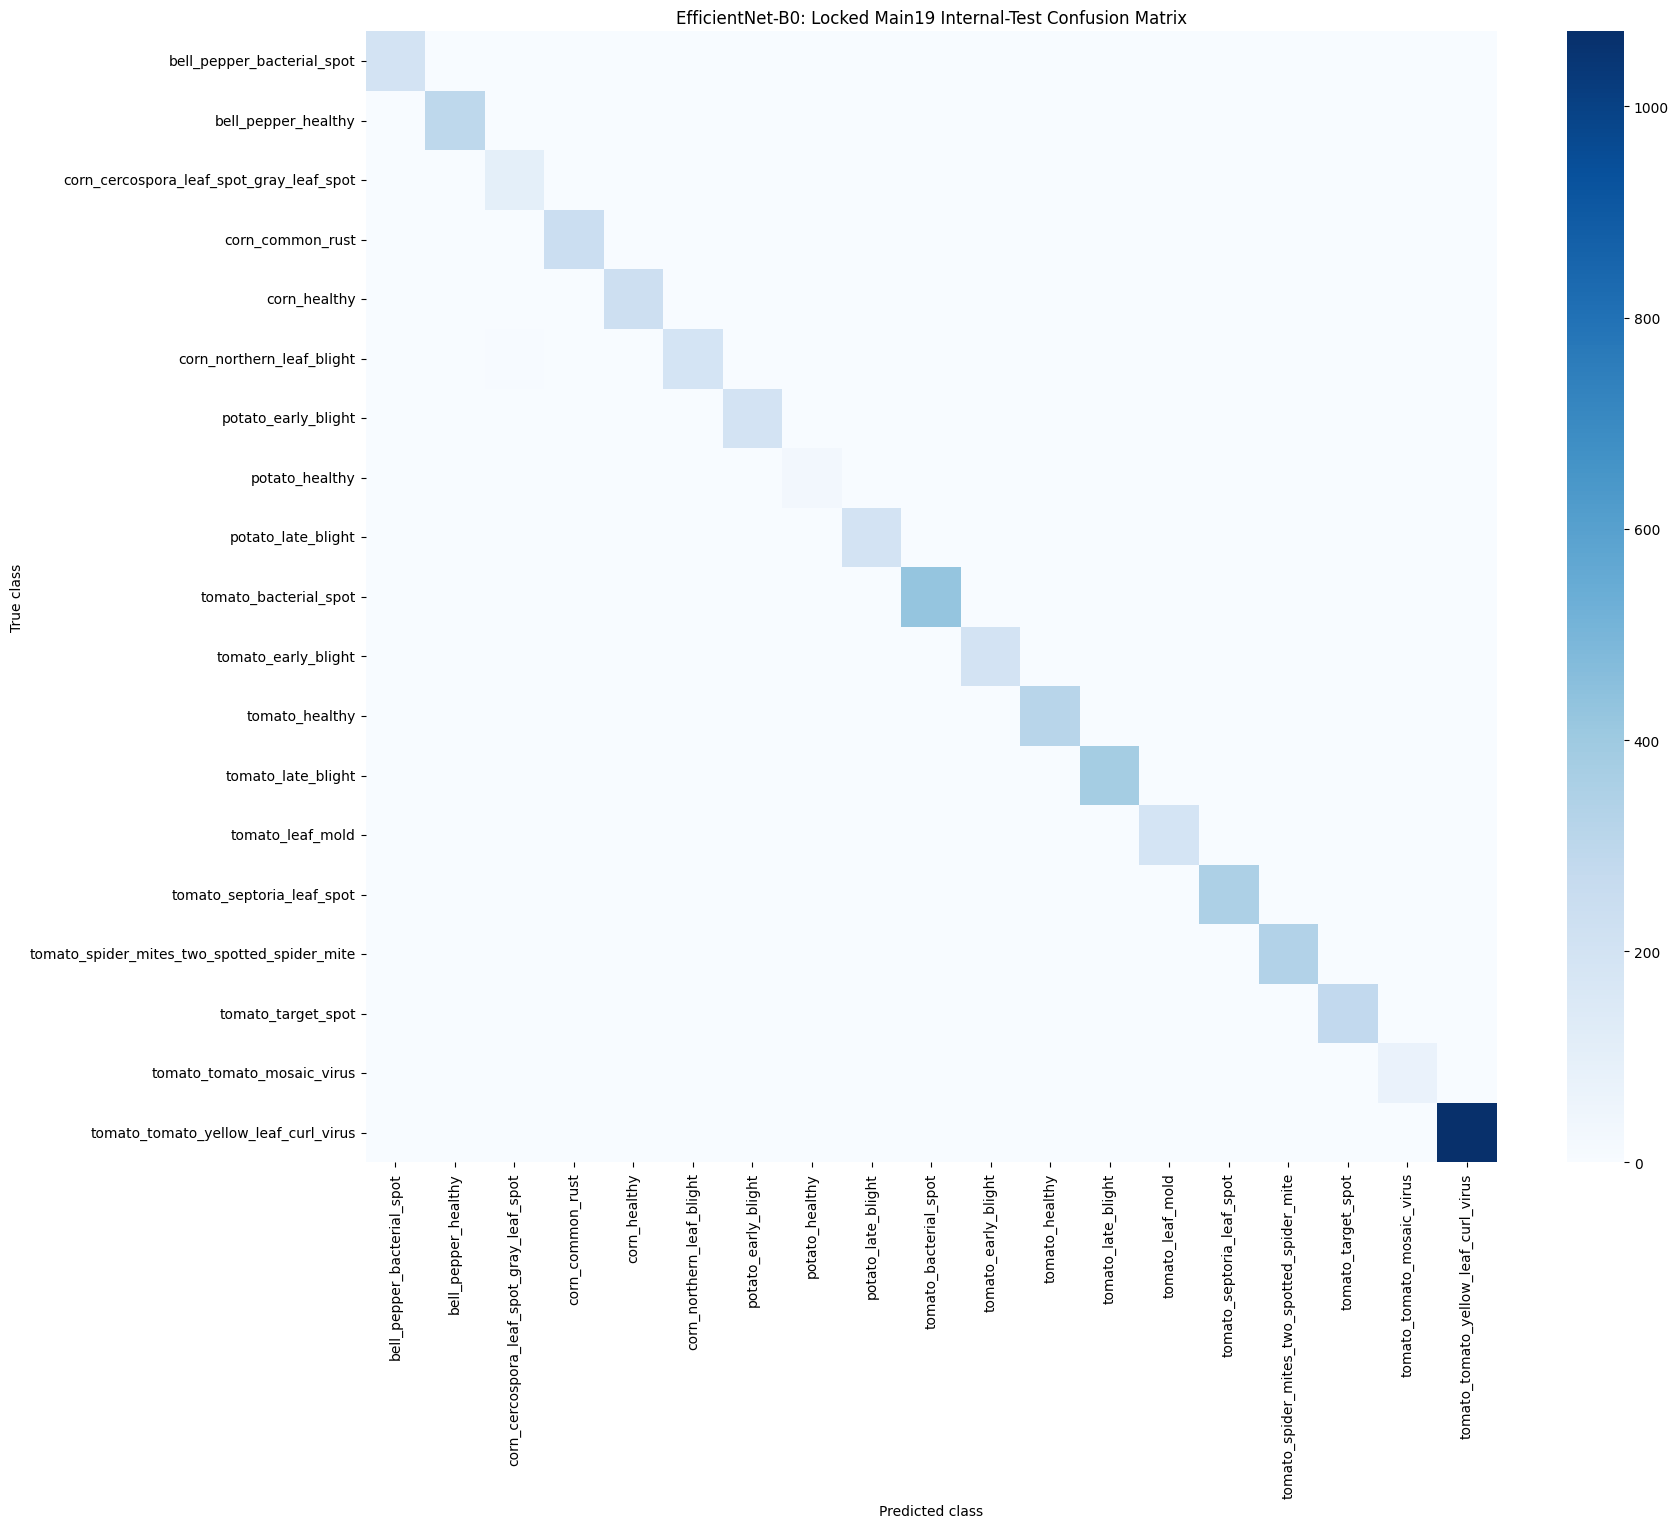

Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_internal_test_classification_report.csv
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_internal_test_confusion_matrix.csv
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/figures/efficientnet_b0_internal_test_confusion_matrix.png


In [27]:
test_targets = test_predictions["targets"]
test_outputs = test_predictions["predictions"]

report_dictionary = classification_report(
    test_targets,
    test_outputs,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

classification_report_df = (
    pd.DataFrame(report_dictionary)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_aggregate"})
)

classification_report_path = (
    OUTPUTS["reports"] / "efficientnet_b0_internal_test_classification_report.csv"
)

classification_report_df.to_csv(classification_report_path, index=False)

confusion = confusion_matrix(
    test_targets,
    test_outputs,
    labels=np.arange(NUM_CLASSES),
)

confusion_df = pd.DataFrame(
    confusion,
    index=class_names,
    columns=class_names,
)

confusion_path = (
    OUTPUTS["reports"] / "efficientnet_b0_internal_test_confusion_matrix.csv"
)

confusion_df.to_csv(confusion_path)

plt.figure(figsize=(18, 15))
sns.heatmap(
    confusion_df,
    cmap="Blues",
    square=True,
    cbar=True,
    xticklabels=True,
    yticklabels=True,
)
plt.title("EfficientNet-B0: Locked Main19 Internal-Test Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()

confusion_figure_path = (
    OUTPUTS["figures"] / "efficientnet_b0_internal_test_confusion_matrix.png"
)

plt.savefig(confusion_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", classification_report_path)
print("Saved:", confusion_path)
print("Saved:", confusion_figure_path)

In [28]:
calibration_predictions = collect_predictions(
    model=best_model,
    loader=calib_loader,
)

calibration_metrics_uncalibrated = compute_metrics(
    calibration_predictions
)

calibration_export = pd.DataFrame(
    {
        "image_id_manifest": calibration_predictions["image_ids"],
        "resolved_path": calibration_predictions["paths"],
        "class_name_true": [
            index_to_class[target]
            for target in calibration_predictions["targets"]
        ],
        "true_class_index": calibration_predictions["targets"],
        "class_name_predicted": [
            index_to_class[prediction]
            for prediction in calibration_predictions["predictions"]
        ],
        "predicted_class_index": calibration_predictions["predictions"],
        "confidence": calibration_predictions["confidences"],
        "correct": (
            calibration_predictions["targets"]
            == calibration_predictions["predictions"]
        ),
        "split": calibration_predictions["splits"],
    }
)

for class_index, class_name in index_to_class.items():
    calibration_export[
        f"probability_{class_index:02d}_{class_name}"
    ] = calibration_predictions["probabilities"][:, class_index]

calibration_predictions_path = (
    OUTPUTS["predictions"] / "efficientnet_b0_calibration_predictions_uncalibrated.csv"
)

calibration_export.to_csv(calibration_predictions_path, index=False)

print("Uncalibrated calibration metrics:")
print(json.dumps(calibration_metrics_uncalibrated, indent=2))
print("Saved:", calibration_predictions_path)

Inference:   0%|          | 0/100 [00:00<?, ?it/s]

Uncalibrated calibration metrics:
{
  "images": 3197,
  "accuracy": 0.9981232405380044,
  "balanced_accuracy": 0.9965329534881491,
  "macro_f1": 0.9966970217531076,
  "weighted_f1": 0.9981214168416639,
  "top5_accuracy": 1.0,
  "nll": 0.008152586706697376,
  "brier_score": 0.003864719051539939,
  "ece_15": 0.0016438587964010308,
  "mean_confidence": 0.9985461235046387,
  "median_confidence": 0.9999942779541016
}
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/predictions/efficientnet_b0_calibration_predictions_uncalibrated.csv


In [29]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    @property
    def temperature(self) -> torch.Tensor:
        return torch.exp(self.log_temperature)

    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        return logits / self.temperature.clamp_min(1e-6)


def fit_temperature(
    logits_np: np.ndarray,
    targets_np: np.ndarray,
) -> tuple[TemperatureScaler, float]:
    logits = torch.tensor(logits_np, dtype=torch.float32, device=DEVICE)
    targets = torch.tensor(targets_np, dtype=torch.long, device=DEVICE)

    temperature_scaler = TemperatureScaler().to(DEVICE)
    criterion_nll = nn.CrossEntropyLoss()

    optimizer_lbfgs = torch.optim.LBFGS(
        temperature_scaler.parameters(),
        lr=0.01,
        max_iter=200,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer_lbfgs.zero_grad(set_to_none=True)
        loss = criterion_nll(temperature_scaler(logits), targets)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    temperature = float(temperature_scaler.temperature.detach().cpu().item())

    assert np.isfinite(temperature)
    assert temperature > 0.0

    return temperature_scaler, temperature


def apply_temperature(
    logits_np: np.ndarray,
    temperature: float,
) -> dict:
    scaled_logits = logits_np / temperature
    probabilities = torch.softmax(
        torch.tensor(scaled_logits, dtype=torch.float32),
        dim=1,
    ).numpy()

    return {
        "logits": scaled_logits,
        "probabilities": probabilities,
        "predictions": probabilities.argmax(axis=1),
        "confidences": probabilities.max(axis=1),
    }

In [30]:
temperature_scaler, fitted_temperature = fit_temperature(
    logits_np=calibration_predictions["logits"],
    targets_np=calibration_predictions["targets"],
)

calibration_scaled_outputs = apply_temperature(
    logits_np=calibration_predictions["logits"],
    temperature=fitted_temperature,
)

calibration_predictions_scaled = {
    **calibration_predictions,
    **calibration_scaled_outputs,
}

calibration_metrics_scaled = compute_metrics(
    calibration_predictions_scaled
)

assert np.array_equal(
    calibration_predictions["predictions"],
    calibration_predictions_scaled["predictions"],
), "Temperature scaling must not change top-1 class rankings."

temperature_metadata = {
    "temperature": fitted_temperature,
    "fitting_partition": "calibration",
    "fitting_images": int(len(calibration_predictions["targets"])),
    "objective": "negative_log_likelihood",
    "classification_rankings_preserved": True,
    "manifest_fingerprint_sha256": observed_manifest_fingerprint,
    "calibration_metrics_uncalibrated": calibration_metrics_uncalibrated,
    "calibration_metrics_temperature_scaled": calibration_metrics_scaled,
}

temperature_path = (
    OUTPUTS["reports"] / "efficientnet_b0_temperature_scaling.json"
)

with open(temperature_path, "w", encoding="utf-8") as file:
    json.dump(temperature_metadata, file, indent=2)

print(json.dumps(temperature_metadata, indent=2))
print("Saved:", temperature_path)

{
  "temperature": 1.155396580696106,
  "fitting_partition": "calibration",
  "fitting_images": 3197,
  "objective": "negative_log_likelihood",
  "classification_rankings_preserved": true,
  "manifest_fingerprint_sha256": "b49811fbe0d6cea4488ea218cbd9541e9a29ee2625ef8c5cf6537317e764ed05",
  "calibration_metrics_uncalibrated": {
    "images": 3197,
    "accuracy": 0.9981232405380044,
    "balanced_accuracy": 0.9965329534881491,
    "macro_f1": 0.9966970217531076,
    "weighted_f1": 0.9981214168416639,
    "top5_accuracy": 1.0,
    "nll": 0.008152586706697376,
    "brier_score": 0.003864719051539939,
    "ece_15": 0.0016438587964010308,
    "mean_confidence": 0.9985461235046387,
    "median_confidence": 0.9999942779541016
  },
  "calibration_metrics_temperature_scaled": {
    "images": 3197,
    "accuracy": 0.9981232405380044,
    "balanced_accuracy": 0.9965329534881491,
    "macro_f1": 0.9966970217531076,
    "weighted_f1": 0.9981214168416639,
    "top5_accuracy": 1.0,
    "nll": 0.0079

In [31]:
test_scaled_outputs = apply_temperature(
    logits_np=test_predictions["logits"],
    temperature=fitted_temperature,
)

test_predictions_scaled = {
    **test_predictions,
    **test_scaled_outputs,
}

assert np.array_equal(
    test_predictions["predictions"],
    test_predictions_scaled["predictions"],
), "Temperature scaling must preserve internal-test top-1 predictions."

test_metrics_scaled = compute_metrics(test_predictions_scaled)

temperature_comparison = pd.DataFrame(
    [
        {
            "split": "calibration",
            "scaling": "uncalibrated",
            **calibration_metrics_uncalibrated,
        },
        {
            "split": "calibration",
            "scaling": "temperature_scaled",
            **calibration_metrics_scaled,
        },
        {
            "split": "internal_test",
            "scaling": "uncalibrated",
            **test_metrics,
        },
        {
            "split": "internal_test",
            "scaling": "temperature_scaled",
            **test_metrics_scaled,
        },
    ]
)

temperature_comparison_path = (
    OUTPUTS["reports"] / "efficientnet_b0_temperature_scaling_metrics.csv"
)

temperature_comparison.to_csv(
    temperature_comparison_path,
    index=False,
)

display(temperature_comparison)
print("Saved:", temperature_comparison_path)

,split,scaling,images,accuracy,balanced_accuracy,macro_f1,weighted_f1,top5_accuracy,nll,brier_score,ece_15,mean_confidence,median_confidence
0,calibration,uncalibrated,3197,0.998123,0.996533,0.996697,0.998121,1.0,0.008153,0.003865,0.001644,0.998546,0.999994
1,calibration,temperature_scaled,3197,0.998123,0.996533,0.996697,0.998121,1.0,0.007902,0.003836,0.001205,0.997962,0.999966
2,internal_test,uncalibrated,5322,0.997745,0.996710,0.996172,0.997752,1.0,0.007475,0.003778,0.001301,0.997774,0.999994
3,internal_test,temperature_scaled,5322,0.997745,0.996710,0.996172,0.997752,1.0,0.007628,0.003813,0.001592,0.997041,0.999965


Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_temperature_scaling_metrics.csv


In [32]:
def selective_prediction_table(
    prediction_bundle: dict,
    thresholds: np.ndarray,
) -> pd.DataFrame:
    targets = prediction_bundle["targets"]
    predictions = prediction_bundle["predictions"]
    confidences = prediction_bundle["confidences"]

    rows = []

    for threshold in thresholds:
        accepted = confidences >= threshold
        accepted_count = int(accepted.sum())
        total_count = len(targets)

        if accepted_count == 0:
            selective_accuracy = np.nan
            selective_risk = np.nan
        else:
            selective_accuracy = float(
                np.mean(predictions[accepted] == targets[accepted])
            )
            selective_risk = float(1.0 - selective_accuracy)

        rows.append(
            {
                "threshold": float(threshold),
                "coverage": float(accepted_count / total_count),
                "accepted_images": accepted_count,
                "rejected_images": int(total_count - accepted_count),
                "selective_accuracy": selective_accuracy,
                "selective_risk": selective_risk,
            }
        )

    return pd.DataFrame(rows)


threshold_grid = np.round(np.arange(0.50, 1.001, 0.01), 2)

calibration_selective_table = selective_prediction_table(
    prediction_bundle=calibration_predictions,
    thresholds=threshold_grid,
)

# Pre-specified selection rule:
# choose the lowest threshold that has the minimum calibration risk;
# ties are resolved by greater coverage, then lower threshold.
candidate_table = calibration_selective_table.dropna(
    subset=["selective_risk"]
).copy()

minimum_risk = candidate_table["selective_risk"].min()

best_threshold_row = (
    candidate_table[
        np.isclose(candidate_table["selective_risk"], minimum_risk)
    ]
    .sort_values(
        ["coverage", "threshold"],
        ascending=[False, True],
    )
    .iloc[0]
)

selected_threshold = float(best_threshold_row["threshold"])

threshold_selection_metadata = {
    "selection_partition": "calibration",
    "confidence_type": "uncalibrated_softmax_max_probability",
    "threshold_floor": 0.50,
    "selection_rule": (
        "Choose the lowest threshold among candidates with minimum "
        "calibration selective risk; then prefer greater coverage."
    ),
    "selected_threshold": selected_threshold,
    "calibration_result_at_selected_threshold": best_threshold_row.to_dict(),
}

threshold_selection_path = (
    OUTPUTS["reports"] / "efficientnet_b0_selective_threshold_selection.json"
)

with open(threshold_selection_path, "w", encoding="utf-8") as file:
    json.dump(threshold_selection_metadata, file, indent=2)

calibration_selective_table.to_csv(
    OUTPUTS["reports"] / "efficientnet_b0_calibration_risk_coverage.csv",
    index=False,
)

print(json.dumps(threshold_selection_metadata, indent=2))

{
  "selection_partition": "calibration",
  "confidence_type": "uncalibrated_softmax_max_probability",
  "threshold_floor": 0.5,
  "selection_rule": "Choose the lowest threshold among candidates with minimum calibration selective risk; then prefer greater coverage.",
  "selected_threshold": 1.0,
  "calibration_result_at_selected_threshold": {
    "threshold": 1.0,
    "coverage": 0.05817954332186425,
    "accepted_images": 186.0,
    "rejected_images": 3011.0,
    "selective_accuracy": 1.0,
    "selective_risk": 0.0
  }
}


In [33]:
test_selective_table = selective_prediction_table(
    prediction_bundle=test_predictions,
    thresholds=np.array([selected_threshold]),
)

test_selective_table.insert(0, "split", "internal_test")
test_selective_table.insert(1, "confidence_type", "uncalibrated_softmax")

test_selective_path = (
    OUTPUTS["reports"] / "efficientnet_b0_internal_test_selective_prediction.csv"
)

test_selective_table.to_csv(test_selective_path, index=False)

display(test_selective_table)
print("Saved:", test_selective_path)

,split,confidence_type,threshold,coverage,accepted_images,rejected_images,selective_accuracy,selective_risk
0,internal_test,uncalibrated_softmax,1.0,0.054867,292,5030,1.0,0.0


Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_internal_test_selective_prediction.csv


In [34]:
#threshold

In [35]:
print("Type:", type(calibration_predictions))

if isinstance(calibration_predictions, dict):
    print("Keys:", sorted(calibration_predictions.keys()))

    for key, value in calibration_predictions.items():
        if hasattr(value, "shape"):
            print(f"{key}: shape={value.shape}")
        else:
            print(f"{key}: type={type(value)}")
else:
    print(calibration_predictions)

Type: <class 'dict'>
Keys: ['class_names', 'confidences', 'image_ids', 'logits', 'paths', 'predictions', 'probabilities', 'splits', 'targets']
logits: shape=(3197, 19)
targets: shape=(3197,)
probabilities: shape=(3197, 19)
predictions: shape=(3197,)
confidences: shape=(3197,)
image_ids: type=<class 'list'>
paths: type=<class 'list'>
class_names: type=<class 'list'>
splits: type=<class 'list'>


In [36]:
import numpy as np
import pandas as pd

MIN_THRESHOLD = 0.50
MIN_COVERAGE = 0.95

# Do not include 1.00: it is a degenerate operational threshold.
threshold_grid = np.round(
    np.arange(MIN_THRESHOLD, 1.00, 0.01),
    2,
)

calibration_selective_table = selective_prediction_table(
    prediction_bundle=calibration_predictions,
    thresholds=threshold_grid,
).copy()

display(calibration_selective_table)
print("Columns:", calibration_selective_table.columns.tolist())

,threshold,coverage,accepted_images,rejected_images,selective_accuracy,selective_risk
0,0.50,1.000000,3197,0,0.998123,0.001877
1,0.51,1.000000,3197,0,0.998123,0.001877
2,0.52,1.000000,3197,0,0.998123,0.001877
3,0.53,0.999687,3196,1,0.998123,0.001877
4,0.54,0.999687,3196,1,0.998123,0.001877
5,0.55,0.999687,3196,1,0.998123,0.001877
6,0.56,0.999687,3196,1,0.998123,0.001877
7,0.57,0.999687,3196,1,0.998123,0.001877
8,0.58,0.999374,3195,2,0.998122,0.001878
9,0.59,0.999374,3195,2,0.998122,0.001878


Columns: ['threshold', 'coverage', 'accepted_images', 'rejected_images', 'selective_accuracy', 'selective_risk']


In [37]:
eligible_thresholds = calibration_selective_table[
    calibration_selective_table["coverage"] >= MIN_COVERAGE
].copy()

assert not eligible_thresholds.empty, (
    "No candidate threshold from 0.50 to 0.99 achieved "
    "at least 95% calibration coverage."
)

selected_threshold_row = eligible_thresholds.sort_values(
    by=[
        "selective_risk",
        "threshold",
    ],
    ascending=[
        True,
        True,
    ],
).iloc[0]

selected_threshold = float(selected_threshold_row["threshold"])

assert 0.50 <= selected_threshold < 1.00
assert float(selected_threshold_row["coverage"]) >= MIN_COVERAGE

print("FINAL CALIBRATION-SELECTED THRESHOLD")
print(selected_threshold_row.to_dict())
print("selected_threshold =", selected_threshold)

FINAL CALIBRATION-SELECTED THRESHOLD
{'threshold': 0.95, 'coverage': 0.9924929621520175, 'accepted_images': 3173.0, 'rejected_images': 24.0, 'selective_accuracy': 0.9993696816892531, 'selective_risk': 0.0006303183107468913}
selected_threshold = 0.95


In [38]:
import json

calibration_selective_table = (
    calibration_selective_table
    .assign(
        split="calibration",
        confidence_type="uncalibrated_softmax",
    )
)

calibration_curve_path = (
    OUTPUTS["reports"]
    / "efficientnet_b0_calibration_selective_curve.csv"
)

calibration_selective_table.to_csv(
    calibration_curve_path,
    index=False,
)

threshold_artifact = {
    "model": "EfficientNet-B0",
    "confidence_type": "uncalibrated_softmax",
    "threshold_selection_split": "Main19 calibration",
    "internal_test_used_for_selection": False,
    "plantdoc_used_for_selection": False,
    "threshold_grid_start": 0.50,
    "threshold_grid_end": 0.99,
    "threshold_grid_step": 0.01,
    "minimum_coverage": 0.95,
    "selection_rule": (
        "Among calibration thresholds with coverage >= 0.95, "
        "minimize selective risk; use lower threshold as tie-breaker."
    ),
    "selected_threshold": selected_threshold,
    "selected_threshold_metrics": {
        key: (
            float(value)
            if isinstance(value, (float, np.floating))
            else int(value)
            if isinstance(value, (int, np.integer))
            else value
        )
        for key, value in selected_threshold_row.to_dict().items()
    },
    "superseded_threshold": 1.0,
    "supersession_note": (
        "Threshold 1.0 was excluded from the operational threshold "
        "grid because it resulted in degenerate selective coverage."
    ),
}

threshold_artifact_path = (
    OUTPUTS["reports"]
    / "efficientnet_b0_selective_threshold_calibration_only.json"
)

with open(threshold_artifact_path, "w", encoding="utf-8") as file:
    json.dump(threshold_artifact, file, indent=2)

print("Saved calibration curve:", calibration_curve_path)
print("Saved frozen threshold artifact:", threshold_artifact_path)

Saved calibration curve: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_calibration_selective_curve.csv
Saved frozen threshold artifact: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_selective_threshold_calibration_only.json


In [39]:
test_selective_table = selective_prediction_table(
    prediction_bundle=test_predictions,
    thresholds=np.array([selected_threshold]),
)

test_selective_table.insert(0, "split", "internal_test")
test_selective_table.insert(1, "confidence_type", "uncalibrated_softmax")
test_selective_table.insert(
    2,
    "threshold_selection_split",
    "Main19_calibration",
)

test_selective_path = (
    OUTPUTS["reports"]
    / "efficientnet_b0_internal_test_selective_prediction.csv"
)

test_selective_table.to_csv(test_selective_path, index=False)

display(test_selective_table)
print("Saved:", test_selective_path)

,split,confidence_type,threshold_selection_split,threshold,coverage,accepted_images,rejected_images,selective_accuracy,selective_risk
0,internal_test,uncalibrated_softmax,Main19_calibration,0.95,0.990041,5269,53,0.999431,0.000569


Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_internal_test_selective_prediction.csv


In [40]:
#threshold

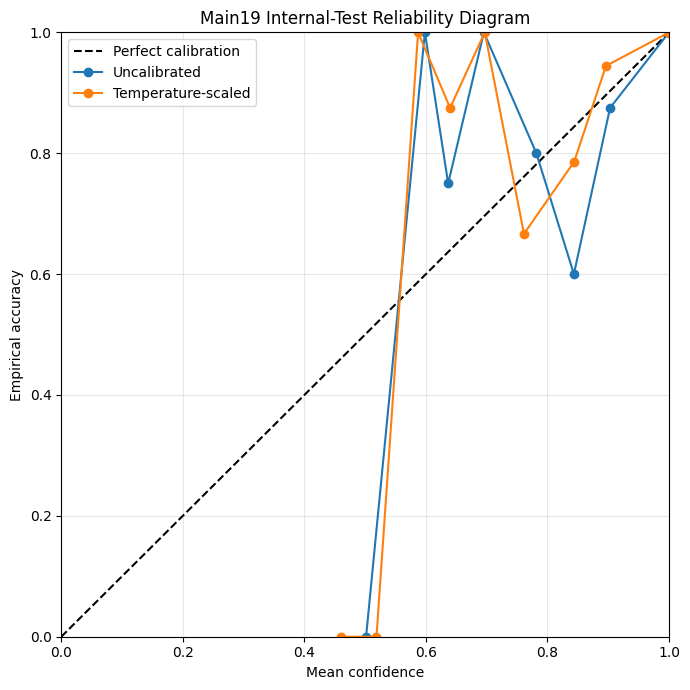

Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_internal_test_reliability_bins.csv
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/figures/efficientnet_b0_internal_test_reliability.png


In [41]:
def reliability_table(
    probabilities: np.ndarray,
    targets: np.ndarray,
    n_bins: int = 15,
) -> pd.DataFrame:
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = (predictions == targets).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []

    for bin_index, (lower, upper) in enumerate(
        zip(bins[:-1], bins[1:])
    ):
        if bin_index == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        count = int(in_bin.sum())

        rows.append(
            {
                "bin_lower": lower,
                "bin_upper": upper,
                "count": count,
                "fraction": float(count / len(targets)),
                "mean_confidence": (
                    float(confidences[in_bin].mean())
                    if count > 0 else np.nan
                ),
                "accuracy": (
                    float(correctness[in_bin].mean())
                    if count > 0 else np.nan
                ),
            }
        )

    return pd.DataFrame(rows)


reliability_uncalibrated = reliability_table(
    probabilities=test_predictions["probabilities"],
    targets=test_predictions["targets"],
)

reliability_scaled = reliability_table(
    probabilities=test_predictions_scaled["probabilities"],
    targets=test_predictions_scaled["targets"],
)

reliability_uncalibrated["scaling"] = "uncalibrated"
reliability_scaled["scaling"] = "temperature_scaled"

reliability_combined = pd.concat(
    [reliability_uncalibrated, reliability_scaled],
    ignore_index=True,
)

reliability_path = (
    OUTPUTS["reports"] / "efficientnet_b0_internal_test_reliability_bins.csv"
)

reliability_combined.to_csv(reliability_path, index=False)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")

for reliability_df, label, color in [
    (reliability_uncalibrated, "Uncalibrated", "tab:blue"),
    (reliability_scaled, "Temperature-scaled", "tab:orange"),
]:
    valid = reliability_df.dropna(subset=["mean_confidence", "accuracy"])

    plt.plot(
        valid["mean_confidence"],
        valid["accuracy"],
        marker="o",
        label=label,
        color=color,
    )

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Mean confidence")
plt.ylabel("Empirical accuracy")
plt.title("Main19 Internal-Test Reliability Diagram")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

reliability_figure_path = (
    OUTPUTS["figures"] / "efficientnet_b0_internal_test_reliability.png"
)

plt.savefig(reliability_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", reliability_path)
print("Saved:", reliability_figure_path)

In [42]:
def utc_now() -> str:
    return datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

final_run_metadata = {
    "created_utc": utc_now(),
    "run_name": RUN_NAME,
    "seed": SEED,
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "torchvision_version": __import__("torchvision").__version__,
    "python_version": sys.version,
    "manifest_path": str(MANIFEST_PATH),
    "manifest_fingerprint_sha256": observed_manifest_fingerprint,
    "split_counts": EXPECTED_COUNTS,
    "class_count": NUM_CLASSES,
    "class_to_index": class_to_index,
    "model_architecture": "efficientnet_b0",
    "model_initialization": checkpoint["initialization_metadata"],
    "selected_epoch": int(best_epoch),
    "best_calibration_macro_f1": float(best_calibration_macro_f1),
    "temperature": float(fitted_temperature),
    "selective_threshold": float(selected_threshold),
    "final_internal_test_metrics_uncalibrated": test_metrics,
    "final_internal_test_metrics_temperature_scaled": test_metrics_scaled,
    "exact_cross_split_duplicate_hash_disclosure": cross_split_summary,
    "protocol_statement": (
        "Train images were used only for parameter optimization. "
        "Calibration images were used for checkpoint selection, temperature "
        "fitting, and selective-threshold selection. Internal-test images "
        "were not used for training or model selection and were evaluated "
        "only after selection of the final checkpoint."
    ),
}

final_run_metadata_path = (
    OUTPUTS["reports"] / "efficientnet_b0_final_run_metadata.json"
)

with open(final_run_metadata_path, "w", encoding="utf-8") as file:
    json.dump(final_run_metadata, file, indent=2)

artifact_records = []

for category, directory in OUTPUTS.items():
    if not directory.exists() or not directory.is_dir():
        continue

    for path in sorted(directory.rglob("*")):
        if path.is_file():
            artifact_records.append(
                {
                    "category": category,
                    "relative_path": str(path.relative_to(OUTPUTS["root"])),
                    "bytes": int(path.stat().st_size),
                    "sha256": sha256_file(path),
                }
            )

artifact_inventory = pd.DataFrame(artifact_records)

artifact_inventory_path = (
    OUTPUTS["reports"] / "artifact_inventory.csv"
)

artifact_inventory.to_csv(artifact_inventory_path, index=False)

print("Final metadata:", final_run_metadata_path)
print("Artifact inventory:", artifact_inventory_path)

display(artifact_inventory)

Final metadata: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_final_run_metadata.json
Artifact inventory: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/artifact_inventory.csv


,category,relative_path,bytes,sha256
0,root,checkpoints/efficientnet_b0_main19_best.pt,48882997,ec380f6bd0392911a6322e1e6f176218f7e9a565d9322a...
1,root,figures/efficientnet_b0_internal_test_confusio...,394238,1c935d328cc0a2c0c51d15cc5073d3166ada1e7ed11344...
2,root,figures/efficientnet_b0_internal_test_reliabil...,156409,330157b1d8b0ef0e09e0b95dd60fc70fa1e1823ae22a65...
3,root,figures/efficientnet_b0_training_curves.png,210845,d4a5bb6bac9db6872b7bc6118b706e9a70838362b6057a...
4,root,predictions/efficientnet_b0_calibration_predic...,2089121,cdce8406c679b771a3c753bd846277f4ad9b6fffcad2a1...
5,root,predictions/efficientnet_b0_internal_test_pred...,3466856,f25699235cc8a41a29c30537c507297dbc7814a4d750c1...
6,root,reports/class_weights.csv,979,7ee6c6d4ad2bc4bf34f2dfda0c07eac32b9af8a645e1e3...
7,root,reports/efficientnet_b0_calibration_risk_cover...,3661,730ae4fdf5584f1cbe601b48495939d23a791fa5612b19...
8,root,reports/efficientnet_b0_calibration_selective_...,5292,7ffa4488b6abff3a8203d24f38fd26f7636ef8b0e64236...
9,root,reports/efficientnet_b0_final_run_metadata.json,3091,81d4cb731277cedf15186c9100feaf8d8c88de9284d241...


In [43]:
final_summary = pd.DataFrame(
    [
        {
            "run_name": RUN_NAME,
            "seed": SEED,
            "architecture": "EfficientNet-B0",
            "pretrained_initialization": checkpoint[
                "initialization_metadata"
            ]["pretrained"],
            "selected_epoch": best_epoch,
            "selection_metric": "calibration_macro_f1",
            "best_calibration_macro_f1": best_calibration_macro_f1,
            "temperature": fitted_temperature,
            "selective_threshold": selected_threshold,
            "internal_test_images": test_metrics["images"],
            "internal_test_accuracy": test_metrics["accuracy"],
            "internal_test_balanced_accuracy": (
                test_metrics["balanced_accuracy"]
            ),
            "internal_test_macro_f1": test_metrics["macro_f1"],
            "internal_test_weighted_f1": test_metrics["weighted_f1"],
            "internal_test_top5_accuracy": test_metrics["top5_accuracy"],
            "internal_test_nll_uncalibrated": test_metrics["nll"],
            "internal_test_brier_uncalibrated": test_metrics["brier_score"],
            "internal_test_ece15_uncalibrated": test_metrics["ece_15"],
            "internal_test_nll_scaled": test_metrics_scaled["nll"],
            "internal_test_brier_scaled": (
                test_metrics_scaled["brier_score"]
            ),
            "internal_test_ece15_scaled": test_metrics_scaled["ece_15"],
            "manifest_fingerprint_sha256": observed_manifest_fingerprint,
        }
    ]
)

final_summary_path = (
    OUTPUTS["reports"] / "efficientnet_b0_results_summary.csv"
)

final_summary.to_csv(final_summary_path, index=False)

display(final_summary)
print("Saved:", final_summary_path)

,run_name,seed,architecture,pretrained_initialization,selected_epoch,selection_metric,best_calibration_macro_f1,temperature,selective_threshold,internal_test_images,...,internal_test_macro_f1,internal_test_weighted_f1,internal_test_top5_accuracy,internal_test_nll_uncalibrated,internal_test_brier_uncalibrated,internal_test_ece15_uncalibrated,internal_test_nll_scaled,internal_test_brier_scaled,internal_test_ece15_scaled,manifest_fingerprint_sha256
0,efficientnet_b0_main19_audited_seed7,7,EfficientNet-B0,True,15,calibration_macro_f1,0.996697,1.155397,0.95,5322,...,0.996172,0.997752,1.0,0.007475,0.003778,0.001301,0.007628,0.003813,0.001592,b49811fbe0d6cea4488ea218cbd9541e9a29ee2625ef8c...


Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_results_summary.csv


In [44]:
assert checkpoint["selection_partition"] == "calibration"
assert checkpoint["selection_metric"] == "macro_f1"
assert checkpoint["internal_test_accessed_during_training"] is False
assert test_metrics["images"] == EXPECTED_COUNTS["internal_test"]
assert len(test_prediction_export) == EXPECTED_COUNTS["internal_test"]

print("FINAL PROTOCOL CHECK: PASS")
print(
    "The checkpoint was selected solely using calibration macro-F1, "
    "and internal-test evaluation was performed only after checkpoint selection."
)
print("All output artifacts are in:")
print(OUTPUTS["root"])

FINAL PROTOCOL CHECK: PASS
The checkpoint was selected solely using calibration macro-F1, and internal-test evaluation was performed only after checkpoint selection.
All output artifacts are in:
/kaggle/working/efficientnet_b0_main19_audited_seed7


In [45]:
#Plant doc

In [46]:
import json
from pathlib import Path

ACTIVE_SELECTIVE_THRESHOLD = 0.95

active_threshold_policy = {
    "status": "ACTIVE",
    "model": "EfficientNet-B0",
    "confidence_type": "uncalibrated_softmax",
    "selected_threshold": ACTIVE_SELECTIVE_THRESHOLD,
    "selection_partition": "Main19 calibration",
    "selection_method": (
        "Evaluate thresholds 0.50 through 0.99 on the frozen "
        "Main19 calibration split; retain thresholds with at least "
        "95% coverage; select minimum selective risk; use lower "
        "threshold as tie-breaker."
    ),
    "calibration_selection_metrics": {
        "coverage": 0.9924929621520175,
        "accepted_images": 3173,
        "rejected_images": 24,
        "selective_accuracy": 0.9993696816892531,
        "selective_risk": 0.0006303183107468913,
    },
    "internal_test_evaluation_metrics": {
        "coverage": 0.9900413378436678,
        "accepted_images": 5269,
        "rejected_images": 53,
        "selective_accuracy": 0.9994306329474284,
        "selective_risk": 0.0005693670525716045,
    },
    "internal_test_used_for_selection": False,
    "plantdoc_used_for_selection": False,
    "transfer_policy": (
        "Use this exact threshold unchanged as a source-domain "
        "transferred diagnostic on PlantDoc. Do not tune, replace, "
        "or recalibrate it after reviewing PlantDoc outcomes."
    ),
    "authoritative_threshold_artifact": (
        "efficientnet_b0_selective_threshold_calibration_only.json"
    ),
    "superseded_artifact": {
        "filename": "efficientnet_b0_selective_threshold_selection.json",
        "selected_threshold": 1.0,
        "status": "SUPERSEDED",
        "reason": (
            "The earlier threshold allowed degenerate low-coverage "
            "selection and accepted only 292 of 5,322 internal-test images."
        ),
    },
}

active_policy_path = (
    OUTPUTS["reports"]
    / "efficientnet_b0_active_selective_threshold_policy.json"
)

with open(active_policy_path, "w", encoding="utf-8") as file:
    json.dump(active_threshold_policy, file, indent=2)

assert active_policy_path.exists()

print("Active threshold:", ACTIVE_SELECTIVE_THRESHOLD)
print("Saved:", active_policy_path)

Active threshold: 0.95
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_active_selective_threshold_policy.json


In [47]:
from pathlib import Path
import json
import os
import pandas as pd
import numpy as np

PLANTDOC_ROOT = Path(
    "/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset"
)

MAIN19_RUN_ROOT = Path(
    "/kaggle/working/efficientnet_b0_main19_audited_seed7"
)

MAIN19_CHECKPOINT_PATH = (
    MAIN19_RUN_ROOT
    / "checkpoints"
    / "efficientnet_b0_main19_best.pt"
)

MAIN19_PROTOCOL_PATH = (
    MAIN19_RUN_ROOT
    / "reports"
    / "training_protocol.json"
)

MAIN19_TEMPERATURE_PATH = (
    MAIN19_RUN_ROOT
    / "reports"
    / "efficientnet_b0_temperature_scaling.json"
)

PLANTDOC_OUTPUT_ROOT = (
    MAIN19_RUN_ROOT
    / "external_evaluation"
    / "plantdoc_zero_shot_locked"
)

PLANTDOC_OUTPUTS = {
    "root": PLANTDOC_OUTPUT_ROOT,
    "reports": PLANTDOC_OUTPUT_ROOT / "reports",
    "predictions": PLANTDOC_OUTPUT_ROOT / "predictions",
    "figures": PLANTDOC_OUTPUT_ROOT / "figures",
}

for directory in PLANTDOC_OUTPUTS.values():
    directory.mkdir(parents=True, exist_ok=True)

assert PLANTDOC_ROOT.exists(), (
    f"PlantDoc path does not exist: {PLANTDOC_ROOT}"
)

assert MAIN19_CHECKPOINT_PATH.exists(), (
    f"Missing frozen Main19 checkpoint: {MAIN19_CHECKPOINT_PATH}"
)

assert MAIN19_PROTOCOL_PATH.exists(), (
    f"Missing Main19 protocol: {MAIN19_PROTOCOL_PATH}"
)

assert MAIN19_TEMPERATURE_PATH.exists(), (
    f"Missing frozen temperature-scaling file: {MAIN19_TEMPERATURE_PATH}"
)

print("PlantDoc root:", PLANTDOC_ROOT)
print("Main19 checkpoint:", MAIN19_CHECKPOINT_PATH)
print("External-evaluation output:", PLANTDOC_OUTPUT_ROOT)

PlantDoc root: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset
Main19 checkpoint: /kaggle/working/efficientnet_b0_main19_audited_seed7/checkpoints/efficientnet_b0_main19_best.pt
External-evaluation output: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked


In [48]:
IMAGE_SUFFIXES = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp",
}

def count_images_under(path: Path) -> int:
    return sum(
        1
        for file_path in path.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in IMAGE_SUFFIXES
    )

all_directories = sorted(
    [
        path
        for path in PLANTDOC_ROOT.rglob("*")
        if path.is_dir()
    ],
    key=lambda path: (
        len(path.relative_to(PLANTDOC_ROOT).parts),
        str(path).lower(),
    ),
)

directory_rows = []

for directory in all_directories:
    relative = directory.relative_to(PLANTDOC_ROOT)
    image_count = count_images_under(directory)

    direct_image_count = sum(
        1
        for file_path in directory.iterdir()
        if file_path.is_file()
        and file_path.suffix.lower() in IMAGE_SUFFIXES
    )

    directory_rows.append(
        {
            "relative_directory": str(relative),
            "depth": len(relative.parts),
            "direct_images": direct_image_count,
            "recursive_images": image_count,
        }
    )

plantdoc_directory_inventory = pd.DataFrame(directory_rows)

display(
    plantdoc_directory_inventory.sort_values(
        ["depth", "relative_directory"]
    ).reset_index(drop=True)
)

inventory_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_directory_inventory.csv"
)

plantdoc_directory_inventory.to_csv(inventory_path, index=False)

print("Total image files:", count_images_under(PLANTDOC_ROOT))
print("Total directories:", len(all_directories))
print("Saved:", inventory_path)

,relative_directory,depth,direct_images,recursive_images
0,test,1,0,252
1,train,1,0,2670
2,test/Apple_Scab_Leaf,2,10,10
3,test/Apple_leaf,2,9,9
4,test/Apple_rust_leaf,2,10,10
5,test/Bell_pepper_leaf,2,8,8
6,test/Bell_pepper_leaf_spot,2,9,9
7,test/Blueberry_leaf,2,11,11
8,test/Cherry_leaf,2,10,10
9,test/Corn_Gray_leaf_spot,2,4,4


Total image files: 2922
Total directories: 57
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/plantdoc_directory_inventory.csv


In [49]:
leaf_directories = plantdoc_directory_inventory[
    plantdoc_directory_inventory["direct_images"] > 0
].copy()

leaf_directories = leaf_directories.sort_values(
    ["relative_directory"]
).reset_index(drop=True)

display(leaf_directories)

leaf_directory_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_leaf_image_directories.csv"
)

leaf_directories.to_csv(leaf_directory_path, index=False)

print("Candidate category folders:", len(leaf_directories))
print("Saved:", leaf_directory_path)

,relative_directory,depth,direct_images,recursive_images
0,test/Apple_Scab_Leaf,2,10,10
1,test/Apple_leaf,2,9,9
2,test/Apple_rust_leaf,2,10,10
3,test/Bell_pepper_leaf,2,8,8
4,test/Bell_pepper_leaf_spot,2,9,9
5,test/Blueberry_leaf,2,11,11
6,test/Cherry_leaf,2,10,10
7,test/Corn_Gray_leaf_spot,2,4,4
8,test/Corn_leaf_blight,2,12,12
9,test/Corn_rust_leaf,2,10,10


Candidate category folders: 55
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/plantdoc_leaf_image_directories.csv


In [50]:
from datetime import datetime, timezone
import json
import pandas as pd

PLANTDOC_TEST_ROOT = PLANTDOC_ROOT / "test"

assert PLANTDOC_TEST_ROOT.exists(), (
    f"Expected PlantDoc test directory not found: {PLANTDOC_TEST_ROOT}"
)

FROZEN_PLANTDOC_MAPPING = {
    "Bell_pepper_leaf": {
        "main19_class": "bell_pepper_healthy",
        "mapping_type": "assumption_generic_leaf_as_healthy",
        "note": (
            "Generic bell-pepper leaf folder is mapped to the Main19 healthy "
            "class; this is a semantic assumption."
        ),
    },
    "Bell_pepper_leaf_spot": {
        "main19_class": "bell_pepper_bacterial_spot",
        "mapping_type": "semantic_mapping",
        "note": "Leaf spot mapped to bacterial spot.",
    },
    "Corn_Gray_leaf_spot": {
        "main19_class": "corn_cercospora_leaf_spot_gray_leaf_spot",
        "mapping_type": "semantic_mapping",
        "note": "Gray leaf spot mapped to the Main19 Cercospora/gray leaf spot class.",
    },
    "Corn_leaf_blight": {
        "main19_class": "corn_northern_leaf_blight",
        "mapping_type": "semantic_approximation",
        "note": (
            "PlantDoc leaf blight is broader than Main19 northern leaf blight; "
            "this mapping is explicitly reported as an approximation."
        ),
    },
    "Corn_rust_leaf": {
        "main19_class": "corn_common_rust",
        "mapping_type": "semantic_mapping",
        "note": "Corn rust mapped to common rust.",
    },
    "Potato_leaf_early_blight": {
        "main19_class": "potato_early_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Potato_leaf_late_blight": {
        "main19_class": "potato_late_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_Early_blight_leaf": {
        "main19_class": "tomato_early_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_Septoria_leaf_spot": {
        "main19_class": "tomato_septoria_leaf_spot",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf": {
        "main19_class": "tomato_healthy",
        "mapping_type": "assumption_generic_leaf_as_healthy",
        "note": (
            "Generic tomato leaf folder is mapped to the Main19 healthy class; "
            "this is a semantic assumption."
        ),
    },
    "Tomato_leaf_bacterial_spot": {
        "main19_class": "tomato_bacterial_spot",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_late_blight": {
        "main19_class": "tomato_late_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_mosaic_virus": {
        "main19_class": "tomato_tomato_mosaic_virus",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_yellow_virus": {
        "main19_class": "tomato_tomato_yellow_leaf_curl_virus",
        "mapping_type": "semantic_mapping",
        "note": (
            "PlantDoc abbreviated yellow-virus folder is mapped to "
            "Tomato Yellow Leaf Curl Virus."
        ),
    },
    "Tomato_mold_leaf": {
        "main19_class": "tomato_leaf_mold",
        "mapping_type": "semantic_mapping",
        "note": "Mold folder mapped to tomato leaf mold.",
    },
}

EXCLUDED_PLANTDOC_TEST_FOLDERS = {
    "Apple_Scab_Leaf",
    "Apple_leaf",
    "Apple_rust_leaf",
    "Blueberry_leaf",
    "Cherry_leaf",
    "Peach_leaf",
    "Raspberry_leaf",
    "Soyabean_leaf",
    "Squash_Powdery_mildew_leaf",
    "Strawberry_leaf",
    "grape_leaf",
    "grape_leaf_black_rot",
}

actual_test_folders = {
    path.name
    for path in PLANTDOC_TEST_ROOT.iterdir()
    if path.is_dir()
}

expected_folders = (
    set(FROZEN_PLANTDOC_MAPPING)
    | EXCLUDED_PLANTDOC_TEST_FOLDERS
)

assert actual_test_folders == expected_folders, (
    "PlantDoc test folders differ from the pre-specified mapping.\n"
    f"Unexpected: {sorted(actual_test_folders - expected_folders)}\n"
    f"Missing: {sorted(expected_folders - actual_test_folders)}"
)

mapping_rows = []

for folder_name, mapping in FROZEN_PLANTDOC_MAPPING.items():
    folder_path = PLANTDOC_TEST_ROOT / folder_name

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )

    mapping_rows.append(
        {
            "plantdoc_partition": "test",
            "plantdoc_folder": folder_name,
            "images": len(image_paths),
            "main19_class": mapping["main19_class"],
            "main19_class_index": class_to_index[mapping["main19_class"]],
            "mapping_type": mapping["mapping_type"],
            "mapping_note": mapping["note"],
            "included_in_metrics": True,
        }
    )

for folder_name in sorted(EXCLUDED_PLANTDOC_TEST_FOLDERS):
    folder_path = PLANTDOC_TEST_ROOT / folder_name

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )

    mapping_rows.append(
        {
            "plantdoc_partition": "test",
            "plantdoc_folder": folder_name,
            "images": len(image_paths),
            "main19_class": None,
            "main19_class_index": None,
            "mapping_type": "excluded_unsupported_crop_or_class",
            "mapping_note": (
                "Excluded from closed-set Main19 performance metrics because "
                "the crop or target class is not supported by Main19."
            ),
            "included_in_metrics": False,
        }
    )

plantdoc_mapping_df = (
    pd.DataFrame(mapping_rows)
    .sort_values(["included_in_metrics", "plantdoc_folder"], ascending=[False, True])
    .reset_index(drop=True)
)

included_images = int(
    plantdoc_mapping_df.loc[
        plantdoc_mapping_df["included_in_metrics"], "images"
    ].sum()
)

excluded_images = int(
    plantdoc_mapping_df.loc[
        ~plantdoc_mapping_df["included_in_metrics"], "images"
    ].sum()
)

assert len(FROZEN_PLANTDOC_MAPPING) == 15
assert included_images == 144
assert excluded_images == 108
assert included_images + excluded_images == 252

mapping_csv_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_to_main19_frozen_mapping.csv"
)

mapping_json_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_to_main19_frozen_mapping.json"
)

protocol_json_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_zero_shot_protocol.json"
)

plantdoc_mapping_df.to_csv(mapping_csv_path, index=False)

with open(mapping_json_path, "w", encoding="utf-8") as file:
    json.dump(FROZEN_PLANTDOC_MAPPING, file, indent=2)

plantdoc_protocol = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation_type": "zero_shot_external_domain_evaluation",
    "plantdoc_root": str(PLANTDOC_ROOT),
    "evaluated_partition": "test",
    "plantdoc_train_images_used": False,
    "plantdoc_images_used_for_training": False,
    "plantdoc_images_used_for_checkpoint_selection": False,
    "plantdoc_images_used_for_temperature_fitting": False,
    "plantdoc_images_used_for_confidence_threshold_selection": False,
    "plantdoc_images_used_for_augmentation_selection": False,
    "frozen_main19_checkpoint": str(MAIN19_CHECKPOINT_PATH),
    "frozen_manifest_fingerprint_sha256": observed_manifest_fingerprint,
    "mapped_folders": len(FROZEN_PLANTDOC_MAPPING),
    "mapped_images": included_images,
    "excluded_folders": len(EXCLUDED_PLANTDOC_TEST_FOLDERS),
    "excluded_images": excluded_images,
    "mapping_file_csv": str(mapping_csv_path),
    "mapping_file_json": str(mapping_json_path),
    "assumption_mappings": [
        "Bell_pepper_leaf -> bell_pepper_healthy",
        "Tomato_leaf -> tomato_healthy",
    ],
    "semantic_approximation_mappings": [
        "Corn_leaf_blight -> corn_northern_leaf_blight",
    ],
}

with open(protocol_json_path, "w", encoding="utf-8") as file:
    json.dump(plantdoc_protocol, file, indent=2)

display(plantdoc_mapping_df)

print("Included folders:", len(FROZEN_PLANTDOC_MAPPING))
print("Included test images:", included_images)
print("Excluded folders:", len(EXCLUDED_PLANTDOC_TEST_FOLDERS))
print("Excluded test images:", excluded_images)
print("Saved:", mapping_csv_path)
print("Saved:", mapping_json_path)
print("Saved:", protocol_json_path)

,plantdoc_partition,plantdoc_folder,images,main19_class,main19_class_index,mapping_type,mapping_note,included_in_metrics
0,test,Bell_pepper_leaf,8,bell_pepper_healthy,1.0,assumption_generic_leaf_as_healthy,Generic bell-pepper leaf folder is mapped to t...,True
1,test,Bell_pepper_leaf_spot,9,bell_pepper_bacterial_spot,0.0,semantic_mapping,Leaf spot mapped to bacterial spot.,True
2,test,Corn_Gray_leaf_spot,4,corn_cercospora_leaf_spot_gray_leaf_spot,2.0,semantic_mapping,Gray leaf spot mapped to the Main19 Cercospora...,True
3,test,Corn_leaf_blight,12,corn_northern_leaf_blight,5.0,semantic_approximation,PlantDoc leaf blight is broader than Main19 no...,True
4,test,Corn_rust_leaf,10,corn_common_rust,3.0,semantic_mapping,Corn rust mapped to common rust.,True
5,test,Potato_leaf_early_blight,14,potato_early_blight,6.0,semantic_mapping,Direct semantic mapping.,True
6,test,Potato_leaf_late_blight,8,potato_late_blight,8.0,semantic_mapping,Direct semantic mapping.,True
7,test,Tomato_Early_blight_leaf,9,tomato_early_blight,10.0,semantic_mapping,Direct semantic mapping.,True
8,test,Tomato_Septoria_leaf_spot,12,tomato_septoria_leaf_spot,14.0,semantic_mapping,Direct semantic mapping.,True
9,test,Tomato_leaf,8,tomato_healthy,11.0,assumption_generic_leaf_as_healthy,Generic tomato leaf folder is mapped to the Ma...,True


Included folders: 15
Included test images: 144
Excluded folders: 12
Excluded test images: 108
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/plantdoc_test_to_main19_frozen_mapping.csv
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/plantdoc_test_to_main19_frozen_mapping.json
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/plantdoc_zero_shot_protocol.json


In [51]:
from pathlib import Path
import hashlib
import pandas as pd

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)

    return digest.hexdigest()

included_mapping = plantdoc_mapping_df[
    plantdoc_mapping_df["included_in_metrics"]
].copy()

plantdoc_rows = []

for _, mapping_row in included_mapping.iterrows():
    folder_name = mapping_row["plantdoc_folder"]
    target_class = mapping_row["main19_class"]
    target_index = int(mapping_row["main19_class_index"])

    folder_path = PLANTDOC_TEST_ROOT / folder_name

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )

    for image_path in image_paths:
        relative_path = image_path.relative_to(PLANTDOC_ROOT)

        plantdoc_rows.append(
            {
                "image_id": (
                    f"{folder_name}::"
                    f"{image_path.name}::"
                    f"{sha256_file(image_path)}"
                ),
                "image_path": str(image_path),
                "relative_path": str(relative_path),
                "plantdoc_partition": "test",
                "plantdoc_folder": folder_name,
                "true_main19_class": target_class,
                "true_main19_index": target_index,
                "mapping_type": mapping_row["mapping_type"],
                "mapping_note": mapping_row["mapping_note"],
            }
        )

plantdoc_manifest = (
    pd.DataFrame(plantdoc_rows)
    .sort_values(["plantdoc_folder", "image_path"])
    .reset_index(drop=True)
)

assert len(plantdoc_manifest) == 144
assert plantdoc_manifest["image_id"].is_unique
assert plantdoc_manifest["true_main19_class"].isin(class_to_index).all()
assert plantdoc_manifest["true_main19_index"].between(
    0, NUM_CLASSES - 1
).all()
assert plantdoc_manifest["image_path"].map(
    lambda path: Path(path).is_file()
).all()

plantdoc_manifest_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_mapped_frozen_manifest.csv"
)

plantdoc_manifest.to_csv(plantdoc_manifest_path, index=False)

plantdoc_manifest_fingerprint = sha256_file(plantdoc_manifest_path)

plantdoc_manifest_hash_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_mapped_frozen_manifest_sha256.txt"
)

plantdoc_manifest_hash_path.write_text(
    plantdoc_manifest_fingerprint + "\n",
    encoding="utf-8",
)

display(plantdoc_manifest.head())

print("Mapped PlantDoc images:", len(plantdoc_manifest))
print("Mapped folders:", plantdoc_manifest["plantdoc_folder"].nunique())
print("Manifest:", plantdoc_manifest_path)
print("Manifest SHA-256:", plantdoc_manifest_fingerprint)

,image_id,image_path,relative_path,plantdoc_partition,plantdoc_folder,true_main19_class,true_main19_index,mapping_type,mapping_note
0,Bell_pepper_leaf::test_Bell_pepper leaf_1.jpg:...,/kaggle/input/datasets/nirmalsankalana/plantdo...,test/Bell_pepper_leaf/test_Bell_pepper leaf_1.jpg,test,Bell_pepper_leaf,bell_pepper_healthy,1,assumption_generic_leaf_as_healthy,Generic bell-pepper leaf folder is mapped to t...
1,Bell_pepper_leaf::test_Bell_pepper leaf_2.jpg:...,/kaggle/input/datasets/nirmalsankalana/plantdo...,test/Bell_pepper_leaf/test_Bell_pepper leaf_2.jpg,test,Bell_pepper_leaf,bell_pepper_healthy,1,assumption_generic_leaf_as_healthy,Generic bell-pepper leaf folder is mapped to t...
2,Bell_pepper_leaf::test_Bell_pepper leaf_3.jpg:...,/kaggle/input/datasets/nirmalsankalana/plantdo...,test/Bell_pepper_leaf/test_Bell_pepper leaf_3.jpg,test,Bell_pepper_leaf,bell_pepper_healthy,1,assumption_generic_leaf_as_healthy,Generic bell-pepper leaf folder is mapped to t...
3,Bell_pepper_leaf::test_Bell_pepper leaf_4.jpg:...,/kaggle/input/datasets/nirmalsankalana/plantdo...,test/Bell_pepper_leaf/test_Bell_pepper leaf_4.jpg,test,Bell_pepper_leaf,bell_pepper_healthy,1,assumption_generic_leaf_as_healthy,Generic bell-pepper leaf folder is mapped to t...
4,Bell_pepper_leaf::test_Bell_pepper leaf_5.jpg:...,/kaggle/input/datasets/nirmalsankalana/plantdo...,test/Bell_pepper_leaf/test_Bell_pepper leaf_5.jpg,test,Bell_pepper_leaf,bell_pepper_healthy,1,assumption_generic_leaf_as_healthy,Generic bell-pepper leaf folder is mapped to t...


Mapped PlantDoc images: 144
Mapped folders: 15
Manifest: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/plantdoc_test_mapped_frozen_manifest.csv
Manifest SHA-256: 5274ce5c5ac95ae3f226d157e2d733a8dd4f7c30b47a1b682b68765498b42477


In [52]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import torch

PLANTDOC_IMAGE_SIZE = 224
PLANTDOC_BATCH_SIZE = 32
PLANTDOC_NUM_WORKERS = min(4, os.cpu_count() or 2)

assert PLANTDOC_IMAGE_SIZE == IMAGE_SIZE, (
    "PlantDoc preprocessing must use the same input size as Main19 evaluation."
)

plantdoc_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

class PlantDocMappedDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        try:
            with Image.open(row["image_path"]) as image:
                image = image.convert("RGB")
        except Exception as error:
            raise RuntimeError(
                f"Could not read PlantDoc image: {row['image_path']}"
            ) from error

        image = self.transform(image)

        metadata = {
            "image_id": row["image_id"],
            "image_path": row["image_path"],
            "relative_path": row["relative_path"],
            "plantdoc_folder": row["plantdoc_folder"],
            "true_main19_class": row["true_main19_class"],
            "mapping_type": row["mapping_type"],
        }

        return image, int(row["true_main19_index"]), metadata


plantdoc_dataset = PlantDocMappedDataset(
    dataframe=plantdoc_manifest,
    transform=plantdoc_transform,
)

plantdoc_loader = DataLoader(
    plantdoc_dataset,
    batch_size=PLANTDOC_BATCH_SIZE,
    shuffle=False,
    num_workers=PLANTDOC_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PLANTDOC_NUM_WORKERS > 0,
)

images, targets, metadata = next(iter(plantdoc_loader))

assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert len(targets) == len(metadata["image_id"])

print("PlantDoc evaluation images:", len(plantdoc_dataset))
print("PlantDoc batches:", len(plantdoc_loader))
print("Example PlantDoc folder:", metadata["plantdoc_folder"][0])
print("Mapped Main19 target:", metadata["true_main19_class"][0])
print("Batch shape:", tuple(images.shape))

PlantDoc evaluation images: 144
PlantDoc batches: 5
Example PlantDoc folder: Bell_pepper_leaf
Mapped Main19 target: bell_pepper_healthy
Batch shape: (32, 3, 224, 224)


In [53]:
checkpoint = torch.load(
    MAIN19_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

print("Checkpoint keys:")
print(sorted(checkpoint.keys()))

assert checkpoint["selection_partition"] == "calibration"
assert checkpoint["selection_metric"] == "macro_f1"
assert checkpoint["internal_test_accessed_during_training"] is False

checkpoint_class_mapping = checkpoint["class_to_index"]

assert checkpoint_class_mapping == class_to_index, (
    "Checkpoint class mapping differs from the active Main19 mapping."
)

checkpoint_manifest_fingerprint = (
    checkpoint.get("manifest_fingerprint_sha256")
    or checkpoint.get("resolved_manifest_fingerprint_sha256")
)

assert checkpoint_manifest_fingerprint == observed_manifest_fingerprint, (
    "Checkpoint and verified Main19 manifest fingerprint do not match."
)

# The training notebook may have used one of several valid metadata keys.
initialization_metadata = (
    checkpoint.get("model_initialization")
    or checkpoint.get("initialization_metadata")
    or checkpoint.get("initialization")
    or checkpoint.get("model_metadata")
    or {}
)

# Look for the final metadata file written by the completed Main19 notebook.
run_metadata_path = (
    MAIN19_RUN_ROOT
    / "reports"
    / "efficientnet_b0_final_run_metadata.json"
)

run_metadata = {}

if run_metadata_path.exists():
    with open(run_metadata_path, "r", encoding="utf-8") as file:
        run_metadata = json.load(file)

run_initialization_metadata = (
    run_metadata.get("model_initialization")
    or run_metadata.get("initialization_metadata")
    or run_metadata.get("initialization")
    or {}
)

# Merge checkpoint and run metadata, prioritizing checkpoint metadata where present.
combined_initialization_metadata = {
    **run_initialization_metadata,
    **initialization_metadata,
}

pretrained_flag = combined_initialization_metadata.get("pretrained")
weights_name = combined_initialization_metadata.get("weights")

# Fallback to the recorded known initialization from this run.
if pretrained_flag is None:
    pretrained_flag = (
        weights_name == "EfficientNet_B0_Weights.IMAGENET1K_V1"
        or weights_name == "IMAGENET1K_V1"
    )

assert pretrained_flag is True, (
    "Could not verify pretrained initialization from checkpoint/run metadata.\n"
    f"Checkpoint initialization metadata: {initialization_metadata}\n"
    f"Run initialization metadata: {run_initialization_metadata}\n"
    f"Checkpoint keys: {sorted(checkpoint.keys())}"
)

frozen_model = build_efficientnet_b0(
    num_classes=NUM_CLASSES,
    require_pretrained_weights=False,
).to(DEVICE)

frozen_model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)
frozen_model.eval()

checkpoint_sha256 = sha256_file(MAIN19_CHECKPOINT_PATH)

print("\nCHECKPOINT PROVENANCE: PASS")
print("Checkpoint loaded:", MAIN19_CHECKPOINT_PATH)
print("Checkpoint SHA-256:", checkpoint_sha256)
print("Selected Main19 epoch:", checkpoint["epoch"])
print("Calibration macro-F1:", checkpoint["best_calibration_macro_f1"])
print("Main19 manifest fingerprint:", checkpoint_manifest_fingerprint)
print("Pretrained initialization verified:", pretrained_flag)
print("Initialization metadata:", combined_initialization_metadata)

Checkpoint keys:
['architecture', 'best_calibration_macro_f1', 'checkpoint_format_version', 'class_to_index', 'epoch', 'initialization_metadata', 'internal_test_accessed_during_training', 'manifest_fingerprint_sha256', 'model_state_dict', 'num_classes', 'optimizer_state_dict', 'scheduler_state_dict', 'seed', 'selection_metric', 'selection_partition', 'split_counts', 'training_config']

CHECKPOINT PROVENANCE: PASS
Checkpoint loaded: /kaggle/working/efficientnet_b0_main19_audited_seed7/checkpoints/efficientnet_b0_main19_best.pt
Checkpoint SHA-256: ec380f6bd0392911a6322e1e6f176218f7e9a565d9322a380da2088d8f4c4fb4
Selected Main19 epoch: 15
Calibration macro-F1: 0.9966970217531076
Main19 manifest fingerprint: b49811fbe0d6cea4488ea218cbd9541e9a29ee2625ef8c5cf6537317e764ed05
Pretrained initialization verified: True
Initialization metadata: {'weights': 'EfficientNet_B0_Weights.IMAGENET1K_V1', 'pretrained': True, 'weights_url': 'https://download.pytorch.org/models/efficientnet_b0_rwightman-7f581

In [54]:
with open(MAIN19_TEMPERATURE_PATH, "r", encoding="utf-8") as file:
    temperature_metadata = json.load(file)

FROZEN_TEMPERATURE = float(temperature_metadata["temperature"])

assert temperature_metadata["fitting_partition"] == "calibration"
assert temperature_metadata["manifest_fingerprint_sha256"] == (
    observed_manifest_fingerprint
)

ACTIVE_THRESHOLD_POLICY_PATH = (
    MAIN19_RUN_ROOT
    / "reports"
    / "efficientnet_b0_active_selective_threshold_policy.json"
)

CALIBRATION_THRESHOLD_EVIDENCE_PATH = (
    MAIN19_RUN_ROOT
    / "reports"
    / "efficientnet_b0_selective_threshold_calibration_only.json"
)

assert ACTIVE_THRESHOLD_POLICY_PATH.exists(), (
    f"Missing active threshold-policy artifact: {ACTIVE_THRESHOLD_POLICY_PATH}"
)

assert CALIBRATION_THRESHOLD_EVIDENCE_PATH.exists(), (
    "Missing calibration-only threshold evidence artifact: "
    f"{CALIBRATION_THRESHOLD_EVIDENCE_PATH}"
)

with open(ACTIVE_THRESHOLD_POLICY_PATH, "r", encoding="utf-8") as file:
    active_threshold_policy = json.load(file)

with open(CALIBRATION_THRESHOLD_EVIDENCE_PATH, "r", encoding="utf-8") as file:
    calibration_threshold_evidence = json.load(file)

FROZEN_CONFIDENCE_THRESHOLD = float(
    active_threshold_policy["selected_threshold"]
)

assert active_threshold_policy["status"] == "ACTIVE"
assert active_threshold_policy["selection_partition"] == "Main19 calibration"
assert active_threshold_policy["internal_test_used_for_selection"] is False
assert active_threshold_policy["plantdoc_used_for_selection"] is False

assert calibration_threshold_evidence["threshold_selection_split"] == "Main19 calibration"
assert np.isclose(
    FROZEN_CONFIDENCE_THRESHOLD,
    float(calibration_threshold_evidence["selected_threshold"]),
)
assert np.isclose(FROZEN_CONFIDENCE_THRESHOLD, 0.95)

print("Active frozen source-domain threshold:", FROZEN_CONFIDENCE_THRESHOLD)
print("Threshold policy:", ACTIVE_THRESHOLD_POLICY_PATH)
print("Calibration evidence:", CALIBRATION_THRESHOLD_EVIDENCE_PATH)

plantdoc_frozen_policy = {
    "evaluation_type": "locked_zero_shot_external_evaluation",
    "checkpoint_path": str(MAIN19_CHECKPOINT_PATH),
    "checkpoint_sha256": checkpoint_sha256,
    "selected_epoch": int(checkpoint["epoch"]),
    "checkpoint_selection_partition": checkpoint["selection_partition"],
    "checkpoint_selection_metric": checkpoint["selection_metric"],
    "main19_manifest_fingerprint_sha256": observed_manifest_fingerprint,
    "plantdoc_manifest_fingerprint_sha256": plantdoc_manifest_fingerprint,
    "input_size": IMAGE_SIZE,
    "evaluation_transform": "Resize(224,224), ToTensor(), ImageNet normalization",
    "temperature": FROZEN_TEMPERATURE,
    "temperature_fitting_partition": "Main19 calibration only",
    "confidence_threshold": FROZEN_CONFIDENCE_THRESHOLD,
    "threshold_selection_partition": "Main19 calibration only",
    "threshold_policy_path": str(ACTIVE_THRESHOLD_POLICY_PATH),
    "threshold_calibration_evidence_path": str(CALIBRATION_THRESHOLD_EVIDENCE_PATH),
    "superseded_threshold_artifact": str(
        MAIN19_RUN_ROOT
        / "reports"
        / "efficientnet_b0_selective_threshold_selection.json"
    ),
    "plantdoc_train_used": False,
    "plantdoc_tuning_used": False,
    "plantdoc_temperature_fitted": False,
    "plantdoc_threshold_fitted": False,
}

frozen_policy_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_frozen_evaluation_policy.json"
)

with open(frozen_policy_path, "w", encoding="utf-8") as file:
    json.dump(plantdoc_frozen_policy, file, indent=2)

assert FROZEN_CONFIDENCE_THRESHOLD == 0.95

print("Frozen temperature:", FROZEN_TEMPERATURE)
print("Frozen source-domain threshold:", FROZEN_CONFIDENCE_THRESHOLD)
print("Updated:", frozen_policy_path)

Active frozen source-domain threshold: 0.95
Threshold policy: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_active_selective_threshold_policy.json
Calibration evidence: /kaggle/working/efficientnet_b0_main19_audited_seed7/reports/efficientnet_b0_selective_threshold_calibration_only.json
Frozen temperature: 1.155396580696106
Frozen source-domain threshold: 0.95
Updated: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/plantdoc_frozen_evaluation_policy.json


In [55]:
with open(frozen_policy_path, "r", encoding="utf-8") as file:
    verify_policy = json.load(file)

assert verify_policy["evaluation_type"] == "locked_zero_shot_external_evaluation"
assert verify_policy["plantdoc_train_used"] is False
assert verify_policy["plantdoc_tuning_used"] is False
assert verify_policy["plantdoc_temperature_fitted"] is False
assert verify_policy["plantdoc_threshold_fitted"] is False
assert np.isclose(verify_policy["confidence_threshold"], 0.95)

print("PLANTDOC FROZEN POLICY: PASS")
print("Checkpoint:", verify_policy["checkpoint_path"])
print("Temperature:", verify_policy["temperature"])
print("Threshold:", verify_policy["confidence_threshold"])

PLANTDOC FROZEN POLICY: PASS
Checkpoint: /kaggle/working/efficientnet_b0_main19_audited_seed7/checkpoints/efficientnet_b0_main19_best.pt
Temperature: 1.155396580696106
Threshold: 0.95


In [56]:
@torch.inference_mode()
def collect_plantdoc_predictions(
    model: nn.Module,
    loader: DataLoader,
) -> dict:
    model.eval()

    all_logits = []
    all_targets = []
    all_image_ids = []
    all_paths = []
    all_relative_paths = []
    all_folders = []
    all_true_classes = []
    all_mapping_types = []

    for images, targets, metadata in tqdm(
        loader,
        desc="Locked PlantDoc inference",
        leave=True,
    ):
        images = images.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            enabled=DEVICE.type == "cuda",
        ):
            logits = model(images)

        all_logits.append(logits.float().cpu())
        all_targets.append(targets.cpu())

        all_image_ids.extend(metadata["image_id"])
        all_paths.extend(metadata["image_path"])
        all_relative_paths.extend(metadata["relative_path"])
        all_folders.extend(metadata["plantdoc_folder"])
        all_true_classes.extend(metadata["true_main19_class"])
        all_mapping_types.extend(metadata["mapping_type"])

    logits = torch.cat(all_logits).numpy()
    targets = torch.cat(all_targets).numpy().astype(int)

    uncalibrated_probabilities = torch.softmax(
        torch.from_numpy(logits),
        dim=1,
    ).numpy()

    temperature_scaled_probabilities = torch.softmax(
        torch.from_numpy(logits / FROZEN_TEMPERATURE),
        dim=1,
    ).numpy()

    return {
        "logits": logits,
        "targets": targets,
        "uncalibrated_probabilities": uncalibrated_probabilities,
        "scaled_probabilities": temperature_scaled_probabilities,
        "image_ids": all_image_ids,
        "paths": all_paths,
        "relative_paths": all_relative_paths,
        "folders": all_folders,
        "true_classes": all_true_classes,
        "mapping_types": all_mapping_types,
    }

plantdoc_predictions = collect_plantdoc_predictions(
    model=frozen_model,
    loader=plantdoc_loader,
)

assert len(plantdoc_predictions["targets"]) == 144
assert plantdoc_predictions["logits"].shape == (144, NUM_CLASSES)

print("Locked inference complete.")
print("Logit shape:", plantdoc_predictions["logits"].shape)

Locked PlantDoc inference:   0%|          | 0/5 [00:00<?, ?it/s]

Locked inference complete.
Logit shape: (144, 19)


In [57]:
import numpy as np
import torch

assert plantdoc_predictions["logits"].shape == (144, 19)
assert len(plantdoc_predictions["targets"]) == 144
assert FROZEN_CONFIDENCE_THRESHOLD == 0.95
assert FROZEN_TEMPERATURE == 1.155396580696106

plantdoc_logits = np.asarray(
    plantdoc_predictions["logits"],
    dtype=np.float64,
)

uncalibrated_probabilities = torch.softmax(
    torch.tensor(plantdoc_logits, dtype=torch.float64),
    dim=1,
).cpu().numpy()

uncalibrated_predictions = uncalibrated_probabilities.argmax(axis=1)
uncalibrated_confidences = uncalibrated_probabilities.max(axis=1)

assert uncalibrated_probabilities.shape == (144, 19)
assert np.allclose(
    uncalibrated_probabilities.sum(axis=1),
    1.0,
    atol=1e-10,
)

plantdoc_predictions["probabilities"] = uncalibrated_probabilities
plantdoc_predictions["predictions"] = uncalibrated_predictions
plantdoc_predictions["confidences"] = uncalibrated_confidences

print("PlantDoc prediction bundle keys:", sorted(plantdoc_predictions.keys()))
print("Probability shape:", plantdoc_predictions["probabilities"].shape)
print(
    "Confidence range:",
    float(plantdoc_predictions["confidences"].min()),
    "to",
    float(plantdoc_predictions["confidences"].max()),
)

PlantDoc prediction bundle keys: ['confidences', 'folders', 'image_ids', 'logits', 'mapping_types', 'paths', 'predictions', 'probabilities', 'relative_paths', 'scaled_probabilities', 'targets', 'true_classes', 'uncalibrated_probabilities']
Probability shape: (144, 19)
Confidence range: 0.2543897826968292 to 0.9999991860054536


In [58]:
plantdoc_predictions_path = (
    PLANTDOC_OUTPUTS["predictions"]
    / "efficientnet_b0_plantdoc_zero_shot_predictions.npz"
)

np.savez_compressed(
    plantdoc_predictions_path,
    logits=plantdoc_predictions["logits"],
    targets=plantdoc_predictions["targets"],
    probabilities=plantdoc_predictions["probabilities"],
    predictions=plantdoc_predictions["predictions"],
    confidences=plantdoc_predictions["confidences"],
)

assert plantdoc_predictions_path.exists()

print("Saved:", plantdoc_predictions_path)

Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/predictions/efficientnet_b0_plantdoc_zero_shot_predictions.npz


In [59]:
plantdoc_logits = plantdoc_predictions["logits"]
plantdoc_targets = plantdoc_predictions["targets"]

plantdoc_probabilities = torch.softmax(
    torch.tensor(plantdoc_logits),
    dim=1,
).numpy()

plantdoc_predictions["probabilities"] = plantdoc_probabilities
plantdoc_predictions["predictions"] = plantdoc_probabilities.argmax(axis=1)
plantdoc_predictions["confidences"] = plantdoc_probabilities.max(axis=1)

In [60]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    top_k_accuracy_score,
)

def multiclass_brier_score(probabilities, targets, num_classes):
    one_hot = np.eye(num_classes, dtype=np.float64)[targets]
    return np.mean(np.sum((probabilities - one_hot) ** 2, axis=1))

def expected_calibration_error(probabilities, targets, n_bins=15):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = (predictions == targets).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for bin_index in range(n_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        count = int(in_bin.sum())

        if count == 0:
            rows.append({
                "bin": bin_index,
                "lower": lower,
                "upper": upper,
                "count": 0,
                "accuracy": np.nan,
                "mean_confidence": np.nan,
            })
            continue

        bin_accuracy = float(correctness[in_bin].mean())
        bin_confidence = float(confidences[in_bin].mean())
        ece += (count / len(targets)) * abs(bin_accuracy - bin_confidence)

        rows.append({
            "bin": bin_index,
            "lower": lower,
            "upper": upper,
            "count": count,
            "accuracy": bin_accuracy,
            "mean_confidence": bin_confidence,
        })

    return float(ece), pd.DataFrame(rows)

def metric_row(probabilities, targets, scaling):
    top1 = probabilities.argmax(axis=1)

    return {
        "split": "plantdoc_zero_shot",
        "scaling": scaling,
        "images": int(len(targets)),
        "mapped_classes_present": int(len(np.unique(targets))),
        "top1_accuracy": float(accuracy_score(targets, top1)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, top1)
        ),
        "macro_f1": float(
            f1_score(targets, top1, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(targets, top1, average="weighted", zero_division=0)
        ),
        "top5_accuracy": float(
            top_k_accuracy_score(
                targets,
                probabilities,
                k=5,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "nll": float(
            log_loss(
                targets,
                probabilities,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "brier": float(
            multiclass_brier_score(
                probabilities,
                targets,
                NUM_CLASSES,
            )
        ),
        "mean_confidence": float(probabilities.max(axis=1).mean()),
        "median_confidence": float(np.median(probabilities.max(axis=1))),
    }

plantdoc_logits = np.asarray(plantdoc_predictions["logits"])
plantdoc_targets = np.asarray(plantdoc_predictions["targets"])

uncalibrated_probabilities = torch.softmax(
    torch.tensor(plantdoc_logits),
    dim=1,
).numpy()

scaled_probabilities = torch.softmax(
    torch.tensor(plantdoc_logits / FROZEN_TEMPERATURE),
    dim=1,
).numpy()

uncalibrated_ece, uncalibrated_bins = expected_calibration_error(
    uncalibrated_probabilities,
    plantdoc_targets,
    n_bins=15,
)

scaled_ece, scaled_bins = expected_calibration_error(
    scaled_probabilities,
    plantdoc_targets,
    n_bins=15,
)

plantdoc_metrics = pd.DataFrame([
    {
        **metric_row(
            uncalibrated_probabilities,
            plantdoc_targets,
            scaling="uncalibrated",
        ),
        "ece_15_bins": uncalibrated_ece,
    },
    {
        **metric_row(
            scaled_probabilities,
            plantdoc_targets,
            scaling="temperature_scaled",
        ),
        "ece_15_bins": scaled_ece,
    },
])

plantdoc_metrics_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "efficientnet_b0_plantdoc_zero_shot_metrics.csv"
)

plantdoc_metrics.to_csv(plantdoc_metrics_path, index=False)

display(plantdoc_metrics)
print("Saved:", plantdoc_metrics_path)



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,split,scaling,images,mapped_classes_present,top1_accuracy,balanced_accuracy,macro_f1,weighted_f1,top5_accuracy,nll,brier,mean_confidence,median_confidence,ece_15_bins
0,plantdoc_zero_shot,uncalibrated,144,15,0.215278,0.218783,0.18358,0.207818,0.645833,4.647152,1.280174,0.778737,0.847038,0.563459
1,plantdoc_zero_shot,temperature_scaled,144,15,0.215278,0.218783,0.18358,0.207818,0.645833,4.120165,1.232238,0.740031,0.782498,0.524753


Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/efficientnet_b0_plantdoc_zero_shot_metrics.csv


In [61]:
plantdoc_predictions["probabilities"] = uncalibrated_probabilities
plantdoc_predictions["predictions"] = uncalibrated_probabilities.argmax(axis=1)
plantdoc_predictions["confidences"] = uncalibrated_probabilities.max(axis=1)

plantdoc_selective_table = selective_prediction_table(
    prediction_bundle=plantdoc_predictions,
    thresholds=np.array([FROZEN_CONFIDENCE_THRESHOLD]),
).copy()

plantdoc_selective_table.insert(0, "split", "plantdoc_zero_shot")
plantdoc_selective_table.insert(
    1,
    "confidence_type",
    "uncalibrated_softmax",
)
plantdoc_selective_table.insert(
    2,
    "threshold_selection_split",
    "Main19_calibration",
)
plantdoc_selective_table.insert(
    3,
    "threshold_transfer_status",
    "frozen_source_domain_threshold",
)
plantdoc_selective_table.insert(
    4,
    "threshold",
    FROZEN_CONFIDENCE_THRESHOLD,
    allow_duplicates=True,
)

plantdoc_selective_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "efficientnet_b0_plantdoc_zero_shot_selective_prediction.csv"
)

plantdoc_selective_table.to_csv(
    plantdoc_selective_path,
    index=False,
)

display(plantdoc_selective_table)
print("Saved:", plantdoc_selective_path)

,split,confidence_type,threshold_selection_split,threshold_transfer_status,threshold,threshold,coverage,accepted_images,rejected_images,selective_accuracy,selective_risk
0,plantdoc_zero_shot,uncalibrated_softmax,Main19_calibration,frozen_source_domain_threshold,0.95,0.95,0.291667,42,102,0.285714,0.714286


Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/efficientnet_b0_plantdoc_zero_shot_selective_prediction.csv


In [62]:
#testing plantdoc train

In [63]:
PLANTDOC_TRAIN_ROOT = Path(
    "/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/train"
)

assert PLANTDOC_TRAIN_ROOT.exists(), PLANTDOC_TRAIN_ROOT
print("PlantDoc train root:", PLANTDOC_TRAIN_ROOT)

PlantDoc train root: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/train


In [64]:
PLANTDOC_FOLDER_TO_MAIN19_CLASS = {
    # Bell pepper
    "Bell_pepper_leaf": "bell_pepper_healthy",
    "Bell_pepper_leaf_spot": "bell_pepper_bacterial_spot",

    # Corn
    "Corn_Gray_leaf_spot": "corn_cercospora_leaf_spot_gray_leaf_spot",
    "Corn_leaf_blight": "corn_northern_leaf_blight",
    "Corn_rust_leaf": "corn_common_rust",

    # Potato
    "Potato_leaf_early_blight": "potato_early_blight",
    "Potato_leaf_late_blight": "potato_late_blight",

    # Tomato
    "Tomato_Early_blight_leaf": "tomato_early_blight",
    "Tomato_Septoria_leaf_spot": "tomato_septoria_leaf_spot",
    "Tomato_leaf": "tomato_healthy",
    "Tomato_leaf_bacterial_spot": "tomato_bacterial_spot",
    "Tomato_leaf_late_blight": "tomato_late_blight",
    "Tomato_leaf_mosaic_virus": "tomato_tomato_mosaic_virus",
    "Tomato_leaf_yellow_virus": "tomato_tomato_yellow_leaf_curl_virus",
    "Tomato_mold_leaf": "tomato_leaf_mold",
    "Tomato_two_spotted_spider_mites_leaf": (
        "tomato_spider_mites_two_spotted_spider_mite"
    ),
}

In [65]:
mapped_classes = set(PLANTDOC_FOLDER_TO_MAIN19_CLASS.values())

missing_class_names = sorted(
    mapped_classes - set(class_to_index.keys())
)

print("Mapping entries:", len(PLANTDOC_FOLDER_TO_MAIN19_CLASS))
print("Unique mapped classes:", len(mapped_classes))
print("Missing from class_to_index:", missing_class_names)

assert not missing_class_names

Mapping entries: 16
Unique mapped classes: 16
Missing from class_to_index: []


In [66]:
print("\n".join(sorted(class_to_index.keys())))

bell_pepper_bacterial_spot
bell_pepper_healthy
corn_cercospora_leaf_spot_gray_leaf_spot
corn_common_rust
corn_healthy
corn_northern_leaf_blight
potato_early_blight
potato_healthy
potato_late_blight
tomato_bacterial_spot
tomato_early_blight
tomato_healthy
tomato_late_blight
tomato_leaf_mold
tomato_septoria_leaf_spot
tomato_spider_mites_two_spotted_spider_mite
tomato_target_spot
tomato_tomato_mosaic_virus
tomato_tomato_yellow_leaf_curl_virus


In [67]:
available_train_folders = sorted(
    path.name
    for path in PLANTDOC_TRAIN_ROOT.iterdir()
    if path.is_dir()
)

print("Available PlantDoc train folders:")
for folder_name in available_train_folders:
    mapping_status = (
        PLANTDOC_FOLDER_TO_MAIN19_CLASS.get(
            folder_name,
            "EXCLUDED: no Main19-compatible mapping",
        )
    )
    print(f"{folder_name} --> {mapping_status}")

Available PlantDoc train folders:
Apple_Scab_Leaf --> EXCLUDED: no Main19-compatible mapping
Apple_leaf --> EXCLUDED: no Main19-compatible mapping
Apple_rust_leaf --> EXCLUDED: no Main19-compatible mapping
Bell_pepper_leaf --> bell_pepper_healthy
Bell_pepper_leaf_spot --> bell_pepper_bacterial_spot
Blueberry_leaf --> EXCLUDED: no Main19-compatible mapping
Cherry_leaf --> EXCLUDED: no Main19-compatible mapping
Corn_Gray_leaf_spot --> corn_cercospora_leaf_spot_gray_leaf_spot
Corn_leaf_blight --> corn_northern_leaf_blight
Corn_rust_leaf --> corn_common_rust
Peach_leaf --> EXCLUDED: no Main19-compatible mapping
Potato_leaf_early_blight --> potato_early_blight
Potato_leaf_late_blight --> potato_late_blight
Raspberry_leaf --> EXCLUDED: no Main19-compatible mapping
Soyabean_leaf --> EXCLUDED: no Main19-compatible mapping
Squash_Powdery_mildew_leaf --> EXCLUDED: no Main19-compatible mapping
Strawberry_leaf --> EXCLUDED: no Main19-compatible mapping
Tomato_Early_blight_leaf --> tomato_early_bli

In [68]:
from pathlib import Path
import pandas as pd

image_extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

plantdoc_train_rows = []

for folder_path in sorted(
    path for path in PLANTDOC_TRAIN_ROOT.iterdir() if path.is_dir()
):
    folder_name = folder_path.name

    if folder_name not in PLANTDOC_FOLDER_TO_MAIN19_CLASS:
        continue

    mapped_class_name = PLANTDOC_FOLDER_TO_MAIN19_CLASS[folder_name]
    mapped_class_index = class_to_index[mapped_class_name]

    for image_path in sorted(folder_path.rglob("*")):
        if not image_path.is_file():
            continue

        if image_path.suffix not in image_extensions:
            continue

        plantdoc_train_rows.append(
            {
                "path": str(image_path),
                "relative_path": str(image_path.relative_to(PLANTDOC_TRAIN_ROOT)),
                "folder": folder_name,
                "true_class": mapped_class_name,
                "target": mapped_class_index,
                "mapping_type": "semantic_mapping",
                "evaluation_partition": "plantdoc_train_diagnostic",
            }
        )

plantdoc_train_manifest = pd.DataFrame(plantdoc_train_rows)

assert len(plantdoc_train_manifest) > 0
assert plantdoc_train_manifest["target"].between(
    0, NUM_CLASSES - 1
).all()

print("Mapped PlantDoc train images:", len(plantdoc_train_manifest))
print(
    "Mapped Main19 classes present:",
    plantdoc_train_manifest["true_class"].nunique()
)

display(
    plantdoc_train_manifest.groupby(
        ["folder", "true_class"], dropna=False
    )
    .size()
    .reset_index(name="images")
    .sort_values(["true_class", "folder"])
)

Mapped PlantDoc train images: 1641
Mapped Main19 classes present: 16


,folder,true_class,images
1,Bell_pepper_leaf_spot,bell_pepper_bacterial_spot,74
0,Bell_pepper_leaf,bell_pepper_healthy,34
2,Corn_Gray_leaf_spot,corn_cercospora_leaf_spot_gray_leaf_spot,63
4,Corn_rust_leaf,corn_common_rust,107
3,Corn_leaf_blight,corn_northern_leaf_blight,182
5,Potato_leaf_early_blight,potato_early_blight,157
6,Potato_leaf_late_blight,potato_late_blight,200
10,Tomato_leaf_bacterial_spot,tomato_bacterial_spot,101
7,Tomato_Early_blight_leaf,tomato_early_blight,79
9,Tomato_leaf,tomato_healthy,44


In [69]:
from PIL import Image
from torch.utils.data import Dataset

class PlantDocManifestDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

        required_columns = {"path", "target"}
        missing_columns = required_columns - set(self.dataframe.columns)
        assert not missing_columns, (
            f"Manifest is missing required columns: {missing_columns}"
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["path"]) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        target = int(row["target"])

        return {
            "image": image,
            "target": target,
            "path": row["path"],
            "relative_path": row["relative_path"],
            "folder": row["folder"],
            "true_class": row["true_class"],
        }

In [70]:
from torchvision import transforms

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

print(eval_transform)

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [71]:
import os
import torch
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EVAL_BATCH_SIZE = 64
NUM_WORKERS = min(4, os.cpu_count() or 1)

print("DEVICE:", DEVICE)
print("EVAL_BATCH_SIZE:", EVAL_BATCH_SIZE)
print("NUM_WORKERS:", NUM_WORKERS)

DEVICE: cuda
EVAL_BATCH_SIZE: 64
NUM_WORKERS: 4


In [72]:
model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Model restored and placed on:", DEVICE)

Model restored and placed on: cuda


In [73]:
import numpy as np

@torch.inference_mode()
def collect_predictions(model, loader):
    model.eval()

    all_logits = []
    all_targets = []

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=(DEVICE.type == "cuda"),
        )
        targets = batch["target"]

        logits = model(images)

        all_logits.append(logits.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    return {
        "logits": np.concatenate(all_logits, axis=0),
        "targets": np.concatenate(all_targets, axis=0),
    }

In [74]:
plantdoc_train_dataset = PlantDocManifestDataset(
    dataframe=plantdoc_train_manifest,
    transform=eval_transform,
)

plantdoc_train_loader = DataLoader(
    plantdoc_train_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

plantdoc_train_predictions = collect_predictions(
    model=model,
    loader=plantdoc_train_loader,
)

assert plantdoc_train_predictions["logits"].shape == (
    len(plantdoc_train_manifest),
    NUM_CLASSES,
)

assert len(plantdoc_train_predictions["targets"]) == len(
    plantdoc_train_manifest
)

print("Train diagnostic logits shape:",
      plantdoc_train_predictions["logits"].shape)
print("Mapped diagnostic images:",
      len(plantdoc_train_manifest))

Train diagnostic logits shape: (1641, 19)
Mapped diagnostic images: 1641


In [75]:
plantdoc_train_dataset = PlantDocManifestDataset(
    dataframe=plantdoc_train_manifest,
    transform=eval_transform,
)

plantdoc_train_loader = DataLoader(
    plantdoc_train_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

plantdoc_train_predictions = collect_predictions(
    model=model,
    loader=plantdoc_train_loader,
)

assert plantdoc_train_predictions["logits"].shape[0] == len(
    plantdoc_train_manifest
)
assert plantdoc_train_predictions["logits"].shape[1] == NUM_CLASSES

print("Train diagnostic logits shape:",
      plantdoc_train_predictions["logits"].shape)
print("Mapped diagnostic images:",
      len(plantdoc_train_manifest))

Train diagnostic logits shape: (1641, 19)
Mapped diagnostic images: 1641


In [76]:
train_logits = np.asarray(
    plantdoc_train_predictions["logits"],
    dtype=np.float64,
)

plantdoc_train_predictions["uncalibrated_probabilities"] = torch.softmax(
    torch.tensor(train_logits, dtype=torch.float64),
    dim=1,
).numpy()

plantdoc_train_predictions["scaled_probabilities"] = torch.softmax(
    torch.tensor(
        train_logits / FROZEN_TEMPERATURE,
        dtype=torch.float64,
    ),
    dim=1,
).numpy()

plantdoc_train_predictions["predictions"] = (
    plantdoc_train_predictions["uncalibrated_probabilities"].argmax(axis=1)
)

plantdoc_train_predictions["confidences"] = (
    plantdoc_train_predictions["uncalibrated_probabilities"].max(axis=1)
)

assert np.allclose(
    plantdoc_train_predictions["uncalibrated_probabilities"].sum(axis=1),
    1.0,
    atol=1e-10,
)

In [77]:
PLANTDOC_TRAIN_DIAGNOSTIC = (
    PLANTDOC_OUTPUTS["root"]
    / "plantdoc_train_mapped_diagnostic"
)

for directory_name in ["predictions", "reports"]:
    (PLANTDOC_TRAIN_DIAGNOSTIC / directory_name).mkdir(
        parents=True,
        exist_ok=True,
    )

plantdoc_train_manifest.to_csv(
    PLANTDOC_TRAIN_DIAGNOSTIC
    / "reports"
    / "plantdoc_train_mapped_diagnostic_manifest.csv",
    index=False,
)

print("Diagnostic output:", PLANTDOC_TRAIN_DIAGNOSTIC)

Diagnostic output: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/plantdoc_train_mapped_diagnostic


In [78]:
#new training

In [79]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm.auto import tqdm

PLANTDOC_TRAIN_ROOT = PLANTDOC_ROOT / "train"

assert PLANTDOC_TRAIN_ROOT.exists(), (
    f"Expected PlantDoc train directory not found: {PLANTDOC_TRAIN_ROOT}"
)

PLANTDOC_TRAIN_OUTPUT_ROOT = (
    Path("/kaggle/working/efficientnet_b0_main19_audited_seed7")
    / "external_evaluation"
    / "plantdoc_train_exploratory"
)

PLANTDOC_TRAIN_OUTPUTS = {
    "root": PLANTDOC_TRAIN_OUTPUT_ROOT,
    "reports": PLANTDOC_TRAIN_OUTPUT_ROOT / "reports",
    "predictions": PLANTDOC_TRAIN_OUTPUT_ROOT / "predictions",
    "figures": PLANTDOC_TRAIN_OUTPUT_ROOT / "figures",
}

for output_dir in PLANTDOC_TRAIN_OUTPUTS.values():
    output_dir.mkdir(parents=True, exist_ok=True)

actual_train_folders = sorted(
    path.name
    for path in PLANTDOC_TRAIN_ROOT.iterdir()
    if path.is_dir()
)

mapped_train_folders = sorted(
    folder_name
    for folder_name in actual_train_folders
    if folder_name in FROZEN_PLANTDOC_MAPPING
)

unsupported_train_folders = sorted(
    folder_name
    for folder_name in actual_train_folders
    if folder_name not in FROZEN_PLANTDOC_MAPPING
)

print("PlantDoc train folders:", len(actual_train_folders))
print("Mapped Main19 folders:", len(mapped_train_folders))
print("Excluded/unsupported folders:", len(unsupported_train_folders))
print("\nMapped folders:")
print(mapped_train_folders)
print("\nExcluded/unsupported folders:")
print(unsupported_train_folders)

PlantDoc train folders: 28
Mapped Main19 folders: 15
Excluded/unsupported folders: 13

Mapped folders:
['Bell_pepper_leaf', 'Bell_pepper_leaf_spot', 'Corn_Gray_leaf_spot', 'Corn_leaf_blight', 'Corn_rust_leaf', 'Potato_leaf_early_blight', 'Potato_leaf_late_blight', 'Tomato_Early_blight_leaf', 'Tomato_Septoria_leaf_spot', 'Tomato_leaf', 'Tomato_leaf_bacterial_spot', 'Tomato_leaf_late_blight', 'Tomato_leaf_mosaic_virus', 'Tomato_leaf_yellow_virus', 'Tomato_mold_leaf']

Excluded/unsupported folders:
['Apple_Scab_Leaf', 'Apple_leaf', 'Apple_rust_leaf', 'Blueberry_leaf', 'Cherry_leaf', 'Peach_leaf', 'Raspberry_leaf', 'Soyabean_leaf', 'Squash_Powdery_mildew_leaf', 'Strawberry_leaf', 'Tomato_two_spotted_spider_mites_leaf', 'grape_leaf', 'grape_leaf_black_rot']


In [80]:
train_manifest_rows = []

for folder_name in actual_train_folders:
    folder_path = PLANTDOC_TRAIN_ROOT / folder_name

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )

    is_mapped = folder_name in FROZEN_PLANTDOC_MAPPING

    if is_mapped:
        mapping = FROZEN_PLANTDOC_MAPPING[folder_name]
        main19_class = mapping["main19_class"]
        main19_class_index = class_to_index[main19_class]
        mapping_type = mapping["mapping_type"]
        mapping_note = mapping["note"]
    else:
        main19_class = None
        main19_class_index = None
        mapping_type = "excluded_unsupported_crop_or_class"
        mapping_note = (
            "Excluded from closed-set Main19 performance metrics because "
            "the PlantDoc folder lacks a pre-specified Main19 mapping."
        )

    for image_path in image_paths:
        train_manifest_rows.append(
            {
                "plantdoc_partition": "train",
                "plantdoc_folder": folder_name,
                "image_path": str(image_path),
                "image_name": image_path.name,
                "main19_class": main19_class,
                "main19_class_index": main19_class_index,
                "mapping_type": mapping_type,
                "mapping_note": mapping_note,
                "included_in_metrics": is_mapped,
            }
        )

plantdoc_train_manifest = pd.DataFrame(train_manifest_rows)

assert len(plantdoc_train_manifest) > 0, "No PlantDoc train images found."

mapped_train_manifest = (
    plantdoc_train_manifest
    .loc[plantdoc_train_manifest["included_in_metrics"]]
    .copy()
    .sort_values(["plantdoc_folder", "image_name"])
    .reset_index(drop=True)
)

excluded_train_manifest = (
    plantdoc_train_manifest
    .loc[~plantdoc_train_manifest["included_in_metrics"]]
    .copy()
    .sort_values(["plantdoc_folder", "image_name"])
    .reset_index(drop=True)
)

assert mapped_train_manifest["main19_class_index"].notna().all()
assert mapped_train_manifest["image_path"].is_unique

train_manifest_csv_path = (
    PLANTDOC_TRAIN_OUTPUTS["reports"]
    / "plantdoc_train_to_main19_exploratory_manifest.csv"
)

plantdoc_train_manifest.to_csv(train_manifest_csv_path, index=False)

manifest_text = "\n".join(
    mapped_train_manifest[
        ["image_path", "plantdoc_folder", "main19_class", "main19_class_index"]
    ]
    .astype(str)
    .agg("|".join, axis=1)
)

train_manifest_fingerprint = hashlib.sha256(
    manifest_text.encode("utf-8")
).hexdigest()

train_folder_summary = (
    plantdoc_train_manifest
    .groupby(
        [
            "plantdoc_folder",
            "included_in_metrics",
            "main19_class",
            "main19_class_index",
            "mapping_type",
            "mapping_note",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="images")
    .sort_values(["included_in_metrics", "plantdoc_folder"], ascending=[False, True])
    .reset_index(drop=True)
)

train_folder_summary_path = (
    PLANTDOC_TRAIN_OUTPUTS["reports"]
    / "plantdoc_train_mapping_summary.csv"
)

train_folder_summary.to_csv(train_folder_summary_path, index=False)

display(train_folder_summary)

print("Mapped train images:", len(mapped_train_manifest))
print("Excluded train images:", len(excluded_train_manifest))
print("Mapped train classes present:",
      mapped_train_manifest["main19_class_index"].nunique())
print("Mapped manifest SHA-256:", train_manifest_fingerprint)
print("Saved:", train_manifest_csv_path)
print("Saved:", train_folder_summary_path)

,plantdoc_folder,included_in_metrics,main19_class,main19_class_index,mapping_type,mapping_note,images
0,Bell_pepper_leaf,True,bell_pepper_healthy,1.0,assumption_generic_leaf_as_healthy,Generic bell-pepper leaf folder is mapped to t...,34
1,Bell_pepper_leaf_spot,True,bell_pepper_bacterial_spot,0.0,semantic_mapping,Leaf spot mapped to bacterial spot.,74
2,Corn_Gray_leaf_spot,True,corn_cercospora_leaf_spot_gray_leaf_spot,2.0,semantic_mapping,Gray leaf spot mapped to the Main19 Cercospora...,63
3,Corn_leaf_blight,True,corn_northern_leaf_blight,5.0,semantic_approximation,PlantDoc leaf blight is broader than Main19 no...,182
4,Corn_rust_leaf,True,corn_common_rust,3.0,semantic_mapping,Corn rust mapped to common rust.,107
5,Potato_leaf_early_blight,True,potato_early_blight,6.0,semantic_mapping,Direct semantic mapping.,157
6,Potato_leaf_late_blight,True,potato_late_blight,8.0,semantic_mapping,Direct semantic mapping.,200
7,Tomato_Early_blight_leaf,True,tomato_early_blight,10.0,semantic_mapping,Direct semantic mapping.,79
8,Tomato_Septoria_leaf_spot,True,tomato_septoria_leaf_spot,14.0,semantic_mapping,Direct semantic mapping.,145
9,Tomato_leaf,True,tomato_healthy,11.0,assumption_generic_leaf_as_healthy,Generic tomato leaf folder is mapped to the Ma...,44


Mapped train images: 1639
Excluded train images: 1031
Mapped train classes present: 15
Mapped manifest SHA-256: e2a0fe35f055178798e19f34a20814386dc5aa08dbfa2fdf52395d58a40c9926
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_train_exploratory/reports/plantdoc_train_to_main19_exploratory_manifest.csv
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_train_exploratory/reports/plantdoc_train_mapping_summary.csv


In [81]:
class PlantDocMappedDataset(Dataset):
    def __init__(self, manifest, transform):
        self.manifest = manifest.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        row = self.manifest.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

        image_tensor = self.transform(image)

        return {
            "image": image_tensor,
            "target": int(row["main19_class_index"]),
            "index": index,
        }

plantdoc_train_dataset = PlantDocMappedDataset(
    mapped_train_manifest,
    transform=eval_transform,
)

plantdoc_train_loader = DataLoader(
    plantdoc_train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

assert len(plantdoc_train_dataset) == len(mapped_train_manifest)

print("Mapped exploratory PlantDoc-train images:", len(plantdoc_train_dataset))
print("Batches:", len(plantdoc_train_loader))

Mapped exploratory PlantDoc-train images: 1639
Batches: 52


In [82]:
import numpy as np
import torch
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [83]:
assert model is not None
assert len(plantdoc_train_dataset) > 0

model = model.to(device)
model.eval()

all_logits = []
all_targets = []
all_indices = []

with torch.no_grad():
    for batch in tqdm(
        plantdoc_train_loader,
        desc="PlantDoc train exploratory inference",
    ):
        images = batch["image"].to(device, non_blocking=True)

        logits = model(images)

        all_logits.append(logits.detach().cpu().numpy())
        all_targets.append(batch["target"].numpy())
        all_indices.append(batch["index"].numpy())

plantdoc_train_logits = np.concatenate(all_logits, axis=0)
plantdoc_train_targets = np.concatenate(all_targets, axis=0)
plantdoc_train_indices = np.concatenate(all_indices, axis=0)

assert plantdoc_train_logits.shape == (
    len(mapped_train_manifest),
    NUM_CLASSES,
)
assert plantdoc_train_targets.shape == (len(mapped_train_manifest),)
assert np.array_equal(
    plantdoc_train_indices,
    np.arange(len(mapped_train_manifest)),
)

print("Logits shape:", plantdoc_train_logits.shape)
print("Targets shape:", plantdoc_train_targets.shape)

PlantDoc train exploratory inference:   0%|          | 0/52 [00:00<?, ?it/s]

Logits shape: (1639, 19)
Targets shape: (1639,)


In [84]:
train_uncalibrated_probabilities = torch.softmax(
    torch.tensor(plantdoc_train_logits),
    dim=1,
).numpy()

train_scaled_probabilities = torch.softmax(
    torch.tensor(plantdoc_train_logits / FROZEN_TEMPERATURE),
    dim=1,
).numpy()

train_uncalibrated_ece, train_uncalibrated_bins = (
    expected_calibration_error(
        train_uncalibrated_probabilities,
        plantdoc_train_targets,
        n_bins=15,
    )
)

train_scaled_ece, train_scaled_bins = expected_calibration_error(
    train_scaled_probabilities,
    plantdoc_train_targets,
    n_bins=15,
)

plantdoc_train_metrics = pd.DataFrame([
    {
        **metric_row(
            train_uncalibrated_probabilities,
            plantdoc_train_targets,
            scaling="uncalibrated",
        ),
        "split": "plantdoc_train_exploratory",
        "ece_15_bins": train_uncalibrated_ece,
    },
    {
        **metric_row(
            train_scaled_probabilities,
            plantdoc_train_targets,
            scaling="temperature_scaled",
        ),
        "split": "plantdoc_train_exploratory",
        "ece_15_bins": train_scaled_ece,
    },
])

train_predictions_df = mapped_train_manifest.copy()

train_predictions_df["true_class_index"] = plantdoc_train_targets
train_predictions_df["predicted_class_index"] = (
    train_uncalibrated_probabilities.argmax(axis=1)
)
train_predictions_df["predicted_class"] = (
    train_predictions_df["predicted_class_index"]
    .map(index_to_class)
)
train_predictions_df["confidence_uncalibrated"] = (
    train_uncalibrated_probabilities.max(axis=1)
)
train_predictions_df["confidence_temperature_scaled"] = (
    train_scaled_probabilities.max(axis=1)
)
train_predictions_df["correct"] = (
    train_predictions_df["true_class_index"]
    == train_predictions_df["predicted_class_index"]
)

plantdoc_train_logits_path = (
    PLANTDOC_TRAIN_OUTPUTS["predictions"]
    / "efficientnet_b0_plantdoc_train_exploratory_logits.npz"
)

np.savez_compressed(
    plantdoc_train_logits_path,
    logits=plantdoc_train_logits,
    targets=plantdoc_train_targets,
    manifest_fingerprint_sha256=train_manifest_fingerprint,
    frozen_temperature=FROZEN_TEMPERATURE,
)

plantdoc_train_predictions_path = (
    PLANTDOC_TRAIN_OUTPUTS["predictions"]
    / "efficientnet_b0_plantdoc_train_exploratory_predictions.csv"
)

plantdoc_train_metrics_path = (
    PLANTDOC_TRAIN_OUTPUTS["reports"]
    / "efficientnet_b0_plantdoc_train_exploratory_metrics.csv"
)

plantdoc_train_predictions_df = train_predictions_df
plantdoc_train_predictions_df.to_csv(
    plantdoc_train_predictions_path,
    index=False,
)

plantdoc_train_metrics.to_csv(
    plantdoc_train_metrics_path,
    index=False,
)

display(plantdoc_train_metrics)

print("Saved:", plantdoc_train_logits_path)
print("Saved:", plantdoc_train_predictions_path)
print("Saved:", plantdoc_train_metrics_path)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,split,scaling,images,mapped_classes_present,top1_accuracy,balanced_accuracy,macro_f1,weighted_f1,top5_accuracy,nll,brier,mean_confidence,median_confidence,ece_15_bins
0,plantdoc_train_exploratory,uncalibrated,1639,15,0.172056,0.197546,0.136284,0.175056,0.61684,4.975188,1.316763,0.745756,0.788872,0.573699
1,plantdoc_train_exploratory,temperature_scaled,1639,15,0.172056,0.197546,0.136284,0.175056,0.61684,4.423446,1.269356,0.706138,0.726568,0.534082


Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_train_exploratory/predictions/efficientnet_b0_plantdoc_train_exploratory_logits.npz
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_train_exploratory/predictions/efficientnet_b0_plantdoc_train_exploratory_predictions.csv
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_train_exploratory/reports/efficientnet_b0_plantdoc_train_exploratory_metrics.csv


In [85]:
train_uncalibrated_bins_path = (
    PLANTDOC_TRAIN_OUTPUTS["reports"]
    / "efficientnet_b0_plantdoc_train_exploratory_reliability_uncalibrated.csv"
)

train_scaled_bins_path = (
    PLANTDOC_TRAIN_OUTPUTS["reports"]
    / "efficientnet_b0_plantdoc_train_exploratory_reliability_temperature_scaled.csv"
)

train_uncalibrated_bins.to_csv(
    train_uncalibrated_bins_path,
    index=False,
)

train_scaled_bins.to_csv(
    train_scaled_bins_path,
    index=False,
)

display(train_uncalibrated_bins)
display(train_scaled_bins)

print("Saved:", train_uncalibrated_bins_path)
print("Saved:", train_scaled_bins_path)

,bin,lower,upper,count,accuracy,mean_confidence
0,0,0.000000,0.066667,0,NaN,NaN
1,1,0.066667,0.133333,0,NaN,NaN
2,2,0.133333,0.200000,2,0.000000,0.187543
3,3,0.200000,0.266667,12,0.083333,0.244252
4,4,0.266667,0.333333,37,0.243243,0.298410
5,5,0.333333,0.400000,80,0.075000,0.365883
6,6,0.400000,0.466667,99,0.080808,0.437120
7,7,0.466667,0.533333,122,0.163934,0.502873
8,8,0.533333,0.600000,127,0.149606,0.568255
9,9,0.600000,0.666667,129,0.162791,0.632672


,bin,lower,upper,count,accuracy,mean_confidence
0,0,0.000000,0.066667,0,NaN,NaN
1,1,0.066667,0.133333,0,NaN,NaN
2,2,0.133333,0.200000,4,0.000000,0.183305
3,3,0.200000,0.266667,26,0.115385,0.245239
4,4,0.266667,0.333333,68,0.132353,0.307957
5,5,0.333333,0.400000,89,0.078652,0.371038
6,6,0.400000,0.466667,118,0.135593,0.433038
7,7,0.466667,0.533333,139,0.158273,0.499985
8,8,0.533333,0.600000,144,0.166667,0.566014
9,9,0.600000,0.666667,143,0.181818,0.632221


Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_train_exploratory/reports/efficientnet_b0_plantdoc_train_exploratory_reliability_uncalibrated.csv
Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_train_exploratory/reports/efficientnet_b0_plantdoc_train_exploratory_reliability_temperature_scaled.csv


In [86]:
plantdoc_train_protocol = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation_type": (
        "post_hoc_exploratory_external_domain_diagnostic"
    ),
    "interpretation": (
        "Exploratory analysis of PlantDoc's provided train partition. "
        "It is not the locked PlantDoc test result and must not replace, "
        "pool with, or be used to select among confirmatory test findings."
    ),
    "plantdoc_root": str(PLANTDOC_ROOT),
    "evaluated_partition": "train",
    "train_images_used_for_model_training": False,
    "train_images_used_for_checkpoint_selection": False,
    "train_images_used_for_temperature_fitting": False,
    "train_images_used_for_threshold_selection": False,
    "train_images_used_for_augmentation_selection": False,
    "model_checkpoint": str(MAIN19_CHECKPOINT_PATH),
    "frozen_temperature": float(FROZEN_TEMPERATURE),
    "mapped_images": int(len(mapped_train_manifest)),
    "excluded_images": int(len(excluded_train_manifest)),
    "mapped_main19_classes_present": int(
        mapped_train_manifest["main19_class_index"].nunique()
    ),
    "mapped_manifest_fingerprint_sha256": train_manifest_fingerprint,
    "test_mapping_source": str(mapping_json_path),
    "manifest_csv": str(train_manifest_csv_path),
    "metrics_csv": str(plantdoc_train_metrics_path),
    "predictions_csv": str(plantdoc_train_predictions_path),
    "logits_npz": str(plantdoc_train_logits_path),
}

plantdoc_train_protocol_path = (
    PLANTDOC_TRAIN_OUTPUTS["reports"]
    / "plantdoc_train_exploratory_protocol.json"
)

with open(plantdoc_train_protocol_path, "w", encoding="utf-8") as file:
    json.dump(plantdoc_train_protocol, file, indent=2)

print("Saved:", plantdoc_train_protocol_path)

Saved: /kaggle/working/efficientnet_b0_main19_audited_seed7/external_evaluation/plantdoc_train_exploratory/reports/plantdoc_train_exploratory_protocol.json


In [87]:
#training EfficientNet-V2-s and Vision transformer 

In [88]:
from pathlib import Path
import pandas as pd

MANIFEST_PATH = Path(
    "/kaggle/input/datasets/katakuricharlotte/manifestfileanalyse/"
    "main19_manifest_audit/reports/main19_resolved_frozen_manifest.csv"
)

assert MANIFEST_PATH.exists(), f"Manifest not found: {MANIFEST_PATH}"

manifest_df = pd.read_csv(MANIFEST_PATH)

print("Shape:", manifest_df.shape)
print("Columns:")
print(manifest_df.columns.tolist())

print("\nSplit counts:")
for column in ["split", "partition", "split_name"]:
    if column in manifest_df.columns:
        display(manifest_df[column].value_counts(dropna=False))
        break

display(manifest_df.head())

Shape: (26632, 11)
Columns:
['image_id_manifest', 'manifest_path', 'relative_path', 'resolved_path', 'class_name', 'crop', 'condition', 'split', 'sha256_manifest', 'phash_manifest', 'manifest_file']

Split counts:


split
train            18113
internal_test     5322
calibration       3197
Name: count, dtype: int64

,image_id_manifest,manifest_path,relative_path,resolved_path,class_name,crop,condition,split,sha256_manifest,phash_manifest,manifest_file
0,c17ba3e25a65b2241698859e1c25d0f043ad0c5bdedb64...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/024623ab-b...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,c17ba3e25a65b2241698859e1c25d0f043ad0c5bdedb64...,fac9ab1b95239065,main19_calibration.csv
1,969798562a180f39d4f1941a80b90ba9b199c9b8b7d8c8...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/05287bcb-6...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,969798562a180f39d4f1941a80b90ba9b199c9b8b7d8c8...,8b7d0063a3639b2f,main19_calibration.csv
2,972c4b01b9f325da74e04920e95dfba3c5d8ee61e2fcd8...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/06d752a4-d...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,972c4b01b9f325da74e04920e95dfba3c5d8ee61e2fcd8...,ba3ca1d0d24b333e,main19_calibration.csv
3,b29d9161ca31dd4a8ea54718ae9eabc771406cbd7ed914...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/0719e8e8-c...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,b29d9161ca31dd4a8ea54718ae9eabc771406cbd7ed914...,eeb4a51e86689c69,main19_calibration.csv
4,8abe7baa4dcc88e5a13fb8defc594ee48ecd6e66599aa0...,/kaggle/input/datasets/mohitsingh1804/plantvil...,"train/Pepper,_bell___Bacterial_spot/0a4c007d-4...",/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,bell_pepper,bacterial_spot,calibration,8abe7baa4dcc88e5a13fb8defc594ee48ecd6e66599aa0...,f9c1b519c60fd298,main19_calibration.csv


In [89]:
from pathlib import Path
import pandas as pd

MANIFEST_PATH = Path(
    "/kaggle/input/datasets/katakuricharlotte/manifestfileanalyse/"
    "main19_manifest_audit/reports/main19_resolved_frozen_manifest.csv"
)

assert MANIFEST_PATH.exists(), f"Missing frozen manifest: {MANIFEST_PATH}"

manifest_df = pd.read_csv(MANIFEST_PATH)

required_columns = {"resolved_path", "class_name", "split"}
missing_columns = required_columns - set(manifest_df.columns)

assert not missing_columns, (
    f"Manifest is missing: {missing_columns}\n"
    f"Available columns: {manifest_df.columns.tolist()}"
)

manifest_df = manifest_df.rename(
    columns={
        "resolved_path": "image_path",
        "class_name": "label",
    }
).copy()

manifest_df["image_path"] = manifest_df["image_path"].astype(str)
manifest_df["label"] = manifest_df["label"].astype(str)
manifest_df["split"] = manifest_df["split"].astype(str)

missing_image_paths = manifest_df.loc[
    ~manifest_df["image_path"].map(lambda x: Path(x).exists()),
    ["image_path", "label", "split"],
].copy()

assert missing_image_paths.empty, (
    f"{len(missing_image_paths)} manifest image paths do not exist.\n"
    f"Examples:\n{missing_image_paths.head(10).to_string(index=False)}"
)

train_df = (
    manifest_df.loc[manifest_df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

calibration_df = (
    manifest_df.loc[manifest_df["split"] == "calibration"]
    .copy()
    .reset_index(drop=True)
)

internal_test_df = (
    manifest_df.loc[manifest_df["split"] == "internal_test"]
    .copy()
    .reset_index(drop=True)
)

all_labels = sorted(train_df["label"].unique().tolist())
assert len(all_labels) == 19, f"Expected 19 classes, found {len(all_labels)}"

class_to_index = {label: idx for idx, label in enumerate(all_labels)}
index_to_class = {idx: label for label, idx in class_to_index.items()}

assert len(train_df) == 18113, f"Expected 18113 train images, found {len(train_df)}"
assert len(calibration_df) == 3197, f"Expected 3197 calibration images, found {len(calibration_df)}"
assert len(internal_test_df) == 5322, f"Expected 5322 internal-test images, found {len(internal_test_df)}"

print("Manifest:", MANIFEST_PATH)
print("Train:", len(train_df))
print("Calibration:", len(calibration_df))
print("Internal test:", len(internal_test_df))
print("Classes:", len(class_to_index))

display(train_df[["image_path", "label", "split", "crop", "condition"]].head())

Manifest: /kaggle/input/datasets/katakuricharlotte/manifestfileanalyse/main19_manifest_audit/reports/main19_resolved_frozen_manifest.csv
Train: 18113
Calibration: 3197
Internal test: 5322
Classes: 19


,image_path,label,split,crop,condition
0,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,train,bell_pepper,bacterial_spot
1,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,train,bell_pepper,bacterial_spot
2,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,train,bell_pepper,bacterial_spot
3,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,train,bell_pepper,bacterial_spot
4,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper_bacterial_spot,train,bell_pepper,bacterial_spot


In [90]:
# ============================================================
# EfficientNet-V2-S: audited Main19 training + internal test
# ============================================================

import os
import json
import time
import copy
import random
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    top_k_accuracy_score,
)
from tqdm.auto import tqdm

# ----------------------------
# Preconditions from manifest cell
# ----------------------------
required_variables = [
    "train_df",
    "calibration_df",
    "internal_test_df",
    "class_to_index",
    "index_to_class",
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

assert not missing_variables, (
    "Run the manifest-preparation cell first. "
    f"Missing variables: {missing_variables}"
)

assert len(train_df) == 18113
assert len(calibration_df) == 3197
assert len(internal_test_df) == 5322
assert len(class_to_index) == 19

# ----------------------------
# Fixed experiment configuration
# ----------------------------
SEED = 7
MODEL_NAME = "tf_efficientnetv2_s.in21k_ft_in1k"
RUN_NAME = "efficientnet_v2_s_main19_audited_seed7"

NUM_CLASSES = 19
IMAGE_SIZE = 384

# Tesla T4-safe defaults; lower batch size to 4 if CUDA out of memory occurs.
BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
NUM_WORKERS = 2

MAX_EPOCHS = 6
EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.0

RUN_ROOT = Path("/kaggle/working") / RUN_NAME

OUTPUTS = {
    "root": RUN_ROOT,
    "checkpoints": RUN_ROOT / "checkpoints",
    "figures": RUN_ROOT / "figures",
    "predictions": RUN_ROOT / "predictions",
    "reports": RUN_ROOT / "reports",
    "training": RUN_ROOT / "training",
}

for output_path in OUTPUTS.values():
    output_path.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Reproducibility
# ----------------------------
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ----------------------------
# Confirm audited labels
# ----------------------------
expected_class_order = [
    "bell_pepper_bacterial_spot",
    "bell_pepper_healthy",
    "corn_cercospora_leaf_spot_gray_leaf_spot",
    "corn_common_rust",
    "corn_healthy",
    "corn_northern_leaf_blight",
    "potato_early_blight",
    "potato_healthy",
    "potato_late_blight",
    "tomato_bacterial_spot",
    "tomato_early_blight",
    "tomato_healthy",
    "tomato_late_blight",
    "tomato_leaf_mold",
    "tomato_septoria_leaf_spot",
    "tomato_spider_mites_two_spotted_spider_mite",
    "tomato_target_spot",
    "tomato_tomato_mosaic_virus",
    "tomato_tomato_yellow_leaf_curl_virus",
]

assert [index_to_class[index] for index in range(NUM_CLASSES)] == expected_class_order

for dataframe in [train_df, calibration_df, internal_test_df]:
    dataframe["label"] = dataframe["label"].astype(str)
    dataframe["target"] = dataframe["label"].map(class_to_index)
    assert dataframe["target"].notna().all()
    assert dataframe["image_path"].map(lambda path: Path(path).exists()).all()

# ----------------------------
# Image transforms
# ----------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.75, 1.3333333333),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE / 0.875)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ----------------------------
# Dataset definition
# ----------------------------
class Main19Dataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

        return {
            "image": self.transform(image),
            "target": int(row["target"]),
            "index": index,
        }

train_dataset = Main19Dataset(train_df, train_transform)
calibration_dataset = Main19Dataset(calibration_df, eval_transform)
internal_test_dataset = Main19Dataset(internal_test_df, eval_transform)

# Use the same class-weighted principle as B0.
class_counts = (
    train_df["target"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

assert (class_counts > 0).all()

class_weights = (
    len(train_df) / (NUM_CLASSES * class_counts)
).astype(np.float32)

class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32,
    device=device,
)

class_weights_df = pd.DataFrame({
    "class_index": range(NUM_CLASSES),
    "class_name": [index_to_class[index] for index in range(NUM_CLASSES)],
    "train_images": class_counts.values,
    "class_weight": class_weights.values,
})

class_weights_path = OUTPUTS["reports"] / "efficientnet_v2_s_class_weights.csv"
class_weights_df.to_csv(class_weights_path, index=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

# ----------------------------
# EfficientNet-V2-S initialization
# ----------------------------
try:
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
    ).to(device)
except Exception as error:
    print("Primary model name failed:", repr(error))
    MODEL_NAME = "tf_efficientnetv2_s.in1k"
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
    ).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[6, 13],
    gamma=0.5,
)

# ----------------------------
# Evaluation helper
# ----------------------------
def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    logits_list = []
    targets_list = []

    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            images = batch["image"].to(device, non_blocking=True)
            targets = batch["target"].to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, targets)

            total_loss += loss.item() * images.size(0)
            logits_list.append(logits.detach().cpu().numpy())
            targets_list.append(targets.detach().cpu().numpy())

    logits = np.concatenate(logits_list, axis=0)
    targets = np.concatenate(targets_list, axis=0)
    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1,
    ).numpy()

    predictions = probabilities.argmax(axis=1)

    return {
        "loss": float(total_loss / len(loader.dataset)),
        "logits": logits,
        "targets": targets,
        "probabilities": probabilities,
        "predictions": predictions,
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(targets, predictions, average="macro", zero_division=0)
        ),
    }

# ----------------------------
# Training
# ----------------------------
best_epoch = None
best_calibration_macro_f1 = -np.inf
best_state_dict = None
patience_counter = 0
history_rows = []

checkpoint_path = (
    OUTPUTS["checkpoints"]
    / "efficientnet_v2_s_main19_audited_best.pt"
)

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()

    model.train()

    train_loss_total = 0.0
    train_correct = 0
    train_images_seen = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS}"):
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * images.size(0)
        train_correct += int((logits.argmax(dim=1) == targets).sum().item())
        train_images_seen += images.size(0)

    calibration_result = evaluate_model(
        model,
        calibration_loader,
        criterion,
    )

    scheduler.step()

    train_loss = train_loss_total / train_images_seen
    train_accuracy = train_correct / train_images_seen
    epoch_seconds = time.time() - epoch_start

    history_rows.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_accuracy),
        "calibration_loss": calibration_result["loss"],
        "calibration_accuracy": calibration_result["accuracy"],
        "calibration_balanced_accuracy": calibration_result["balanced_accuracy"],
        "calibration_macro_f1": calibration_result["macro_f1"],
        "learning_rate": float(optimizer.param_groups[0]["lr"]),
        "epoch_seconds": float(epoch_seconds),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={train_loss:.4f}, acc={train_accuracy:.4f} | "
        f"calibration loss={calibration_result['loss']:.4f}, "
        f"acc={calibration_result['accuracy']:.4f}, "
        f"macro-F1={calibration_result['macro_f1']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    if calibration_result["macro_f1"] > best_calibration_macro_f1:
        best_calibration_macro_f1 = calibration_result["macro_f1"]
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0

        torch.save(
            {
                "model_name": MODEL_NAME,
                "epoch": int(best_epoch),
                "best_calibration_macro_f1": float(best_calibration_macro_f1),
                "model_state_dict": best_state_dict,
                "class_to_index": class_to_index,
                "num_classes": NUM_CLASSES,
                "image_size": IMAGE_SIZE,
                "seed": SEED,
                "manifest_path": str(MANIFEST_PATH),
            },
            checkpoint_path,
        )

        assert checkpoint_path.exists()
        print(f"Saved best checkpoint: {checkpoint_path}")

    else:
        patience_counter += 1

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping after {epoch} epochs; "
                f"best epoch was {best_epoch}."
            )
            break

assert best_state_dict is not None
assert checkpoint_path.exists()

history_df = pd.DataFrame(history_rows)
history_path = OUTPUTS["training"] / "efficientnet_v2_s_training_history.csv"
history_df.to_csv(history_path, index=False)

# ----------------------------
# Final locked internal-test evaluation
# ----------------------------
model.load_state_dict(best_state_dict)
model.eval()

calibration_final = evaluate_model(
    model,
    calibration_loader,
    criterion,
)

internal_test_final = evaluate_model(
    model,
    internal_test_loader,
    criterion,
)

# Temperature fit: calibration logits only.
calibration_logits_tensor = torch.tensor(
    calibration_final["logits"],
    dtype=torch.float32,
    device=device,
)
calibration_targets_tensor = torch.tensor(
    calibration_final["targets"],
    dtype=torch.long,
    device=device,
)

log_temperature = torch.nn.Parameter(
    torch.zeros(1, device=device)
)

temperature_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.1,
    max_iter=50,
)

unweighted_nll = nn.CrossEntropyLoss()

def temperature_closure():
    temperature_optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    loss = unweighted_nll(
        calibration_logits_tensor / temperature,
        calibration_targets_tensor,
    )
    loss.backward()
    return loss

temperature_optimizer.step(temperature_closure)

FROZEN_TEMPERATURE = float(
    torch.exp(log_temperature).detach().cpu().item()
)

def multiclass_brier_score(probabilities, targets, num_classes):
    one_hot = np.eye(num_classes, dtype=np.float64)[targets]
    return float(
        np.mean(
            np.sum((probabilities - one_hot) ** 2, axis=1)
        )
    )

def expected_calibration_error(probabilities, targets, n_bins=15):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = (predictions == targets).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for bin_index in range(n_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == n_bins - 1:
            mask = (confidences >= lower) & (confidences <= upper)
        else:
            mask = (confidences >= lower) & (confidences < upper)

        count = int(mask.sum())

        if count == 0:
            rows.append({
                "bin": bin_index,
                "lower": lower,
                "upper": upper,
                "count": 0,
                "accuracy": np.nan,
                "mean_confidence": np.nan,
            })
            continue

        bin_accuracy = float(correctness[mask].mean())
        bin_confidence = float(confidences[mask].mean())

        ece += (count / len(targets)) * abs(
            bin_accuracy - bin_confidence
        )

        rows.append({
            "bin": bin_index,
            "lower": lower,
            "upper": upper,
            "count": count,
            "accuracy": bin_accuracy,
            "mean_confidence": bin_confidence,
        })

    return float(ece), pd.DataFrame(rows)

def metrics_row(probabilities, targets, scaling):
    predictions = probabilities.argmax(axis=1)

    return {
        "split": "internal_test",
        "scaling": scaling,
        "images": int(len(targets)),
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(targets, predictions, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(targets, predictions, average="weighted", zero_division=0)
        ),
        "top5_accuracy": float(
            top_k_accuracy_score(
                targets,
                probabilities,
                k=5,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "nll": float(
            torch.nn.functional.cross_entropy(
                torch.tensor(np.log(np.clip(probabilities, 1e-12, 1.0))),
                torch.tensor(targets),
            ).item()
        ),
        "brier_score": multiclass_brier_score(
            probabilities,
            targets,
            NUM_CLASSES,
        ),
        "mean_confidence": float(probabilities.max(axis=1).mean()),
        "median_confidence": float(
            np.median(probabilities.max(axis=1))
        ),
    }

internal_test_logits = internal_test_final["logits"]
internal_test_targets = internal_test_final["targets"]

internal_test_probs_uncalibrated = torch.softmax(
    torch.tensor(internal_test_logits),
    dim=1,
).numpy()

internal_test_probs_scaled = torch.softmax(
    torch.tensor(internal_test_logits / FROZEN_TEMPERATURE),
    dim=1,
).numpy()

uncalibrated_ece, uncalibrated_bins = expected_calibration_error(
    internal_test_probs_uncalibrated,
    internal_test_targets,
)

scaled_ece, scaled_bins = expected_calibration_error(
    internal_test_probs_scaled,
    internal_test_targets,
)

internal_test_metrics = pd.DataFrame([
    {
        **metrics_row(
            internal_test_probs_uncalibrated,
            internal_test_targets,
            scaling="uncalibrated",
        ),
        "ece_15_bins": uncalibrated_ece,
    },
    {
        **metrics_row(
            internal_test_probs_scaled,
            internal_test_targets,
            scaling="temperature_scaled",
        ),
        "ece_15_bins": scaled_ece,
    },
])

internal_test_metrics_path = (
    OUTPUTS["reports"]
    / "efficientnet_v2_s_internal_test_metrics.csv"
)

internal_test_metrics.to_csv(
    internal_test_metrics_path,
    index=False,
)

internal_test_predictions = internal_test_df.copy()
internal_test_predictions["true_class_index"] = internal_test_targets
internal_test_predictions["predicted_class_index"] = (
    internal_test_probs_uncalibrated.argmax(axis=1)
)
internal_test_predictions["predicted_class"] = (
    internal_test_predictions["predicted_class_index"]
    .map(index_to_class)
)
internal_test_predictions["confidence_uncalibrated"] = (
    internal_test_probs_uncalibrated.max(axis=1)
)
internal_test_predictions["confidence_temperature_scaled"] = (
    internal_test_probs_scaled.max(axis=1)
)
internal_test_predictions["correct"] = (
    internal_test_predictions["true_class_index"]
    == internal_test_predictions["predicted_class_index"]
)

internal_test_predictions_path = (
    OUTPUTS["predictions"]
    / "efficientnet_v2_s_internal_test_predictions.csv"
)

internal_test_predictions.to_csv(
    internal_test_predictions_path,
    index=False,
)

uncalibrated_bins_path = (
    OUTPUTS["reports"]
    / "efficientnet_v2_s_internal_test_reliability_uncalibrated.csv"
)

scaled_bins_path = (
    OUTPUTS["reports"]
    / "efficientnet_v2_s_internal_test_reliability_temperature_scaled.csv"
)

uncalibrated_bins.to_csv(uncalibrated_bins_path, index=False)
scaled_bins.to_csv(scaled_bins_path, index=False)

run_metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "run_name": RUN_NAME,
    "seed": SEED,
    "device": str(device),
    "model_architecture": MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": "MultiStepLR",
    "scheduler_milestones": [6, 13],
    "scheduler_gamma": 0.5,
    "loss": "class-weighted CrossEntropyLoss",
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "checkpoint_criterion": "calibration_macro_f1",
    "manifest_path": str(MANIFEST_PATH),
    "split_counts": {
        "train": len(train_df),
        "calibration": len(calibration_df),
        "internal_test": len(internal_test_df),
    },
    "class_count": NUM_CLASSES,
    "class_to_index": class_to_index,
    "selected_epoch": int(best_epoch),
    "best_calibration_macro_f1": float(best_calibration_macro_f1),
    "temperature": float(FROZEN_TEMPERATURE),
    "checkpoint_path": str(checkpoint_path),
    "internal_test_metrics": (
        internal_test_metrics
        .set_index("scaling")
        .to_dict(orient="index")
    ),
}

metadata_path = (
    OUTPUTS["reports"]
    / "efficientnet_v2_s_final_run_metadata.json"
)

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(run_metadata, file, indent=2)

display(internal_test_metrics)

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best calibration macro-F1:", best_calibration_macro_f1)
print("Frozen temperature:", FROZEN_TEMPERATURE)
print("Checkpoint:", checkpoint_path)
print("Internal-test metrics:", internal_test_metrics_path)
print("Run metadata:", metadata_path)

Device: cuda
GPU: Tesla T4


model.safetensors: reconstructing file:   0%|          |  0.00B / 86.5MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1/6:   0%|          | 0/1133 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

Epoch 06 | train loss=0.0724, acc=0.9782 | calibration loss=0.0325, acc=0.9928, macro-F1=0.9919 | lr=1.50e-04
Saved best checkpoint: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/checkpoints/efficientnet_v2_s_main19_audited_best.pt


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/333 [00:00<?, ?it/s]

,split,scaling,images,accuracy,balanced_accuracy,macro_f1,weighted_f1,top5_accuracy,nll,brier_score,mean_confidence,median_confidence,ece_15_bins
0,internal_test,uncalibrated,5322,0.989102,0.988073,0.985765,0.989126,1.0,0.035504,0.016358,0.993884,0.999999,0.005223
1,internal_test,temperature_scaled,5322,0.989102,0.988073,0.985765,0.989126,1.0,0.032546,0.016025,0.990705,0.999967,0.002810



Training complete.
Best epoch: 6
Best calibration macro-F1: 0.9919181237182344
Frozen temperature: 1.3050073385238647
Checkpoint: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/checkpoints/efficientnet_v2_s_main19_audited_best.pt
Internal-test metrics: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/reports/efficientnet_v2_s_internal_test_metrics.csv
Run metadata: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/reports/efficientnet_v2_s_final_run_metadata.json


In [91]:
# ============================================================
# EfficientNet-V2-S: locked PlantDoc test zero-shot evaluation
# ============================================================

import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    top_k_accuracy_score,
)
from tqdm.auto import tqdm

# ----------------------------
# Fixed paths and run settings
# ----------------------------
RUN_ROOT = Path("/kaggle/working/efficientnet_v2_s_main19_audited_seed7")

CHECKPOINT_PATH = (
    RUN_ROOT
    / "checkpoints"
    / "efficientnet_v2_s_main19_audited_best.pt"
)

METADATA_PATH = (
    RUN_ROOT
    / "reports"
    / "efficientnet_v2_s_final_run_metadata.json"
)

PLANTDOC_ROOT = Path(
    "/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset"
)

PLANTDOC_TEST_ROOT = PLANTDOC_ROOT / "test"

PLANTDOC_OUTPUT_ROOT = (
    RUN_ROOT
    / "external_evaluation"
    / "plantdoc_zero_shot_locked"
)

PLANTDOC_OUTPUTS = {
    "root": PLANTDOC_OUTPUT_ROOT,
    "reports": PLANTDOC_OUTPUT_ROOT / "reports",
    "predictions": PLANTDOC_OUTPUT_ROOT / "predictions",
    "figures": PLANTDOC_OUTPUT_ROOT / "figures",
}

for output_path in PLANTDOC_OUTPUTS.values():
    output_path.mkdir(parents=True, exist_ok=True)

assert CHECKPOINT_PATH.exists(), (
    f"Checkpoint not found: {CHECKPOINT_PATH}"
)

assert METADATA_PATH.exists(), (
    f"Run metadata not found: {METADATA_PATH}"
)

assert PLANTDOC_TEST_ROOT.exists(), (
    f"PlantDoc test folder not found: {PLANTDOC_TEST_ROOT}"
)

# ----------------------------
# Load audited V2-S checkpoint
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

MODEL_NAME = checkpoint["model_name"]
NUM_CLASSES = int(checkpoint["num_classes"])
IMAGE_SIZE = int(checkpoint["image_size"])
class_to_index = checkpoint["class_to_index"]
index_to_class = {
    int(index): class_name
    for class_name, index in class_to_index.items()
}

assert NUM_CLASSES == 19
assert len(class_to_index) == 19
assert IMAGE_SIZE == 384

model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    run_metadata = json.load(file)

FROZEN_TEMPERATURE = float(run_metadata["temperature"])

assert np.isfinite(FROZEN_TEMPERATURE)
assert FROZEN_TEMPERATURE > 0

print("Device:", device)
print("Model:", MODEL_NAME)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Image size:", IMAGE_SIZE)
print("Frozen temperature:", FROZEN_TEMPERATURE)
print("Checkpoint:", CHECKPOINT_PATH)

# ----------------------------
# Locked PlantDoc mapping
# ----------------------------
FROZEN_PLANTDOC_MAPPING = {
    "Bell_pepper_leaf": {
        "main19_class": "bell_pepper_healthy",
        "mapping_type": "assumption_generic_leaf_as_healthy",
        "note": (
            "Generic bell-pepper leaf folder is mapped to the Main19 healthy "
            "class; this is a semantic assumption."
        ),
    },
    "Bell_pepper_leaf_spot": {
        "main19_class": "bell_pepper_bacterial_spot",
        "mapping_type": "semantic_mapping",
        "note": "Leaf spot mapped to bacterial spot.",
    },
    "Corn_Gray_leaf_spot": {
        "main19_class": "corn_cercospora_leaf_spot_gray_leaf_spot",
        "mapping_type": "semantic_mapping",
        "note": (
            "Gray leaf spot mapped to the Main19 Cercospora/gray leaf spot class."
        ),
    },
    "Corn_leaf_blight": {
        "main19_class": "corn_northern_leaf_blight",
        "mapping_type": "semantic_approximation",
        "note": (
            "PlantDoc leaf blight is broader than Main19 northern leaf blight; "
            "this mapping is explicitly reported as an approximation."
        ),
    },
    "Corn_rust_leaf": {
        "main19_class": "corn_common_rust",
        "mapping_type": "semantic_mapping",
        "note": "Corn rust mapped to common rust.",
    },
    "Potato_leaf_early_blight": {
        "main19_class": "potato_early_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Potato_leaf_late_blight": {
        "main19_class": "potato_late_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_Early_blight_leaf": {
        "main19_class": "tomato_early_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_Septoria_leaf_spot": {
        "main19_class": "tomato_septoria_leaf_spot",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf": {
        "main19_class": "tomato_healthy",
        "mapping_type": "assumption_generic_leaf_as_healthy",
        "note": (
            "Generic tomato leaf folder is mapped to the Main19 healthy "
            "class; this is a semantic assumption."
        ),
    },
    "Tomato_leaf_bacterial_spot": {
        "main19_class": "tomato_bacterial_spot",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_late_blight": {
        "main19_class": "tomato_late_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_mosaic_virus": {
        "main19_class": "tomato_tomato_mosaic_virus",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_yellow_virus": {
        "main19_class": "tomato_tomato_yellow_leaf_curl_virus",
        "mapping_type": "semantic_mapping",
        "note": (
            "PlantDoc abbreviated yellow-virus folder is mapped to "
            "Tomato Yellow Leaf Curl Virus."
        ),
    },
    "Tomato_mold_leaf": {
        "main19_class": "tomato_leaf_mold",
        "mapping_type": "semantic_mapping",
        "note": "Mold folder mapped to tomato leaf mold.",
    },
}

EXCLUDED_PLANTDOC_TEST_FOLDERS = {
    "Apple_Scab_Leaf",
    "Apple_leaf",
    "Apple_rust_leaf",
    "Blueberry_leaf",
    "Cherry_leaf",
    "Peach_leaf",
    "Raspberry_leaf",
    "Soyabean_leaf",
    "Squash_Powdery_mildew_leaf",
    "Strawberry_leaf",
    "grape_leaf",
    "grape_leaf_black_rot",
}

# ----------------------------
# Verify PlantDoc test structure and build manifest
# ----------------------------
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}

actual_test_folders = {
    path.name
    for path in PLANTDOC_TEST_ROOT.iterdir()
    if path.is_dir()
}

expected_test_folders = (
    set(FROZEN_PLANTDOC_MAPPING)
    | EXCLUDED_PLANTDOC_TEST_FOLDERS
)

assert actual_test_folders == expected_test_folders, (
    "PlantDoc test folders differ from the frozen mapping.\n"
    f"Unexpected: {sorted(actual_test_folders - expected_test_folders)}\n"
    f"Missing: {sorted(expected_test_folders - actual_test_folders)}"
)

mapping_rows = []
manifest_rows = []

for folder_name in sorted(actual_test_folders):
    folder_path = PLANTDOC_TEST_ROOT / folder_name

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )

    if folder_name in FROZEN_PLANTDOC_MAPPING:
        mapping = FROZEN_PLANTDOC_MAPPING[folder_name]
        main19_class = mapping["main19_class"]

        assert main19_class in class_to_index, (
            f"Mapped PlantDoc class absent from checkpoint mapping: {main19_class}"
        )

        main19_class_index = int(class_to_index[main19_class])
        included_in_metrics = True
        mapping_type = mapping["mapping_type"]
        mapping_note = mapping["note"]
    else:
        main19_class = None
        main19_class_index = None
        included_in_metrics = False
        mapping_type = "excluded_unsupported_crop_or_class"
        mapping_note = (
            "Excluded from closed-set Main19 metrics because the crop or "
            "target class is not supported by Main19."
        )

    mapping_rows.append({
        "plantdoc_partition": "test",
        "plantdoc_folder": folder_name,
        "images": len(image_paths),
        "main19_class": main19_class,
        "main19_class_index": main19_class_index,
        "mapping_type": mapping_type,
        "mapping_note": mapping_note,
        "included_in_metrics": included_in_metrics,
    })

    if included_in_metrics:
        for image_path in image_paths:
            manifest_rows.append({
                "plantdoc_partition": "test",
                "plantdoc_folder": folder_name,
                "image_path": str(image_path),
                "image_name": image_path.name,
                "main19_class": main19_class,
                "main19_class_index": main19_class_index,
                "mapping_type": mapping_type,
                "mapping_note": mapping_note,
                "included_in_metrics": True,
            })

plantdoc_mapping_df = (
    pd.DataFrame(mapping_rows)
    .sort_values(
        ["included_in_metrics", "plantdoc_folder"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

plantdoc_manifest_df = (
    pd.DataFrame(manifest_rows)
    .sort_values(["plantdoc_folder", "image_name"])
    .reset_index(drop=True)
)

included_images = int(
    plantdoc_mapping_df.loc[
        plantdoc_mapping_df["included_in_metrics"],
        "images",
    ].sum()
)

excluded_images = int(
    plantdoc_mapping_df.loc[
        ~plantdoc_mapping_df["included_in_metrics"],
        "images",
    ].sum()
)

assert len(FROZEN_PLANTDOC_MAPPING) == 15
assert included_images == 144, f"Expected 144 mapped images, got {included_images}"
assert excluded_images == 108, f"Expected 108 excluded images, got {excluded_images}"
assert len(plantdoc_manifest_df) == 144

mapping_csv_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_to_main19_frozen_mapping.csv"
)

mapping_json_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_to_main19_frozen_mapping.json"
)

manifest_csv_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_mapped_manifest.csv"
)

plantdoc_mapping_df.to_csv(mapping_csv_path, index=False)
plantdoc_manifest_df.to_csv(manifest_csv_path, index=False)

with open(mapping_json_path, "w", encoding="utf-8") as file:
    json.dump(FROZEN_PLANTDOC_MAPPING, file, indent=2)

print("Mapped images:", included_images)
print("Excluded images:", excluded_images)
display(plantdoc_mapping_df)

# ----------------------------
# Exact V2-S evaluation transform
# ----------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE / 0.875)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PlantDocMappedDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

        return {
            "image": self.transform(image),
            "target": int(row["main19_class_index"]),
            "index": index,
        }

plantdoc_dataset = PlantDocMappedDataset(
    plantdoc_manifest_df,
    eval_transform,
)

plantdoc_loader = DataLoader(
    plantdoc_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

# ----------------------------
# Locked PlantDoc forward pass
# ----------------------------
all_logits = []
all_targets = []
all_indices = []

model.eval()

with torch.no_grad():
    for batch in tqdm(
        plantdoc_loader,
        desc="EfficientNet-V2-S PlantDoc test inference",
    ):
        images = batch["image"].to(device, non_blocking=True)
        logits = model(images)

        all_logits.append(logits.detach().cpu().numpy())
        all_targets.append(batch["target"].numpy())
        all_indices.append(batch["index"].numpy())

plantdoc_logits = np.concatenate(all_logits, axis=0)
plantdoc_targets = np.concatenate(all_targets, axis=0)
plantdoc_indices = np.concatenate(all_indices, axis=0)

assert plantdoc_logits.shape == (144, NUM_CLASSES)
assert plantdoc_targets.shape == (144,)
assert np.array_equal(
    plantdoc_indices,
    np.arange(len(plantdoc_manifest_df)),
)

# ----------------------------
# Metrics
# ----------------------------
def multiclass_brier_score(probabilities, targets, num_classes):
    one_hot = np.eye(num_classes, dtype=np.float64)[targets]
    return float(
        np.mean(
            np.sum((probabilities - one_hot) ** 2, axis=1)
        )
    )

def expected_calibration_error(probabilities, targets, n_bins=15):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = (predictions == targets).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for bin_index in range(n_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        count = int(in_bin.sum())

        if count == 0:
            rows.append({
                "bin": bin_index,
                "lower": lower,
                "upper": upper,
                "count": 0,
                "accuracy": np.nan,
                "mean_confidence": np.nan,
            })
            continue

        bin_accuracy = float(correctness[in_bin].mean())
        bin_confidence = float(confidences[in_bin].mean())

        ece += (count / len(targets)) * abs(
            bin_accuracy - bin_confidence
        )

        rows.append({
            "bin": bin_index,
            "lower": lower,
            "upper": upper,
            "count": count,
            "accuracy": bin_accuracy,
            "mean_confidence": bin_confidence,
        })

    return float(ece), pd.DataFrame(rows)

def metric_row(probabilities, targets, scaling):
    predictions = probabilities.argmax(axis=1)

    return {
        "split": "plantdoc_zero_shot",
        "scaling": scaling,
        "images": int(len(targets)),
        "mapped_classes_present": int(len(np.unique(targets))),
        "top1_accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(targets, predictions, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(targets, predictions, average="weighted", zero_division=0)
        ),
        "top5_accuracy": float(
            top_k_accuracy_score(
                targets,
                probabilities,
                k=5,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "nll": float(
            log_loss(
                targets,
                probabilities,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "brier": multiclass_brier_score(
            probabilities,
            targets,
            NUM_CLASSES,
        ),
        "mean_confidence": float(probabilities.max(axis=1).mean()),
        "median_confidence": float(
            np.median(probabilities.max(axis=1))
        ),
    }

uncalibrated_probabilities = torch.softmax(
    torch.tensor(plantdoc_logits),
    dim=1,
).numpy()

scaled_probabilities = torch.softmax(
    torch.tensor(plantdoc_logits / FROZEN_TEMPERATURE),
    dim=1,
).numpy()

uncalibrated_ece, uncalibrated_bins = expected_calibration_error(
    uncalibrated_probabilities,
    plantdoc_targets,
    n_bins=15,
)

scaled_ece, scaled_bins = expected_calibration_error(
    scaled_probabilities,
    plantdoc_targets,
    n_bins=15,
)

plantdoc_metrics = pd.DataFrame([
    {
        **metric_row(
            uncalibrated_probabilities,
            plantdoc_targets,
            scaling="uncalibrated",
        ),
        "ece_15_bins": uncalibrated_ece,
    },
    {
        **metric_row(
            scaled_probabilities,
            plantdoc_targets,
            scaling="temperature_scaled",
        ),
        "ece_15_bins": scaled_ece,
    },
])

# ----------------------------
# Save all output artifacts
# ----------------------------
plantdoc_metrics_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "efficientnet_v2_s_plantdoc_zero_shot_metrics.csv"
)

plantdoc_metrics.to_csv(plantdoc_metrics_path, index=False)

plantdoc_predictions_df = plantdoc_manifest_df.copy()
plantdoc_predictions_df["true_class_index"] = plantdoc_targets
plantdoc_predictions_df["predicted_class_index"] = (
    uncalibrated_probabilities.argmax(axis=1)
)
plantdoc_predictions_df["predicted_class"] = (
    plantdoc_predictions_df["predicted_class_index"]
    .map(index_to_class)
)
plantdoc_predictions_df["confidence_uncalibrated"] = (
    uncalibrated_probabilities.max(axis=1)
)
plantdoc_predictions_df["confidence_temperature_scaled"] = (
    scaled_probabilities.max(axis=1)
)
plantdoc_predictions_df["correct"] = (
    plantdoc_predictions_df["true_class_index"]
    == plantdoc_predictions_df["predicted_class_index"]
)

plantdoc_predictions_path = (
    PLANTDOC_OUTPUTS["predictions"]
    / "efficientnet_v2_s_plantdoc_zero_shot_predictions.csv"
)

plantdoc_predictions_df.to_csv(plantdoc_predictions_path, index=False)

plantdoc_logits_path = (
    PLANTDOC_OUTPUTS["predictions"]
    / "efficientnet_v2_s_plantdoc_zero_shot_logits.npz"
)

np.savez_compressed(
    plantdoc_logits_path,
    logits=plantdoc_logits,
    targets=plantdoc_targets,
    frozen_temperature=FROZEN_TEMPERATURE,
)

uncalibrated_bins_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "efficientnet_v2_s_plantdoc_zero_shot_reliability_uncalibrated.csv"
)

scaled_bins_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "efficientnet_v2_s_plantdoc_zero_shot_reliability_temperature_scaled.csv"
)

uncalibrated_bins.to_csv(uncalibrated_bins_path, index=False)
scaled_bins.to_csv(scaled_bins_path, index=False)

protocol = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation_type": "zero_shot_external_domain_evaluation",
    "model_architecture": MODEL_NAME,
    "checkpoint_path": str(CHECKPOINT_PATH),
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "image_size": IMAGE_SIZE,
    "frozen_temperature": FROZEN_TEMPERATURE,
    "plantdoc_root": str(PLANTDOC_ROOT),
    "evaluated_partition": "test",
    "mapped_images": included_images,
    "excluded_images": excluded_images,
    "mapped_folders": len(FROZEN_PLANTDOC_MAPPING),
    "excluded_folders": len(EXCLUDED_PLANTDOC_TEST_FOLDERS),
    "plantdoc_images_used_for_training": False,
    "plantdoc_images_used_for_checkpoint_selection": False,
    "plantdoc_images_used_for_temperature_fitting": False,
    "plantdoc_images_used_for_threshold_selection": False,
    "mapping_csv": str(mapping_csv_path),
    "mapping_json": str(mapping_json_path),
    "mapped_manifest_csv": str(manifest_csv_path),
    "metrics_csv": str(plantdoc_metrics_path),
    "predictions_csv": str(plantdoc_predictions_path),
    "logits_npz": str(plantdoc_logits_path),
}

protocol_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "efficientnet_v2_s_plantdoc_zero_shot_protocol.json"
)

with open(protocol_path, "w", encoding="utf-8") as file:
    json.dump(protocol, file, indent=2)

# ----------------------------
# Display final result
# ----------------------------
display(plantdoc_metrics)

print("\n=== PlantDoc locked zero-shot evaluation complete ===")
print("Mapped test images:", included_images)
print("Excluded test images:", excluded_images)
print("Metrics:", plantdoc_metrics_path)
print("Predictions:", plantdoc_predictions_path)
print("Logits:", plantdoc_logits_path)
print("Protocol:", protocol_path)

Device: cuda
Model: tf_efficientnetv2_s.in21k_ft_in1k
Checkpoint epoch: 6
Image size: 384
Frozen temperature: 1.3050073385238647
Checkpoint: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/checkpoints/efficientnet_v2_s_main19_audited_best.pt
Mapped images: 144
Excluded images: 108


,plantdoc_partition,plantdoc_folder,images,main19_class,main19_class_index,mapping_type,mapping_note,included_in_metrics
0,test,Bell_pepper_leaf,8,bell_pepper_healthy,1.0,assumption_generic_leaf_as_healthy,Generic bell-pepper leaf folder is mapped to t...,True
1,test,Bell_pepper_leaf_spot,9,bell_pepper_bacterial_spot,0.0,semantic_mapping,Leaf spot mapped to bacterial spot.,True
2,test,Corn_Gray_leaf_spot,4,corn_cercospora_leaf_spot_gray_leaf_spot,2.0,semantic_mapping,Gray leaf spot mapped to the Main19 Cercospora...,True
3,test,Corn_leaf_blight,12,corn_northern_leaf_blight,5.0,semantic_approximation,PlantDoc leaf blight is broader than Main19 no...,True
4,test,Corn_rust_leaf,10,corn_common_rust,3.0,semantic_mapping,Corn rust mapped to common rust.,True
5,test,Potato_leaf_early_blight,14,potato_early_blight,6.0,semantic_mapping,Direct semantic mapping.,True
6,test,Potato_leaf_late_blight,8,potato_late_blight,8.0,semantic_mapping,Direct semantic mapping.,True
7,test,Tomato_Early_blight_leaf,9,tomato_early_blight,10.0,semantic_mapping,Direct semantic mapping.,True
8,test,Tomato_Septoria_leaf_spot,12,tomato_septoria_leaf_spot,14.0,semantic_mapping,Direct semantic mapping.,True
9,test,Tomato_leaf,8,tomato_healthy,11.0,assumption_generic_leaf_as_healthy,Generic tomato leaf folder is mapped to the Ma...,True


EfficientNet-V2-S PlantDoc test inference:   0%|          | 0/9 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,split,scaling,images,mapped_classes_present,top1_accuracy,balanced_accuracy,macro_f1,weighted_f1,top5_accuracy,nll,brier,mean_confidence,median_confidence,ece_15_bins
0,plantdoc_zero_shot,uncalibrated,144,15,0.215278,0.205317,0.15852,0.184268,0.673611,5.750810,1.284194,0.783926,0.851091,0.568649
1,plantdoc_zero_shot,temperature_scaled,144,15,0.215278,0.205317,0.15852,0.184268,0.673611,4.664441,1.214015,0.727321,0.762506,0.512043



=== PlantDoc locked zero-shot evaluation complete ===
Mapped test images: 144
Excluded test images: 108
Metrics: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/efficientnet_v2_s_plantdoc_zero_shot_metrics.csv
Predictions: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/predictions/efficientnet_v2_s_plantdoc_zero_shot_predictions.csv
Logits: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/predictions/efficientnet_v2_s_plantdoc_zero_shot_logits.npz
Protocol: /kaggle/working/efficientnet_v2_s_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/efficientnet_v2_s_plantdoc_zero_shot_protocol.json


In [92]:
MODEL_NAME = "vit_base_patch16_224.augreg_in21k_ft_in1k"
IMAGE_SIZE = 224

BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
NUM_WORKERS = 2

MAX_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 4

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-2

In [93]:
# ============================================================
# EfficientNet-V2-S: audited Main19 training + internal test
# ============================================================

import os
import json
import time
import copy
import random
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    top_k_accuracy_score,
)
from tqdm.auto import tqdm

# ----------------------------
# Preconditions from manifest cell
# ----------------------------
required_variables = [
    "train_df",
    "calibration_df",
    "internal_test_df",
    "class_to_index",
    "index_to_class",
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

assert not missing_variables, (
    "Run the manifest-preparation cell first. "
    f"Missing variables: {missing_variables}"
)

assert len(train_df) == 18113
assert len(calibration_df) == 3197
assert len(internal_test_df) == 5322
assert len(class_to_index) == 19

# ----------------------------
# Fixed experiment configuration
# ----------------------------
SEED = 7
MODEL_NAME = "vit_base_patch16_224.augreg_in21k_ft_in1k"
RUN_NAME = "vit_b16_main19_audited_seed7"

NUM_CLASSES = 19
IMAGE_SIZE = 224

# Tesla T4-safe defaults; lower batch size to 4 if CUDA out of memory occurs.
BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
NUM_WORKERS = 2

MAX_EPOCHS = 6
EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-2
LABEL_SMOOTHING = 0.0

RUN_ROOT = Path("/kaggle/working") / RUN_NAME

OUTPUTS = {
    "root": RUN_ROOT,
    "checkpoints": RUN_ROOT / "checkpoints",
    "figures": RUN_ROOT / "figures",
    "predictions": RUN_ROOT / "predictions",
    "reports": RUN_ROOT / "reports",
    "training": RUN_ROOT / "training",
}

for output_path in OUTPUTS.values():
    output_path.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Reproducibility
# ----------------------------
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ----------------------------
# Confirm audited labels
# ----------------------------
expected_class_order = [
    "bell_pepper_bacterial_spot",
    "bell_pepper_healthy",
    "corn_cercospora_leaf_spot_gray_leaf_spot",
    "corn_common_rust",
    "corn_healthy",
    "corn_northern_leaf_blight",
    "potato_early_blight",
    "potato_healthy",
    "potato_late_blight",
    "tomato_bacterial_spot",
    "tomato_early_blight",
    "tomato_healthy",
    "tomato_late_blight",
    "tomato_leaf_mold",
    "tomato_septoria_leaf_spot",
    "tomato_spider_mites_two_spotted_spider_mite",
    "tomato_target_spot",
    "tomato_tomato_mosaic_virus",
    "tomato_tomato_yellow_leaf_curl_virus",
]

assert [index_to_class[index] for index in range(NUM_CLASSES)] == expected_class_order

for dataframe in [train_df, calibration_df, internal_test_df]:
    dataframe["label"] = dataframe["label"].astype(str)
    dataframe["target"] = dataframe["label"].map(class_to_index)
    assert dataframe["target"].notna().all()
    assert dataframe["image_path"].map(lambda path: Path(path).exists()).all()

# ----------------------------
# Image transforms
# ----------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.75, 1.3333333333),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE / 0.875)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ----------------------------
# Dataset definition
# ----------------------------
class Main19Dataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

        return {
            "image": self.transform(image),
            "target": int(row["target"]),
            "index": index,
        }

train_dataset = Main19Dataset(train_df, train_transform)
calibration_dataset = Main19Dataset(calibration_df, eval_transform)
internal_test_dataset = Main19Dataset(internal_test_df, eval_transform)

# Use the same class-weighted principle as B0.
class_counts = (
    train_df["target"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

assert (class_counts > 0).all()

class_weights = (
    len(train_df) / (NUM_CLASSES * class_counts)
).astype(np.float32)

class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32,
    device=device,
)

class_weights_df = pd.DataFrame({
    "class_index": range(NUM_CLASSES),
    "class_name": [index_to_class[index] for index in range(NUM_CLASSES)],
    "train_images": class_counts.values,
    "class_weight": class_weights.values,
})

class_weights_path = OUTPUTS["reports"] / "vit_b16_class_weights.csv"
class_weights_df.to_csv(class_weights_path, index=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

# ----------------------------
# EfficientNet-V2-S initialization
# ----------------------------
try:
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
    ).to(device)
except Exception as error:
    print("Primary model name failed:", repr(error))
    MODEL_NAME = "tf_efficientnetv2_s.in1k"
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
    ).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[6, 13],
    gamma=0.5,
)

# ----------------------------
# Evaluation helper
# ----------------------------
def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    logits_list = []
    targets_list = []

    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            images = batch["image"].to(device, non_blocking=True)
            targets = batch["target"].to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, targets)

            total_loss += loss.item() * images.size(0)
            logits_list.append(logits.detach().cpu().numpy())
            targets_list.append(targets.detach().cpu().numpy())

    logits = np.concatenate(logits_list, axis=0)
    targets = np.concatenate(targets_list, axis=0)
    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1,
    ).numpy()

    predictions = probabilities.argmax(axis=1)

    return {
        "loss": float(total_loss / len(loader.dataset)),
        "logits": logits,
        "targets": targets,
        "probabilities": probabilities,
        "predictions": predictions,
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(targets, predictions, average="macro", zero_division=0)
        ),
    }

# ----------------------------
# Training
# ----------------------------
best_epoch = None
best_calibration_macro_f1 = -np.inf
best_state_dict = None
patience_counter = 0
history_rows = []

checkpoint_path = (
    OUTPUTS["checkpoints"]
    / "vit_b16_main19_audited_best.pt"
)

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()

    model.train()

    train_loss_total = 0.0
    train_correct = 0
    train_images_seen = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS}"):
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * images.size(0)
        train_correct += int((logits.argmax(dim=1) == targets).sum().item())
        train_images_seen += images.size(0)

    calibration_result = evaluate_model(
        model,
        calibration_loader,
        criterion,
    )

    scheduler.step()

    train_loss = train_loss_total / train_images_seen
    train_accuracy = train_correct / train_images_seen
    epoch_seconds = time.time() - epoch_start

    history_rows.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_accuracy),
        "calibration_loss": calibration_result["loss"],
        "calibration_accuracy": calibration_result["accuracy"],
        "calibration_balanced_accuracy": calibration_result["balanced_accuracy"],
        "calibration_macro_f1": calibration_result["macro_f1"],
        "learning_rate": float(optimizer.param_groups[0]["lr"]),
        "epoch_seconds": float(epoch_seconds),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={train_loss:.4f}, acc={train_accuracy:.4f} | "
        f"calibration loss={calibration_result['loss']:.4f}, "
        f"acc={calibration_result['accuracy']:.4f}, "
        f"macro-F1={calibration_result['macro_f1']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    if calibration_result["macro_f1"] > best_calibration_macro_f1:
        best_calibration_macro_f1 = calibration_result["macro_f1"]
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0

        torch.save(
            {
                "model_name": MODEL_NAME,
                "epoch": int(best_epoch),
                "best_calibration_macro_f1": float(best_calibration_macro_f1),
                "model_state_dict": best_state_dict,
                "class_to_index": class_to_index,
                "num_classes": NUM_CLASSES,
                "image_size": IMAGE_SIZE,
                "seed": SEED,
                "manifest_path": str(MANIFEST_PATH),
            },
            checkpoint_path,
        )

        assert checkpoint_path.exists()
        print(f"Saved best checkpoint: {checkpoint_path}")

    else:
        patience_counter += 1

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping after {epoch} epochs; "
                f"best epoch was {best_epoch}."
            )
            break

assert best_state_dict is not None
assert checkpoint_path.exists()

history_df = pd.DataFrame(history_rows)
history_path = OUTPUTS["training"] / "vit_b16_training_history.csv"
history_df.to_csv(history_path, index=False)

# ----------------------------
# Final locked internal-test evaluation
# ----------------------------
model.load_state_dict(best_state_dict)
model.eval()

calibration_final = evaluate_model(
    model,
    calibration_loader,
    criterion,
)

internal_test_final = evaluate_model(
    model,
    internal_test_loader,
    criterion,
)

# Temperature fit: calibration logits only.
calibration_logits_tensor = torch.tensor(
    calibration_final["logits"],
    dtype=torch.float32,
    device=device,
)
calibration_targets_tensor = torch.tensor(
    calibration_final["targets"],
    dtype=torch.long,
    device=device,
)

log_temperature = torch.nn.Parameter(
    torch.zeros(1, device=device)
)

temperature_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.1,
    max_iter=50,
)

unweighted_nll = nn.CrossEntropyLoss()

def temperature_closure():
    temperature_optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    loss = unweighted_nll(
        calibration_logits_tensor / temperature,
        calibration_targets_tensor,
    )
    loss.backward()
    return loss

temperature_optimizer.step(temperature_closure)

FROZEN_TEMPERATURE = float(
    torch.exp(log_temperature).detach().cpu().item()
)

def multiclass_brier_score(probabilities, targets, num_classes):
    one_hot = np.eye(num_classes, dtype=np.float64)[targets]
    return float(
        np.mean(
            np.sum((probabilities - one_hot) ** 2, axis=1)
        )
    )

def expected_calibration_error(probabilities, targets, n_bins=15):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = (predictions == targets).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for bin_index in range(n_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == n_bins - 1:
            mask = (confidences >= lower) & (confidences <= upper)
        else:
            mask = (confidences >= lower) & (confidences < upper)

        count = int(mask.sum())

        if count == 0:
            rows.append({
                "bin": bin_index,
                "lower": lower,
                "upper": upper,
                "count": 0,
                "accuracy": np.nan,
                "mean_confidence": np.nan,
            })
            continue

        bin_accuracy = float(correctness[mask].mean())
        bin_confidence = float(confidences[mask].mean())

        ece += (count / len(targets)) * abs(
            bin_accuracy - bin_confidence
        )

        rows.append({
            "bin": bin_index,
            "lower": lower,
            "upper": upper,
            "count": count,
            "accuracy": bin_accuracy,
            "mean_confidence": bin_confidence,
        })

    return float(ece), pd.DataFrame(rows)

def metrics_row(probabilities, targets, scaling):
    predictions = probabilities.argmax(axis=1)

    return {
        "split": "internal_test",
        "scaling": scaling,
        "images": int(len(targets)),
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(targets, predictions, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(targets, predictions, average="weighted", zero_division=0)
        ),
        "top5_accuracy": float(
            top_k_accuracy_score(
                targets,
                probabilities,
                k=5,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "nll": float(
            torch.nn.functional.cross_entropy(
                torch.tensor(np.log(np.clip(probabilities, 1e-12, 1.0))),
                torch.tensor(targets),
            ).item()
        ),
        "brier_score": multiclass_brier_score(
            probabilities,
            targets,
            NUM_CLASSES,
        ),
        "mean_confidence": float(probabilities.max(axis=1).mean()),
        "median_confidence": float(
            np.median(probabilities.max(axis=1))
        ),
    }

internal_test_logits = internal_test_final["logits"]
internal_test_targets = internal_test_final["targets"]

internal_test_probs_uncalibrated = torch.softmax(
    torch.tensor(internal_test_logits),
    dim=1,
).numpy()

internal_test_probs_scaled = torch.softmax(
    torch.tensor(internal_test_logits / FROZEN_TEMPERATURE),
    dim=1,
).numpy()

uncalibrated_ece, uncalibrated_bins = expected_calibration_error(
    internal_test_probs_uncalibrated,
    internal_test_targets,
)

scaled_ece, scaled_bins = expected_calibration_error(
    internal_test_probs_scaled,
    internal_test_targets,
)

internal_test_metrics = pd.DataFrame([
    {
        **metrics_row(
            internal_test_probs_uncalibrated,
            internal_test_targets,
            scaling="uncalibrated",
        ),
        "ece_15_bins": uncalibrated_ece,
    },
    {
        **metrics_row(
            internal_test_probs_scaled,
            internal_test_targets,
            scaling="temperature_scaled",
        ),
        "ece_15_bins": scaled_ece,
    },
])

internal_test_metrics_path = (
    OUTPUTS["reports"]
    / "vit_b16_internal_test_metrics.csv"
)

internal_test_metrics.to_csv(
    internal_test_metrics_path,
    index=False,
)

internal_test_predictions = internal_test_df.copy()
internal_test_predictions["true_class_index"] = internal_test_targets
internal_test_predictions["predicted_class_index"] = (
    internal_test_probs_uncalibrated.argmax(axis=1)
)
internal_test_predictions["predicted_class"] = (
    internal_test_predictions["predicted_class_index"]
    .map(index_to_class)
)
internal_test_predictions["confidence_uncalibrated"] = (
    internal_test_probs_uncalibrated.max(axis=1)
)
internal_test_predictions["confidence_temperature_scaled"] = (
    internal_test_probs_scaled.max(axis=1)
)
internal_test_predictions["correct"] = (
    internal_test_predictions["true_class_index"]
    == internal_test_predictions["predicted_class_index"]
)

internal_test_predictions_path = (
    OUTPUTS["predictions"]
    / "vit_b16_internal_test_predictions.csv"
)

internal_test_predictions.to_csv(
    internal_test_predictions_path,
    index=False,
)

uncalibrated_bins_path = (
    OUTPUTS["reports"]
    / "vit_b16_internal_test_reliability_uncalibrated.csv"
)

scaled_bins_path = (
    OUTPUTS["reports"]
    / "vit_b16_internal_test_reliability_temperature_scaled.csv"
)

uncalibrated_bins.to_csv(uncalibrated_bins_path, index=False)
scaled_bins.to_csv(scaled_bins_path, index=False)

run_metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "run_name": RUN_NAME,
    "seed": SEED,
    "device": str(device),
    "model_architecture": MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": "MultiStepLR",
    "scheduler_milestones": [6, 13],
    "scheduler_gamma": 0.5,
    "loss": "class-weighted CrossEntropyLoss",
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "checkpoint_criterion": "calibration_macro_f1",
    "manifest_path": str(MANIFEST_PATH),
    "split_counts": {
        "train": len(train_df),
        "calibration": len(calibration_df),
        "internal_test": len(internal_test_df),
    },
    "class_count": NUM_CLASSES,
    "class_to_index": class_to_index,
    "selected_epoch": int(best_epoch),
    "best_calibration_macro_f1": float(best_calibration_macro_f1),
    "temperature": float(FROZEN_TEMPERATURE),
    "checkpoint_path": str(checkpoint_path),
    "internal_test_metrics": (
        internal_test_metrics
        .set_index("scaling")
        .to_dict(orient="index")
    ),
}

metadata_path = (
    OUTPUTS["reports"]
    / "vit_b16_final_run_metadata.json"
)

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(run_metadata, file, indent=2)

display(internal_test_metrics)

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best calibration macro-F1:", best_calibration_macro_f1)
print("Frozen temperature:", FROZEN_TEMPERATURE)
print("Checkpoint:", checkpoint_path)
print("Internal-test metrics:", internal_test_metrics_path)
print("Run metadata:", metadata_path)

Device: cuda
GPU: Tesla T4


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1/6:   0%|          | 0/1133 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


...

Epoch 06 | train loss=0.1225, acc=0.9656 | calibration loss=0.1213, acc=0.9625, macro-F1=0.9552 | lr=5.00e-05


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/333 [00:00<?, ?it/s]

,split,scaling,images,accuracy,balanced_accuracy,macro_f1,weighted_f1,top5_accuracy,nll,brier_score,mean_confidence,median_confidence,ece_15_bins
0,internal_test,uncalibrated,5322,0.975197,0.9771,0.971089,0.975349,1.0,0.075436,0.038285,0.980710,0.999822,0.007285
1,internal_test,temperature_scaled,5322,0.975197,0.9771,0.971089,0.975349,1.0,0.074282,0.038001,0.976715,0.999473,0.003753



Training complete.
Best epoch: 5
Best calibration macro-F1: 0.9677788070084323
Frozen temperature: 1.125268816947937
Checkpoint: /kaggle/working/vit_b16_main19_audited_seed7/checkpoints/vit_b16_main19_audited_best.pt
Internal-test metrics: /kaggle/working/vit_b16_main19_audited_seed7/reports/vit_b16_internal_test_metrics.csv
Run metadata: /kaggle/working/vit_b16_main19_audited_seed7/reports/vit_b16_final_run_metadata.json


In [94]:
# ============================================================
# ViT-B/16: locked PlantDoc test zero-shot evaluation
# ============================================================

import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    top_k_accuracy_score,
)
from tqdm.auto import tqdm

# ----------------------------
# ViT run paths
# ----------------------------
RUN_ROOT = Path("/kaggle/working/vit_b16_main19_audited_seed7")

CHECKPOINT_PATH = (
    RUN_ROOT
    / "checkpoints"
    / "vit_b16_main19_audited_best.pt"
)

METADATA_PATH = (
    RUN_ROOT
    / "reports"
    / "vit_b16_final_run_metadata.json"
)

PLANTDOC_ROOT = Path(
    "/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset"
)

PLANTDOC_TEST_ROOT = PLANTDOC_ROOT / "test"

PLANTDOC_OUTPUT_ROOT = (
    RUN_ROOT
    / "external_evaluation"
    / "plantdoc_zero_shot_locked"
)

PLANTDOC_OUTPUTS = {
    "root": PLANTDOC_OUTPUT_ROOT,
    "reports": PLANTDOC_OUTPUT_ROOT / "reports",
    "predictions": PLANTDOC_OUTPUT_ROOT / "predictions",
    "figures": PLANTDOC_OUTPUT_ROOT / "figures",
}

for directory in PLANTDOC_OUTPUTS.values():
    directory.mkdir(parents=True, exist_ok=True)

assert CHECKPOINT_PATH.exists(), (
    f"ViT checkpoint not found: {CHECKPOINT_PATH}\n"
    "Run the ViT training cell fully before this evaluation cell."
)

assert METADATA_PATH.exists(), (
    f"ViT metadata not found: {METADATA_PATH}\n"
    "The ViT training cell must finish successfully first."
)

assert PLANTDOC_TEST_ROOT.exists(), (
    f"PlantDoc test directory not found: {PLANTDOC_TEST_ROOT}"
)

# ----------------------------
# Load checkpoint and model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

MODEL_NAME = checkpoint["model_name"]
NUM_CLASSES = int(checkpoint["num_classes"])
IMAGE_SIZE = int(checkpoint["image_size"])

class_to_index = {
    str(class_name): int(class_index)
    for class_name, class_index in checkpoint["class_to_index"].items()
}

index_to_class = {
    class_index: class_name
    for class_name, class_index in class_to_index.items()
}

assert NUM_CLASSES == 19
assert len(class_to_index) == NUM_CLASSES
assert IMAGE_SIZE == 224, (
    f"Expected ViT-B/16 input size 224, but checkpoint stores {IMAGE_SIZE}"
)

model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

FROZEN_TEMPERATURE = float(metadata["temperature"])

assert np.isfinite(FROZEN_TEMPERATURE)
assert FROZEN_TEMPERATURE > 0

print("Device:", device)
print("Model:", MODEL_NAME)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Image size:", IMAGE_SIZE)
print("Frozen temperature:", FROZEN_TEMPERATURE)
print("Checkpoint:", CHECKPOINT_PATH)

# ----------------------------
# Fixed PlantDoc-to-Main19 mapping
# ----------------------------
FROZEN_PLANTDOC_MAPPING = {
    "Bell_pepper_leaf": {
        "main19_class": "bell_pepper_healthy",
        "mapping_type": "assumption_generic_leaf_as_healthy",
        "note": "Generic bell-pepper leaf mapped to Main19 healthy bell pepper.",
    },
    "Bell_pepper_leaf_spot": {
        "main19_class": "bell_pepper_bacterial_spot",
        "mapping_type": "semantic_mapping",
        "note": "Leaf spot mapped to bacterial spot.",
    },
    "Corn_Gray_leaf_spot": {
        "main19_class": "corn_cercospora_leaf_spot_gray_leaf_spot",
        "mapping_type": "semantic_mapping",
        "note": "Gray leaf spot mapped to Main19 Cercospora/gray leaf spot.",
    },
    "Corn_leaf_blight": {
        "main19_class": "corn_northern_leaf_blight",
        "mapping_type": "semantic_approximation",
        "note": "Broader leaf-blight label mapped to northern leaf blight.",
    },
    "Corn_rust_leaf": {
        "main19_class": "corn_common_rust",
        "mapping_type": "semantic_mapping",
        "note": "Corn rust mapped to common rust.",
    },
    "Potato_leaf_early_blight": {
        "main19_class": "potato_early_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Potato_leaf_late_blight": {
        "main19_class": "potato_late_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_Early_blight_leaf": {
        "main19_class": "tomato_early_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_Septoria_leaf_spot": {
        "main19_class": "tomato_septoria_leaf_spot",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf": {
        "main19_class": "tomato_healthy",
        "mapping_type": "assumption_generic_leaf_as_healthy",
        "note": "Generic tomato leaf mapped to Main19 healthy tomato.",
    },
    "Tomato_leaf_bacterial_spot": {
        "main19_class": "tomato_bacterial_spot",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_late_blight": {
        "main19_class": "tomato_late_blight",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_mosaic_virus": {
        "main19_class": "tomato_tomato_mosaic_virus",
        "mapping_type": "semantic_mapping",
        "note": "Direct semantic mapping.",
    },
    "Tomato_leaf_yellow_virus": {
        "main19_class": "tomato_tomato_yellow_leaf_curl_virus",
        "mapping_type": "semantic_mapping",
        "note": "PlantDoc yellow-virus label mapped to Tomato Yellow Leaf Curl Virus.",
    },
    "Tomato_mold_leaf": {
        "main19_class": "tomato_leaf_mold",
        "mapping_type": "semantic_mapping",
        "note": "Mold leaf mapped to tomato leaf mold.",
    },
}

EXCLUDED_PLANTDOC_TEST_FOLDERS = {
    "Apple_Scab_Leaf",
    "Apple_leaf",
    "Apple_rust_leaf",
    "Blueberry_leaf",
    "Cherry_leaf",
    "Peach_leaf",
    "Raspberry_leaf",
    "Soyabean_leaf",
    "Squash_Powdery_mildew_leaf",
    "Strawberry_leaf",
    "grape_leaf",
    "grape_leaf_black_rot",
}

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}

# ----------------------------
# Verify folders and build manifest
# ----------------------------
actual_folders = {
    path.name
    for path in PLANTDOC_TEST_ROOT.iterdir()
    if path.is_dir()
}

expected_folders = (
    set(FROZEN_PLANTDOC_MAPPING)
    | EXCLUDED_PLANTDOC_TEST_FOLDERS
)

assert actual_folders == expected_folders, (
    "PlantDoc folder structure differs from the frozen mapping.\n"
    f"Unexpected: {sorted(actual_folders - expected_folders)}\n"
    f"Missing: {sorted(expected_folders - actual_folders)}"
)

mapping_rows = []
manifest_rows = []

for folder_name in sorted(actual_folders):
    folder_path = PLANTDOC_TEST_ROOT / folder_name

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )

    if folder_name in FROZEN_PLANTDOC_MAPPING:
        mapping = FROZEN_PLANTDOC_MAPPING[folder_name]
        main19_class = mapping["main19_class"]

        assert main19_class in class_to_index, (
            f"PlantDoc mapping class absent from ViT output mapping: {main19_class}"
        )

        target_index = class_to_index[main19_class]
        included = True
        mapping_type = mapping["mapping_type"]
        mapping_note = mapping["note"]
    else:
        main19_class = None
        target_index = None
        included = False
        mapping_type = "excluded_unsupported_crop_or_class"
        mapping_note = (
            "Excluded from closed-set Main19 evaluation because the class "
            "or crop is unsupported."
        )

    mapping_rows.append({
        "plantdoc_partition": "test",
        "plantdoc_folder": folder_name,
        "images": len(image_paths),
        "main19_class": main19_class,
        "main19_class_index": target_index,
        "mapping_type": mapping_type,
        "mapping_note": mapping_note,
        "included_in_metrics": included,
    })

    if included:
        for image_path in image_paths:
            manifest_rows.append({
                "plantdoc_partition": "test",
                "plantdoc_folder": folder_name,
                "image_path": str(image_path),
                "image_name": image_path.name,
                "main19_class": main19_class,
                "main19_class_index": target_index,
                "mapping_type": mapping_type,
                "mapping_note": mapping_note,
                "included_in_metrics": True,
            })

mapping_df = pd.DataFrame(mapping_rows).sort_values(
    ["included_in_metrics", "plantdoc_folder"],
    ascending=[False, True],
).reset_index(drop=True)

manifest_df = pd.DataFrame(manifest_rows).sort_values(
    ["plantdoc_folder", "image_name"],
).reset_index(drop=True)

mapped_images = int(
    mapping_df.loc[mapping_df["included_in_metrics"], "images"].sum()
)
excluded_images = int(
    mapping_df.loc[~mapping_df["included_in_metrics"], "images"].sum()
)

assert len(FROZEN_PLANTDOC_MAPPING) == 15
assert mapped_images == 144, mapped_images
assert excluded_images == 108, excluded_images
assert len(manifest_df) == 144

mapping_csv_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_to_main19_frozen_mapping.csv"
)

mapping_json_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "plantdoc_test_to_main19_frozen_mapping.json"
)

manifest_csv_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "vit_b16_plantdoc_test_mapped_manifest.csv"
)

mapping_df.to_csv(mapping_csv_path, index=False)
manifest_df.to_csv(manifest_csv_path, index=False)

with open(mapping_json_path, "w", encoding="utf-8") as file:
    json.dump(FROZEN_PLANTDOC_MAPPING, file, indent=2)

# ----------------------------
# ViT preprocessing, loader, inference
# ----------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE / 0.875)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PlantDocTestDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

        return {
            "image": self.transform(image),
            "target": int(row["main19_class_index"]),
            "index": index,
        }

dataset = PlantDocTestDataset(manifest_df, eval_transform)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

all_logits = []
all_targets = []
all_indices = []

with torch.no_grad():
    for batch in tqdm(loader, desc="ViT-B/16 PlantDoc test inference"):
        images = batch["image"].to(device, non_blocking=True)
        logits = model(images)

        all_logits.append(logits.detach().cpu().numpy())
        all_targets.append(batch["target"].numpy())
        all_indices.append(batch["index"].numpy())

logits = np.concatenate(all_logits, axis=0)
targets = np.concatenate(all_targets, axis=0)
indices = np.concatenate(all_indices, axis=0)

assert logits.shape == (144, NUM_CLASSES)
assert targets.shape == (144,)
assert np.array_equal(indices, np.arange(144))

# ----------------------------
# Metrics helpers
# ----------------------------
def multiclass_brier_score(probabilities, targets, num_classes):
    one_hot = np.eye(num_classes, dtype=np.float64)[targets]
    return float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)))

def expected_calibration_error(probabilities, targets, n_bins=15):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correct = (predictions == targets).astype(np.float64)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for bin_index in range(n_bins):
        low = edges[bin_index]
        high = edges[bin_index + 1]

        if bin_index == n_bins - 1:
            mask = (confidences >= low) & (confidences <= high)
        else:
            mask = (confidences >= low) & (confidences < high)

        count = int(mask.sum())

        if count == 0:
            rows.append({
                "bin": bin_index,
                "lower": low,
                "upper": high,
                "count": 0,
                "accuracy": np.nan,
                "mean_confidence": np.nan,
            })
            continue

        accuracy = float(correct[mask].mean())
        confidence = float(confidences[mask].mean())

        ece += (count / len(targets)) * abs(accuracy - confidence)

        rows.append({
            "bin": bin_index,
            "lower": low,
            "upper": high,
            "count": count,
            "accuracy": accuracy,
            "mean_confidence": confidence,
        })

    return float(ece), pd.DataFrame(rows)

def metric_row(probabilities, targets, scaling):
    predictions = probabilities.argmax(axis=1)

    return {
        "split": "plantdoc_zero_shot",
        "scaling": scaling,
        "images": int(len(targets)),
        "mapped_classes_present": int(len(np.unique(targets))),
        "top1_accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(targets, predictions, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(targets, predictions, average="weighted", zero_division=0)
        ),
        "top5_accuracy": float(
            top_k_accuracy_score(
                targets,
                probabilities,
                k=5,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "nll": float(
            log_loss(
                targets,
                probabilities,
                labels=np.arange(NUM_CLASSES),
            )
        ),
        "brier": multiclass_brier_score(
            probabilities,
            targets,
            NUM_CLASSES,
        ),
        "mean_confidence": float(probabilities.max(axis=1).mean()),
        "median_confidence": float(np.median(probabilities.max(axis=1))),
    }

uncalibrated_probabilities = torch.softmax(
    torch.tensor(logits),
    dim=1,
).numpy()

scaled_probabilities = torch.softmax(
    torch.tensor(logits / FROZEN_TEMPERATURE),
    dim=1,
).numpy()

uncalibrated_ece, uncalibrated_bins = expected_calibration_error(
    uncalibrated_probabilities,
    targets,
)

scaled_ece, scaled_bins = expected_calibration_error(
    scaled_probabilities,
    targets,
)

metrics_df = pd.DataFrame([
    {
        **metric_row(
            uncalibrated_probabilities,
            targets,
            "uncalibrated",
        ),
        "ece_15_bins": uncalibrated_ece,
    },
    {
        **metric_row(
            scaled_probabilities,
            targets,
            "temperature_scaled",
        ),
        "ece_15_bins": scaled_ece,
    },
])

# ----------------------------
# Save evaluation artifacts
# ----------------------------
metrics_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "vit_b16_plantdoc_zero_shot_metrics.csv"
)

predictions_path = (
    PLANTDOC_OUTPUTS["predictions"]
    / "vit_b16_plantdoc_zero_shot_predictions.csv"
)

logits_path = (
    PLANTDOC_OUTPUTS["predictions"]
    / "vit_b16_plantdoc_zero_shot_logits.npz"
)

uncalibrated_bins_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "vit_b16_plantdoc_zero_shot_reliability_uncalibrated.csv"
)

scaled_bins_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "vit_b16_plantdoc_zero_shot_reliability_temperature_scaled.csv"
)

metrics_df.to_csv(metrics_path, index=False)

predictions_df = manifest_df.copy()
predictions_df["true_class_index"] = targets
predictions_df["predicted_class_index"] = (
    uncalibrated_probabilities.argmax(axis=1)
)
predictions_df["predicted_class"] = (
    predictions_df["predicted_class_index"].map(index_to_class)
)
predictions_df["confidence_uncalibrated"] = (
    uncalibrated_probabilities.max(axis=1)
)
predictions_df["confidence_temperature_scaled"] = (
    scaled_probabilities.max(axis=1)
)
predictions_df["correct"] = (
    predictions_df["true_class_index"]
    == predictions_df["predicted_class_index"]
)

predictions_df.to_csv(predictions_path, index=False)

np.savez_compressed(
    logits_path,
    logits=logits,
    targets=targets,
    frozen_temperature=FROZEN_TEMPERATURE,
)

uncalibrated_bins.to_csv(uncalibrated_bins_path, index=False)
scaled_bins.to_csv(scaled_bins_path, index=False)

protocol = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation_type": "zero_shot_external_domain_evaluation",
    "model_architecture": MODEL_NAME,
    "checkpoint_path": str(CHECKPOINT_PATH),
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "image_size": IMAGE_SIZE,
    "frozen_temperature": FROZEN_TEMPERATURE,
    "plantdoc_root": str(PLANTDOC_ROOT),
    "evaluated_partition": "test",
    "mapped_images": mapped_images,
    "excluded_images": excluded_images,
    "mapped_folders": len(FROZEN_PLANTDOC_MAPPING),
    "excluded_folders": len(EXCLUDED_PLANTDOC_TEST_FOLDERS),
    "plantdoc_images_used_for_training": False,
    "plantdoc_images_used_for_checkpoint_selection": False,
    "plantdoc_images_used_for_temperature_fitting": False,
    "plantdoc_images_used_for_threshold_selection": False,
    "metrics_csv": str(metrics_path),
    "predictions_csv": str(predictions_path),
    "logits_npz": str(logits_path),
    "mapping_csv": str(mapping_csv_path),
    "mapping_json": str(mapping_json_path),
    "mapped_manifest_csv": str(manifest_csv_path),
}

protocol_path = (
    PLANTDOC_OUTPUTS["reports"]
    / "vit_b16_plantdoc_zero_shot_protocol.json"
)

with open(protocol_path, "w", encoding="utf-8") as file:
    json.dump(protocol, file, indent=2)

display(metrics_df)

print("\n=== ViT-B/16 PlantDoc locked zero-shot evaluation complete ===")
print("Mapped images:", mapped_images)
print("Excluded images:", excluded_images)
print("Metrics:", metrics_path)
print("Predictions:", predictions_path)
print("Logits:", logits_path)
print("Protocol:", protocol_path)

Device: cuda
Model: vit_base_patch16_224.augreg_in21k_ft_in1k
Checkpoint epoch: 5
Image size: 224
Frozen temperature: 1.125268816947937
Checkpoint: /kaggle/working/vit_b16_main19_audited_seed7/checkpoints/vit_b16_main19_audited_best.pt


ViT-B/16 PlantDoc test inference:   0%|          | 0/9 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,split,scaling,images,mapped_classes_present,top1_accuracy,balanced_accuracy,macro_f1,weighted_f1,top5_accuracy,nll,brier,mean_confidence,median_confidence,ece_15_bins
0,plantdoc_zero_shot,uncalibrated,144,15,0.236111,0.239392,0.170057,0.218448,0.645833,4.848093,1.227045,0.765006,0.800641,0.541248
1,plantdoc_zero_shot,temperature_scaled,144,15,0.236111,0.239392,0.170057,0.218448,0.645833,4.388713,1.192469,0.734136,0.755321,0.498862



=== ViT-B/16 PlantDoc locked zero-shot evaluation complete ===
Mapped images: 144
Excluded images: 108
Metrics: /kaggle/working/vit_b16_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/vit_b16_plantdoc_zero_shot_metrics.csv
Predictions: /kaggle/working/vit_b16_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/predictions/vit_b16_plantdoc_zero_shot_predictions.csv
Logits: /kaggle/working/vit_b16_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/predictions/vit_b16_plantdoc_zero_shot_logits.npz
Protocol: /kaggle/working/vit_b16_main19_audited_seed7/external_evaluation/plantdoc_zero_shot_locked/reports/vit_b16_plantdoc_zero_shot_protocol.json
